# Capstone Project
## Sales Forecasting

### Setup

In [1]:
# Data Handling and Exploratory Data Analysis Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import calendar

In [2]:
# Machine Learning and Measurement Metrics Libraries
from sklearn.preprocessing import MinMaxScaler

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import root_mean_squared_error, mean_absolute_percentage_error
from xgboost import XGBRegressor

In [3]:
# Deep Learning and Neural Network Libraries
import tensorflow as tf
from tensorflow.keras import Input
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [4]:
items = pd.read_csv("./data/items.csv")
items

,id,store_id,name,kcal,cost
0,1,4,Chocolate Cake,554,6.71
1,2,4,Breaded Fish with Vegetables Meal,772,15.09
2,3,1,Sweet Fruity Cake,931,29.22
3,4,1,Amazing Steak Dinner with Rolls,763,26.42
4,5,5,Milk Cake,583,6.07
...,...,...,...,...,...
95,96,5,Blue Ribbon Fish with Bread Lunch,708,21.93
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
97,98,2,Original Sweet Milky Soft Drink,579,5.00
98,99,4,Frozen Tomato Soft Drink,423,5.32


In [5]:
resturants = pd.read_csv("./data/resturants.csv")
resturants

,id,name
0,1,Bob's Diner
1,2,Beachfront Bar
2,3,Sweet Shack
3,4,Fou Cher
4,5,Corner Cafe
5,6,Surfs Up


In [6]:
sales = pd.read_csv("./data/sales.csv")
sales

,date,item_id,item_count,price
0,01-01-2019,3,2,58.44
1,01-01-2019,4,22,581.24
2,01-01-2019,12,7,34.09
3,01-01-2019,13,12,50.16
4,01-01-2019,16,136,436.56
...,...,...,...,...
109595,31-12-2021,96,0,0.00
109596,31-12-2021,97,0,0.00
109597,31-12-2021,98,0,0.00
109598,31-12-2021,99,0,0.00


### Performing Data Quality Checks

In [7]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 5 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        100 non-null    int64  
 1   store_id  100 non-null    int64  
 2   name      100 non-null    object 
 3   kcal      100 non-null    int64  
 4   cost      100 non-null    float64
dtypes: float64(1), int64(3), object(1)
memory usage: 4.0+ KB


In [8]:
# Verifying if items are unique and multiple items with same names belong to different restaurants.
items[items["name"].duplicated(keep=False)].sort_values(by="name")

,id,store_id,name,kcal,cost
41,42,2,Fantastic Milky Smoothy,318,2.91
80,81,3,Fantastic Milky Smoothy,383,5.11
15,16,1,Frozen Milky Smoothy,284,3.21
70,71,5,Frozen Milky Smoothy,211,3.98
40,41,4,Milky Cake,624,6.01
72,73,1,Milky Cake,596,5.16
86,87,5,Milky Cake,627,7.22
71,72,4,Original Milky Cake,602,6.53
85,86,3,Original Milky Cake,595,6.50
51,52,3,Original Sweet Milky Soft Drink,535,5.68


In [9]:
items["store_id"].value_counts()

store_id
4    28
1    24
5    24
6    10
3     8
2     6
Name: count, dtype: int64

In [10]:
items["kcal"].describe()

count     100.000000
mean      536.730000
std       202.212852
min        78.000000
25%       406.250000
50%       572.500000
75%       638.250000
max      1023.000000
Name: kcal, dtype: float64

In [11]:
# Checking the items with highest calorie count.
items.sort_values(by="kcal", ascending=False).head()

,id,store_id,name,kcal,cost
32,33,6,Original Breaded Pork with Vegetables Dinner,1023,20.80
94,95,4,Blue Ribbon Pork Chop with Rolls Dinner,958,19.04
2,3,1,Sweet Fruity Cake,931,29.22
79,80,4,Blue Ribbon Fruity Vegi Lunch,881,53.98
83,84,5,BBQ Pork Steak,855,19.77


In [12]:
items["cost"].describe()

count    100.000000
mean      11.763700
std        8.991254
min        1.390000
25%        5.280000
50%        7.625000
75%       18.790000
max       53.980000
Name: cost, dtype: float64

In [13]:
items.sort_values(by="cost", ascending=False).head()

# The price of Blue Ribbon Fruity Vegi Lunch seems unusally high compared to other items.

,id,store_id,name,kcal,cost
79,80,4,Blue Ribbon Fruity Vegi Lunch,881,53.98
2,3,1,Sweet Fruity Cake,931,29.22
55,56,1,Sea Bass with Vegetables Dinner,613,28.75
96,97,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
33,34,4,Sweet Savory Cake,721,27.47


In [14]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 4 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   date        109600 non-null  object 
 1   item_id     109600 non-null  int64  
 2   item_count  109600 non-null  int64  
 3   price       109600 non-null  float64
dtypes: float64(1), int64(2), object(1)
memory usage: 3.3+ MB


In [15]:
# Verifying whether Blue Ribbon Fruity Vegi Lunch has any sales before isolating it as an outlier.

sales[sales["item_id"] == 80]

,date,item_id,item_count,price
82,01-01-2019,80,0,0.00
115,02-01-2019,80,2,107.96
216,03-01-2019,80,2,107.96
316,04-01-2019,80,1,53.98
482,05-01-2019,80,0,0.00
...,...,...,...,...
109119,27-12-2021,80,1,53.98
109280,28-12-2021,80,0,0.00
109379,29-12-2021,80,0,0.00
109480,30-12-2021,80,0,0.00


In [16]:
# Verifying if there are any duplicate entries in sales data.
len(sales["date"].unique())

1096

In [17]:
sales[(sales["item_count"] == 0) & (sales["price"] == 0) ]

,date,item_id,item_count,price
21,01-01-2019,1,0,0.0
22,01-01-2019,2,0,0.0
23,01-01-2019,5,0,0.0
24,01-01-2019,6,0,0.0
25,01-01-2019,7,0,0.0
...,...,...,...,...
109595,31-12-2021,96,0,0.0
109596,31-12-2021,97,0,0.0
109597,31-12-2021,98,0,0.0
109598,31-12-2021,99,0,0.0


In [18]:
# Verifying there is no data mismatch in 0 sales.

sales[(sales["item_count"] == 0) | (sales["price"] == 0)].sort_values(by="item_count")

,date,item_id,item_count,price
21,01-01-2019,1,0,0.0
72478,25-12-2020,77,0,0.0
72477,25-12-2020,74,0,0.0
72476,25-12-2020,72,0,0.0
72475,25-12-2020,71,0,0.0
...,...,...,...,...
36028,27-12-2019,11,0,0.0
36027,27-12-2019,10,0,0.0
36026,27-12-2019,9,0,0.0
36034,27-12-2019,22,0,0.0


Checking the data made it clear that there are entries for every item for every day, even if there are no sales of the item on a particular day.

#### Merging the tables

In [19]:
first_df = sales.merge(right=items, left_on="item_id", right_on="id").drop(["id"], axis=1)
first_df

,date,item_id,item_count,price,store_id,name,kcal,cost
0,01-01-2019,3,2,58.44,1,Sweet Fruity Cake,931,29.22
1,01-01-2019,4,22,581.24,1,Amazing Steak Dinner with Rolls,763,26.42
2,01-01-2019,12,7,34.09,1,Fantastic Sweet Cola,478,4.87
3,01-01-2019,13,12,50.16,1,Sweet Frozen Soft Drink,490,4.18
4,01-01-2019,16,136,436.56,1,Frozen Milky Smoothy,284,3.21
...,...,...,...,...,...,...,...,...
109595,31-12-2021,96,0,0.00,5,Blue Ribbon Fish with Bread Lunch,708,21.93
109596,31-12-2021,97,0,0.00,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65
109597,31-12-2021,98,0,0.00,2,Original Sweet Milky Soft Drink,579,5.00
109598,31-12-2021,99,0,0.00,4,Frozen Tomato Soft Drink,423,5.32


In [20]:
second_df = first_df.merge(right=resturants, left_on="store_id", right_on="id").drop(["id"], axis=1)
second_df

,date,item_id,item_count,price,store_id,name_x,kcal,cost,name_y
0,01-01-2019,3,2,58.44,1,Sweet Fruity Cake,931,29.22,Bob's Diner
1,01-01-2019,4,22,581.24,1,Amazing Steak Dinner with Rolls,763,26.42,Bob's Diner
2,01-01-2019,12,7,34.09,1,Fantastic Sweet Cola,478,4.87,Bob's Diner
3,01-01-2019,13,12,50.16,1,Sweet Frozen Soft Drink,490,4.18,Bob's Diner
4,01-01-2019,16,136,436.56,1,Frozen Milky Smoothy,284,3.21,Bob's Diner
...,...,...,...,...,...,...,...,...,...
109595,31-12-2021,96,0,0.00,5,Blue Ribbon Fish with Bread Lunch,708,21.93,Corner Cafe
109596,31-12-2021,97,0,0.00,4,Original Fruity Cod with Bread and Vegetables ...,744,28.65,Fou Cher
109597,31-12-2021,98,0,0.00,2,Original Sweet Milky Soft Drink,579,5.00,Beachfront Bar
109598,31-12-2021,99,0,0.00,4,Frozen Tomato Soft Drink,423,5.32,Fou Cher


In [21]:
columns = second_df.columns
columns

Index(['date', 'item_id', 'item_count', 'price', 'store_id', 'name_x', 'kcal',
       'cost', 'name_y'],
      dtype='object')

In [22]:
# The columns in the dataframe are arranged according to how they are mentioned in the problem statement.
final_df = second_df.loc[:, ['date', 'item_id', 'price', 'item_count', 'name_x', 'kcal', 'store_id', 'name_y']]
final_df = final_df.rename(columns={"name_x": "item_name", "name_y": "store_name"})
final_df

,date,item_id,price,item_count,item_name,kcal,store_id,store_name
0,01-01-2019,3,58.44,2,Sweet Fruity Cake,931,1,Bob's Diner
1,01-01-2019,4,581.24,22,Amazing Steak Dinner with Rolls,763,1,Bob's Diner
2,01-01-2019,12,34.09,7,Fantastic Sweet Cola,478,1,Bob's Diner
3,01-01-2019,13,50.16,12,Sweet Frozen Soft Drink,490,1,Bob's Diner
4,01-01-2019,16,436.56,136,Frozen Milky Smoothy,284,1,Bob's Diner
...,...,...,...,...,...,...,...,...
109595,31-12-2021,96,0.00,0,Blue Ribbon Fish with Bread Lunch,708,5,Corner Cafe
109596,31-12-2021,97,0.00,0,Original Fruity Cod with Bread and Vegetables ...,744,4,Fou Cher
109597,31-12-2021,98,0.00,0,Original Sweet Milky Soft Drink,579,2,Beachfront Bar
109598,31-12-2021,99,0.00,0,Frozen Tomato Soft Drink,423,4,Fou Cher


In [23]:
final_df['date'] = pd.to_datetime(final_df['date'], dayfirst=True)
final_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109600 entries, 0 to 109599
Data columns (total 8 columns):
 #   Column      Non-Null Count   Dtype         
---  ------      --------------   -----         
 0   date        109600 non-null  datetime64[ns]
 1   item_id     109600 non-null  int64         
 2   price       109600 non-null  float64       
 3   item_count  109600 non-null  int64         
 4   item_name   109600 non-null  object        
 5   kcal        109600 non-null  int64         
 6   store_id    109600 non-null  int64         
 7   store_name  109600 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(4), object(2)
memory usage: 6.7+ MB


In [24]:
# Creating a new dataframe to record daily sales and daily items sold irrespective of item type and stores.
sales_df = final_df.groupby(by=["date"], sort=False).agg({"price": "sum", "item_count": "sum"}).reset_index()
sales_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1096 entries, 0 to 1095
Data columns (total 3 columns):
 #   Column      Non-Null Count  Dtype         
---  ------      --------------  -----         
 0   date        1096 non-null   datetime64[ns]
 1   price       1096 non-null   float64       
 2   item_count  1096 non-null   int64         
dtypes: datetime64[ns](1), float64(1), int64(1)
memory usage: 25.8 KB


In [25]:
# Generating additional time-based data for more detailed analysis
final_df['week'] = final_df["date"].dt.to_period("W")
final_df['month'] = pd.Categorical(final_df['date'].dt.month_name(), list(calendar.month_name)[1:])
final_df['year'] = final_df['date'].dt.year
final_df['year_month'] = final_df["date"].dt.to_period("M")
final_df['quarter'] = pd.PeriodIndex(final_df['date'], freq='Q')
final_df['day_of_week'] = pd.Categorical(final_df['date'].dt.day_name(), list(calendar.day_name))

final_df

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
0,2019-01-01,3,58.44,2,Sweet Fruity Cake,931,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
1,2019-01-01,4,581.24,22,Amazing Steak Dinner with Rolls,763,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
2,2019-01-01,12,34.09,7,Fantastic Sweet Cola,478,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
3,2019-01-01,13,50.16,12,Sweet Frozen Soft Drink,490,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
4,2019-01-01,16,436.56,136,Frozen Milky Smoothy,284,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109595,2021-12-31,96,0.00,0,Blue Ribbon Fish with Bread Lunch,708,5,Corner Cafe,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109596,2021-12-31,97,0.00,0,Original Fruity Cod with Bread and Vegetables ...,744,4,Fou Cher,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109597,2021-12-31,98,0.00,0,Original Sweet Milky Soft Drink,579,2,Beachfront Bar,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109598,2021-12-31,99,0.00,0,Frozen Tomato Soft Drink,423,4,Fou Cher,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday


In [26]:
# Checking the max item sales for outliers
final_df["item_count"].sort_values(ascending=False).head()

53604    570
54204    538
53504    531
52905    511
54305    506
Name: item_count, dtype: int64

In [27]:
# Generating additional data for more detailed analysis
sales_df['week'] = sales_df["date"].dt.to_period("W")
sales_df['month'] = pd.Categorical(sales_df['date'].dt.month_name(), list(calendar.month_name)[1:])
sales_df['year'] = sales_df['date'].dt.year
sales_df['year_month'] = sales_df["date"].dt.to_period("M")
sales_df['quarter'] = pd.PeriodIndex(sales_df['date'], freq='Q')
sales_df['day_of_week'] = pd.Categorical(sales_df['date'].dt.day_name(), list(calendar.day_name))
sales_df['is_weekend'] = sales_df['date'].dt.dayofweek > 4

sales_df

,date,price,item_count,week,month,year,year_month,quarter,day_of_week,is_weekend
0,2019-01-01,4023.00,427,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday,False
1,2019-01-02,3074.69,337,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Wednesday,False
2,2019-01-03,4062.71,445,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Thursday,False
3,2019-01-04,5006.81,564,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Friday,False
4,2019-01-05,4927.53,552,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Saturday,True
...,...,...,...,...,...,...,...,...,...,...
1091,2021-12-27,1867.71,192,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Monday,False
1092,2021-12-28,3426.50,344,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Tuesday,False
1093,2021-12-29,3715.39,371,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Wednesday,False
1094,2021-12-30,5266.27,527,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Thursday,False


In [28]:
df = final_df[final_df["item_count"] > 0]
df

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
0,2019-01-01,3,58.44,2,Sweet Fruity Cake,931,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
1,2019-01-01,4,581.24,22,Amazing Steak Dinner with Rolls,763,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
2,2019-01-01,12,34.09,7,Fantastic Sweet Cola,478,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
3,2019-01-01,13,50.16,12,Sweet Frozen Soft Drink,490,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
4,2019-01-01,16,436.56,136,Frozen Milky Smoothy,284,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109517,2021-12-31,67,42.00,6,Sweet Lamb Cake,558,1,Bob's Diner,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109518,2021-12-31,68,8.70,1,Blue Ribbon Fruity Milky Cake,652,1,Bob's Diner,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109519,2021-12-31,73,51.60,10,Milky Cake,596,1,Bob's Diner,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109520,2021-12-31,76,1255.10,70,Amazing pork lunch,679,1,Bob's Diner,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday


## Exploratory Data Analysis

In [29]:
# Creating a dataframe for daily sales.
daywise_sales = sales_df.loc[:, ["date", "price", "item_count", "week", "year_month", "quarter", "year"]]
daywise_sales["cumulative_avg_sales"] = daywise_sales["price"].expanding().mean()
# daywise_sales["cumulative_avg_units"] = daywise_sales["item_count"].expanding().mean()
daywise_sales["rolling_7d_avg_sales"] = daywise_sales["price"].rolling(7).mean()
daywise_sales["rolling_30d_avg_sales"] = daywise_sales["price"].rolling(30).mean()
daywise_sales

,date,price,item_count,week,year_month,quarter,year,cumulative_avg_sales,rolling_7d_avg_sales,rolling_30d_avg_sales
0,2019-01-01,4023.00,427,2018-12-31/2019-01-06,2019-01,2019Q1,2019,4023.000000,NaN,NaN
1,2019-01-02,3074.69,337,2018-12-31/2019-01-06,2019-01,2019Q1,2019,3548.845000,NaN,NaN
2,2019-01-03,4062.71,445,2018-12-31/2019-01-06,2019-01,2019Q1,2019,3720.133333,NaN,NaN
3,2019-01-04,5006.81,564,2018-12-31/2019-01-06,2019-01,2019Q1,2019,4041.802500,NaN,NaN
4,2019-01-05,4927.53,552,2018-12-31/2019-01-06,2019-01,2019Q1,2019,4218.948000,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
1091,2021-12-27,1867.71,192,2021-12-27/2022-01-02,2021-12,2021Q4,2021,5845.276996,4695.364286,4564.217000
1092,2021-12-28,3426.50,344,2021-12-27/2022-01-02,2021-12,2021Q4,2021,5843.064026,4713.197143,4577.582667
1093,2021-12-29,3715.39,371,2021-12-27/2022-01-02,2021-12,2021Q4,2021,5841.119168,4693.227143,4634.261667
1094,2021-12-30,5266.27,527,2021-12-27/2022-01-02,2021-12,2021Q4,2021,5840.594192,4599.107143,4717.273667


In [30]:
# Create a table for the Weekly Average of Daily Sales and Daily Items Sold.
weekly_avg_sales = daywise_sales.groupby("week", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
weekly_avg_sales

,week,price,item_count
0,2018-12-31/2019-01-06,3776.401667,418.666667
1,2019-01-07/2019-01-13,3266.384286,391.714286
2,2019-01-14/2019-01-20,3548.810000,401.857143
3,2019-01-21/2019-01-27,3927.672857,452.000000
4,2019-01-28/2019-02-03,3728.040000,423.142857
...,...,...,...
152,2021-11-29/2021-12-05,4653.344286,464.571429
153,2021-12-06/2021-12-12,4623.650000,460.714286
154,2021-12-13/2021-12-19,4766.818571,486.571429
155,2021-12-20/2021-12-26,4818.082857,490.285714


In [31]:
# Create a table for the Monthly Average of Daily Sales and Daily Items Sold.
monthly_avg_sales = daywise_sales.groupby("year_month", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
monthly_avg_sales

,year_month,price,item_count
0,2019-01,3540.637742,406.225806
1,2019-02,4105.722500,470.857143
2,2019-03,4894.987742,563.032258
3,2019-04,5518.274667,634.466667
4,2019-05,6494.600000,744.225806
5,2019-06,6734.337333,771.800000
6,2019-07,6529.080323,745.838710
7,2019-08,6203.121290,710.709677
8,2019-09,5262.891333,599.966667
9,2019-10,4556.782258,519.806452


In [32]:
# Create a table for the Quarterly Average of Daily Sales and Daily Items Sold.
qrtrly_avg_sales = daywise_sales.groupby("quarter", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
qrtrly_avg_sales

,quarter,price,item_count
0,2019Q1,4182.940222,480.344444
1,2019Q2,6251.768791,717.131868
2,2019Q3,6006.358587,686.434783
3,2019Q4,4063.062391,462.989130
4,2020Q1,4571.835604,519.538462
5,2020Q2,6988.080989,776.417582
6,2020Q3,6932.965435,741.750000
7,2020Q4,4824.951630,504.434783
8,2021Q1,5289.140333,549.933333
9,2021Q2,7953.970220,827.329670


In [33]:
# Create a table for the Annual Average of Daily Sales and Daily Items Sold.
yearly_avg_sales = daywise_sales.groupby("year", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
yearly_avg_sales

,year,price,item_count
0,2019,5128.115918,586.950685
1,2020,5829.728907,635.467213
2,2021,6570.672219,679.367123


In [34]:
# Create a dictionary from 'weekly_avg_sales' with 'week' as keys and 'price' as values.
# This dictionary will later be used for mapping the averages to the corresponding rows.
week_sales_dict = dict(zip(weekly_avg_sales['week'], weekly_avg_sales['price']))
week_sales_dict

{Period('2018-12-31/2019-01-06', 'W-SUN'): 3776.4016666666666,
 Period('2019-01-07/2019-01-13', 'W-SUN'): 3266.3842857142854,
 Period('2019-01-14/2019-01-20', 'W-SUN'): 3548.81,
 Period('2019-01-21/2019-01-27', 'W-SUN'): 3927.672857142857,
 Period('2019-01-28/2019-02-03', 'W-SUN'): 3728.04,
 Period('2019-02-04/2019-02-10', 'W-SUN'): 3829.7485714285717,
 Period('2019-02-11/2019-02-17', 'W-SUN'): 3968.977142857143,
 Period('2019-02-18/2019-02-24', 'W-SUN'): 4353.177142857143,
 Period('2019-02-25/2019-03-03', 'W-SUN'): 4262.9857142857145,
 Period('2019-03-04/2019-03-10', 'W-SUN'): 4354.457142857143,
 Period('2019-03-11/2019-03-17', 'W-SUN'): 4903.0542857142855,
 Period('2019-03-18/2019-03-24', 'W-SUN'): 5059.918571428571,
 Period('2019-03-25/2019-03-31', 'W-SUN'): 5340.518571428572,
 Period('2019-04-01/2019-04-07', 'W-SUN'): 5342.25,
 Period('2019-04-08/2019-04-14', 'W-SUN'): 5440.297142857143,
 Period('2019-04-15/2019-04-21', 'W-SUN'): 5779.725714285714,
 Period('2019-04-22/2019-04-28', 

In [35]:
# Create a dictionary from 'monthly_avg_sales' with Year & Month as keys and 'price' as values.
month_sales_dict = dict(zip(monthly_avg_sales['year_month'], monthly_avg_sales['price']))
month_sales_dict

{Period('2019-01', 'M'): 3540.637741935484,
 Period('2019-02', 'M'): 4105.7225,
 Period('2019-03', 'M'): 4894.987741935483,
 Period('2019-04', 'M'): 5518.274666666666,
 Period('2019-05', 'M'): 6494.6,
 Period('2019-06', 'M'): 6734.337333333333,
 Period('2019-07', 'M'): 6529.080322580645,
 Period('2019-08', 'M'): 6203.1212903225805,
 Period('2019-09', 'M'): 5262.891333333333,
 Period('2019-10', 'M'): 4556.782258064516,
 Period('2019-11', 'M'): 4125.019666666666,
 Period('2019-12', 'M'): 3509.3838709677416,
 Period('2020-01', 'M'): 3918.107741935484,
 Period('2020-02', 'M'): 4626.062068965517,
 Period('2020-03', 'M'): 5174.835483870967,
 Period('2020-04', 'M'): 6171.826333333333,
 Period('2020-05', 'M'): 7035.562258064516,
 Period('2020-06', 'M'): 7755.2716666666665,
 Period('2020-07', 'M'): 7395.263870967742,
 Period('2020-08', 'M'): 7095.720322580645,
 Period('2020-09', 'M'): 6287.077,
 Period('2020-10', 'M'): 5588.964838709678,
 Period('2020-11', 'M'): 4615.907999999999,
 Period('2020

In [36]:
# Create a dictionary from 'quarterly_avg_sales' with Year & Quarter as keys and 'price' as values.
qrtr_sales_dict = dict(zip(qrtrly_avg_sales['quarter'], qrtrly_avg_sales['price']))
qrtr_sales_dict

{Period('2019Q1', 'Q-DEC'): 4182.9402222222225,
 Period('2019Q2', 'Q-DEC'): 6251.76879120879,
 Period('2019Q3', 'Q-DEC'): 6006.358586956521,
 Period('2019Q4', 'Q-DEC'): 4063.062391304348,
 Period('2020Q1', 'Q-DEC'): 4571.835604395605,
 Period('2020Q2', 'Q-DEC'): 6988.080989010989,
 Period('2020Q3', 'Q-DEC'): 6932.965434782608,
 Period('2020Q4', 'Q-DEC'): 4824.951630434783,
 Period('2021Q1', 'Q-DEC'): 5289.140333333334,
 Period('2021Q2', 'Q-DEC'): 7953.97021978022,
 Period('2021Q3', 'Q-DEC'): 7734.4928260869565,
 Period('2021Q4', 'Q-DEC'): 5292.261956521739}

In [37]:
# Create a dictionary from 'yearly_avg_sales' with Year as keys and 'price' as values.
year_sales_dict = dict(zip(yearly_avg_sales['year'], yearly_avg_sales['price']))
year_sales_dict

{2019: 5128.115917808219, 2020: 5829.728907103825, 2021: 6570.672219178082}

In [38]:
# Mapping the weekly, monthly, quarterly and yearly averages onto the daily sales table.
daywise_sales['weekly_avg_sales'] = daywise_sales['week'].map(week_sales_dict)
daywise_sales['monthly_avg_sales'] = daywise_sales['year_month'].map(month_sales_dict)
daywise_sales['qrtrly_avg_sales'] = daywise_sales['quarter'].map(qrtr_sales_dict)
daywise_sales['yearly_avg_sales'] = daywise_sales['year'].map(year_sales_dict)
daywise_sales

,date,price,item_count,week,year_month,quarter,year,cumulative_avg_sales,rolling_7d_avg_sales,rolling_30d_avg_sales,weekly_avg_sales,monthly_avg_sales,qrtrly_avg_sales,yearly_avg_sales
0,2019-01-01,4023.00,427,2018-12-31/2019-01-06,2019-01,2019Q1,2019,4023.000000,NaN,NaN,3776.401667,3540.637742,4182.940222,5128.115918
1,2019-01-02,3074.69,337,2018-12-31/2019-01-06,2019-01,2019Q1,2019,3548.845000,NaN,NaN,3776.401667,3540.637742,4182.940222,5128.115918
2,2019-01-03,4062.71,445,2018-12-31/2019-01-06,2019-01,2019Q1,2019,3720.133333,NaN,NaN,3776.401667,3540.637742,4182.940222,5128.115918
3,2019-01-04,5006.81,564,2018-12-31/2019-01-06,2019-01,2019Q1,2019,4041.802500,NaN,NaN,3776.401667,3540.637742,4182.940222,5128.115918
4,2019-01-05,4927.53,552,2018-12-31/2019-01-06,2019-01,2019Q1,2019,4218.948000,NaN,NaN,3776.401667,3540.637742,4182.940222,5128.115918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2021-12-27,1867.71,192,2021-12-27/2022-01-02,2021-12,2021Q4,2021,5845.276996,4695.364286,4564.217000,4512.736000,4832.452258,5292.261957,6570.672219
1092,2021-12-28,3426.50,344,2021-12-27/2022-01-02,2021-12,2021Q4,2021,5843.064026,4713.197143,4577.582667,4512.736000,4832.452258,5292.261957,6570.672219
1093,2021-12-29,3715.39,371,2021-12-27/2022-01-02,2021-12,2021Q4,2021,5841.119168,4693.227143,4634.261667,4512.736000,4832.452258,5292.261957,6570.672219
1094,2021-12-30,5266.27,527,2021-12-27/2022-01-02,2021-12,2021Q4,2021,5840.594192,4599.107143,4717.273667,4512.736000,4832.452258,5292.261957,6570.672219


In [39]:
daywise_sales.columns

Index(['date', 'price', 'item_count', 'week', 'year_month', 'quarter', 'year',
       'cumulative_avg_sales', 'rolling_7d_avg_sales', 'rolling_30d_avg_sales',
       'weekly_avg_sales', 'monthly_avg_sales', 'qrtrly_avg_sales',
       'yearly_avg_sales'],
      dtype='object')

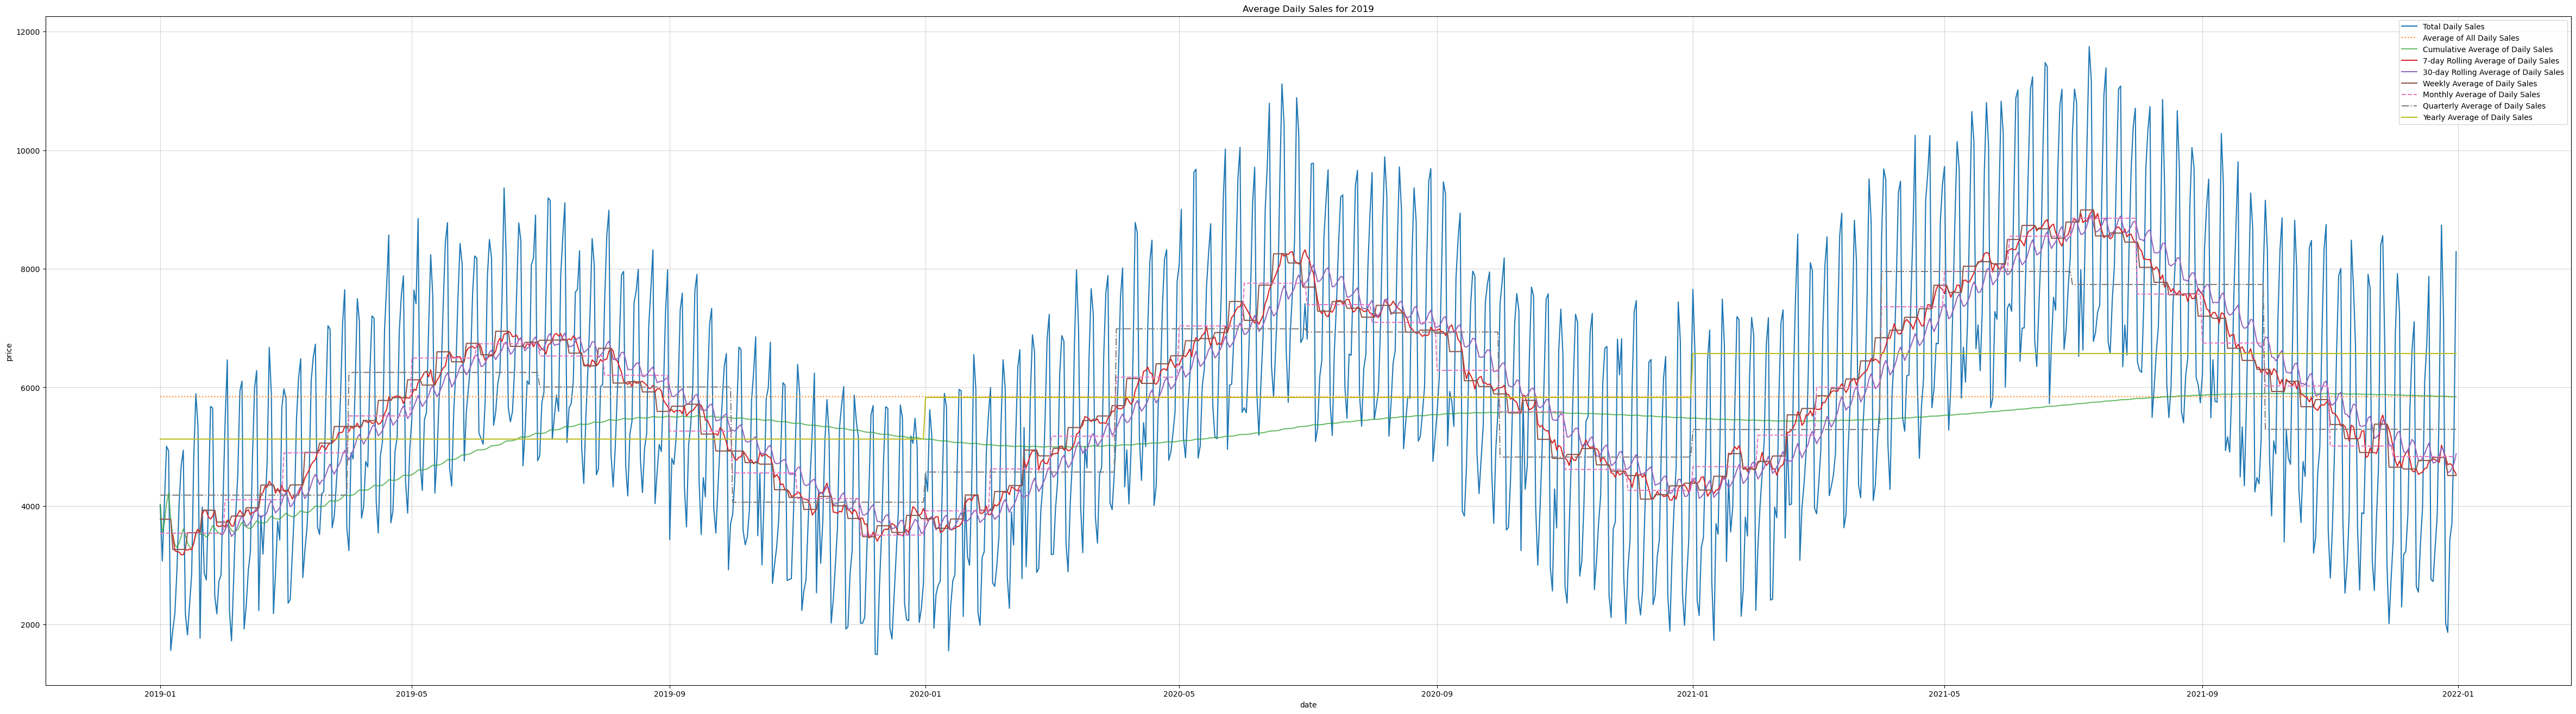

In [40]:
# An attempt at displaying all the data together makes the data too cluttered and almost impossible to discern.

fig, ax = plt.subplots(figsize=(60, 16))
plt.title("Average Daily Sales for 2019")
sns.lineplot(data=daywise_sales, x="date", y="price", legend="auto", label="Total Daily Sales")
sns.lineplot(data=daywise_sales, x="date", y=daywise_sales["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
sns.lineplot(data=daywise_sales, x="date", y="cumulative_avg_sales", label="Cumulative Average of Daily Sales", linestyle="solid", alpha=0.7)
sns.lineplot(data=daywise_sales, x="date", y="rolling_7d_avg_sales", label="7-day Rolling Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales, x="date", y="rolling_30d_avg_sales", label="30-day Rolling Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales, x="date", y="weekly_avg_sales", label="Weekly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=daywise_sales, x="date", y="qrtrly_avg_sales", label="Quarterly Average of Daily Sales", linestyle="dashdot")
sns.lineplot(data=daywise_sales, x="date", y="yearly_avg_sales", label="Yearly Average of Daily Sales", linestyle="solid")
plt.grid(alpha=0.5)
plt.savefig("Daily_Sales_All.png", dpi=600, facecolor="white")
plt.show()

##### Some of the data has been split into three parts based on year for easier viewing as graphs.

In [41]:
daywise_sales_2019 = daywise_sales[daywise_sales["year"] == 2019]
daywise_sales_2020 = daywise_sales[daywise_sales["year"] == 2020]
daywise_sales_2021 = daywise_sales[daywise_sales["year"] == 2021]

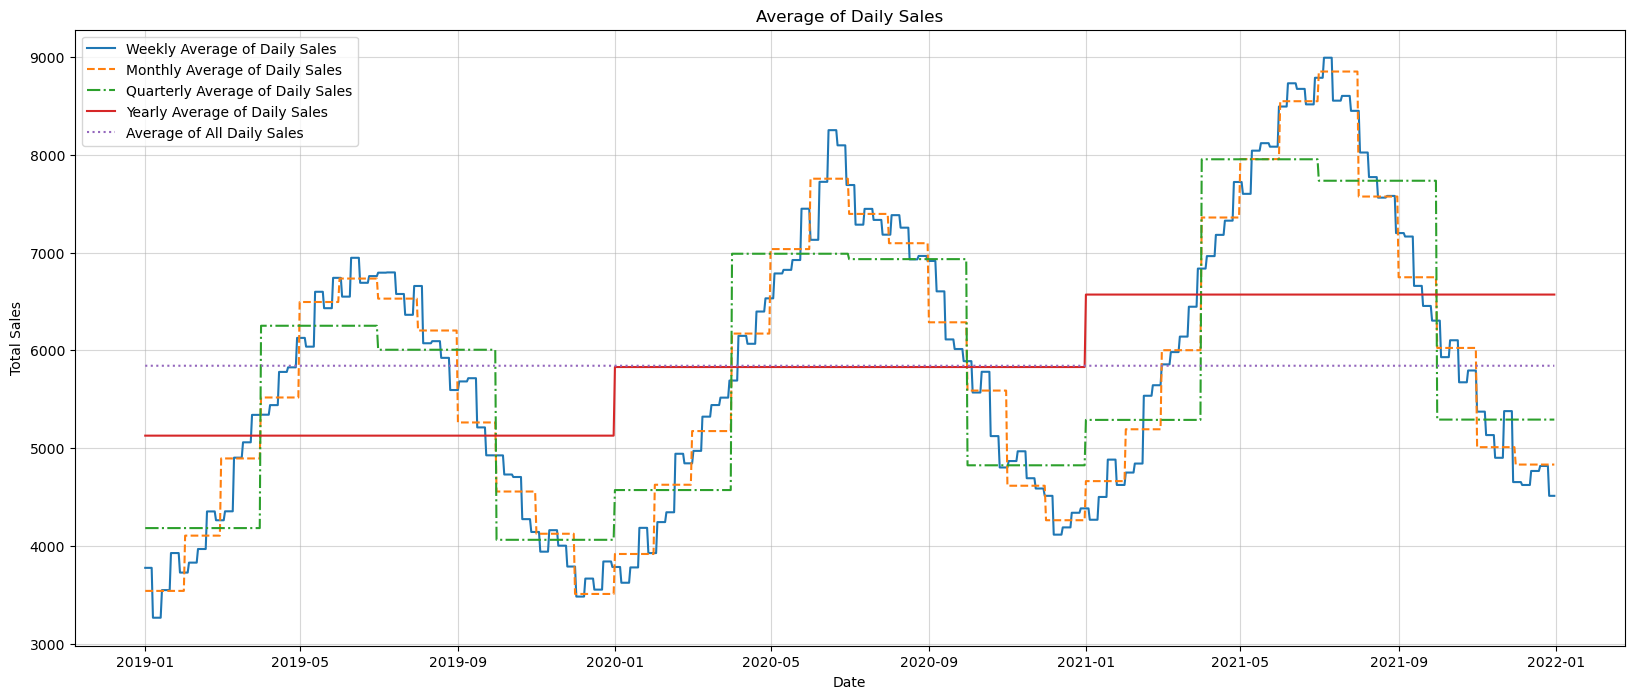

In [42]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average of Daily Sales")

ax1 = plt.subplot(1, 1, 1)
sns.lineplot(data=daywise_sales, x="date", y="weekly_avg_sales", label="Weekly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=daywise_sales, x="date", y="qrtrly_avg_sales", label="Quarterly Average of Daily Sales", linestyle="dashdot")
sns.lineplot(data=daywise_sales, x="date", y="yearly_avg_sales", label="Yearly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales, x="date", y=daywise_sales["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
ax1.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Daily_Sales_2019.png", dpi=600, facecolor="white")

plt.show()

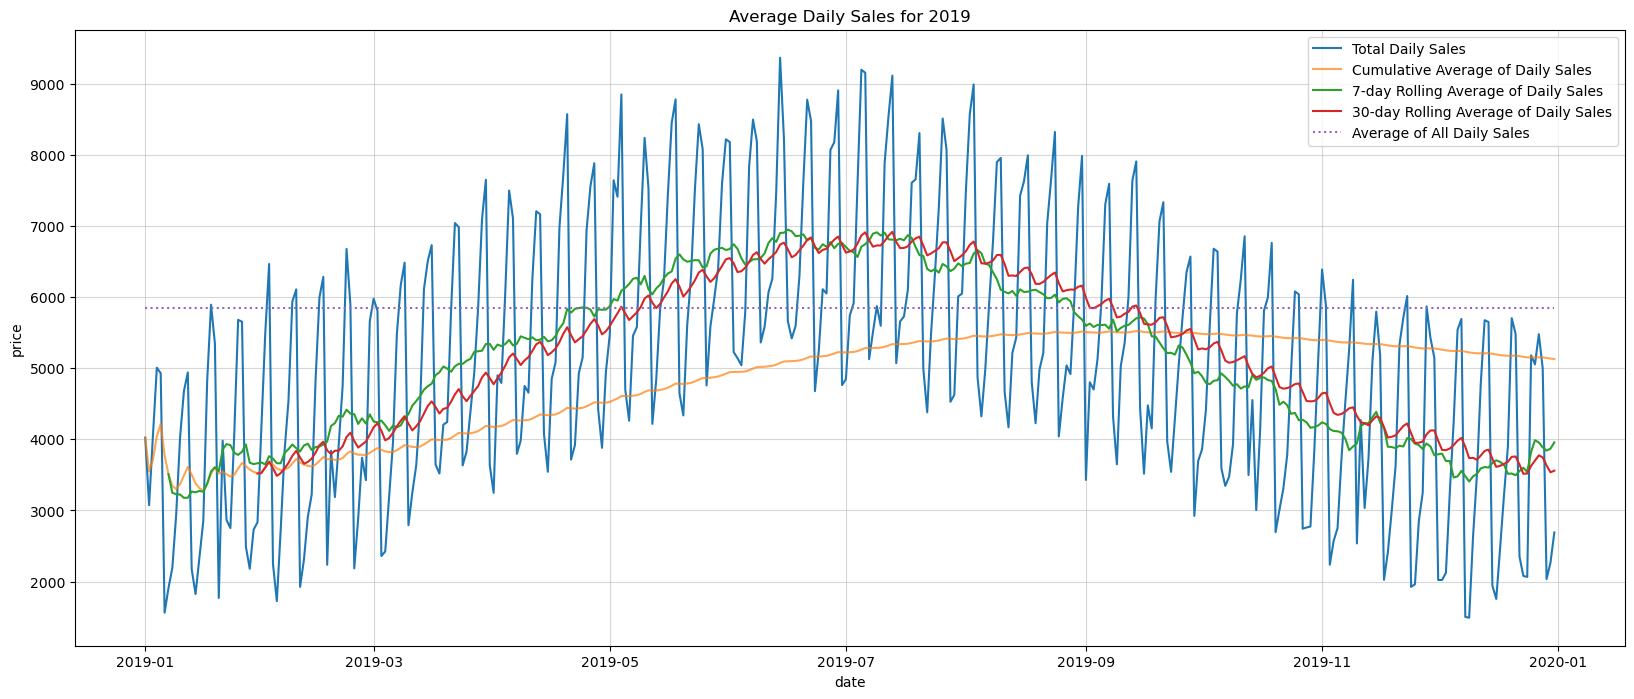

In [43]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average Daily Sales for 2019")
sns.lineplot(data=daywise_sales_2019, x="date", y="price", legend="auto", label="Total Daily Sales")
sns.lineplot(data=daywise_sales_2019, x="date", y="cumulative_avg_sales", label="Cumulative Average of Daily Sales", linestyle="solid", alpha=0.7)
sns.lineplot(data=daywise_sales_2019, x="date", y="rolling_7d_avg_sales", label="7-day Rolling Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales_2019, x="date", y="rolling_30d_avg_sales", label="30-day Rolling Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales_2019, x="date", y=daywise_sales["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
plt.grid(alpha=0.5)
plt.savefig("Daily_Sales_2019.png", dpi=600, facecolor="white")
plt.show()

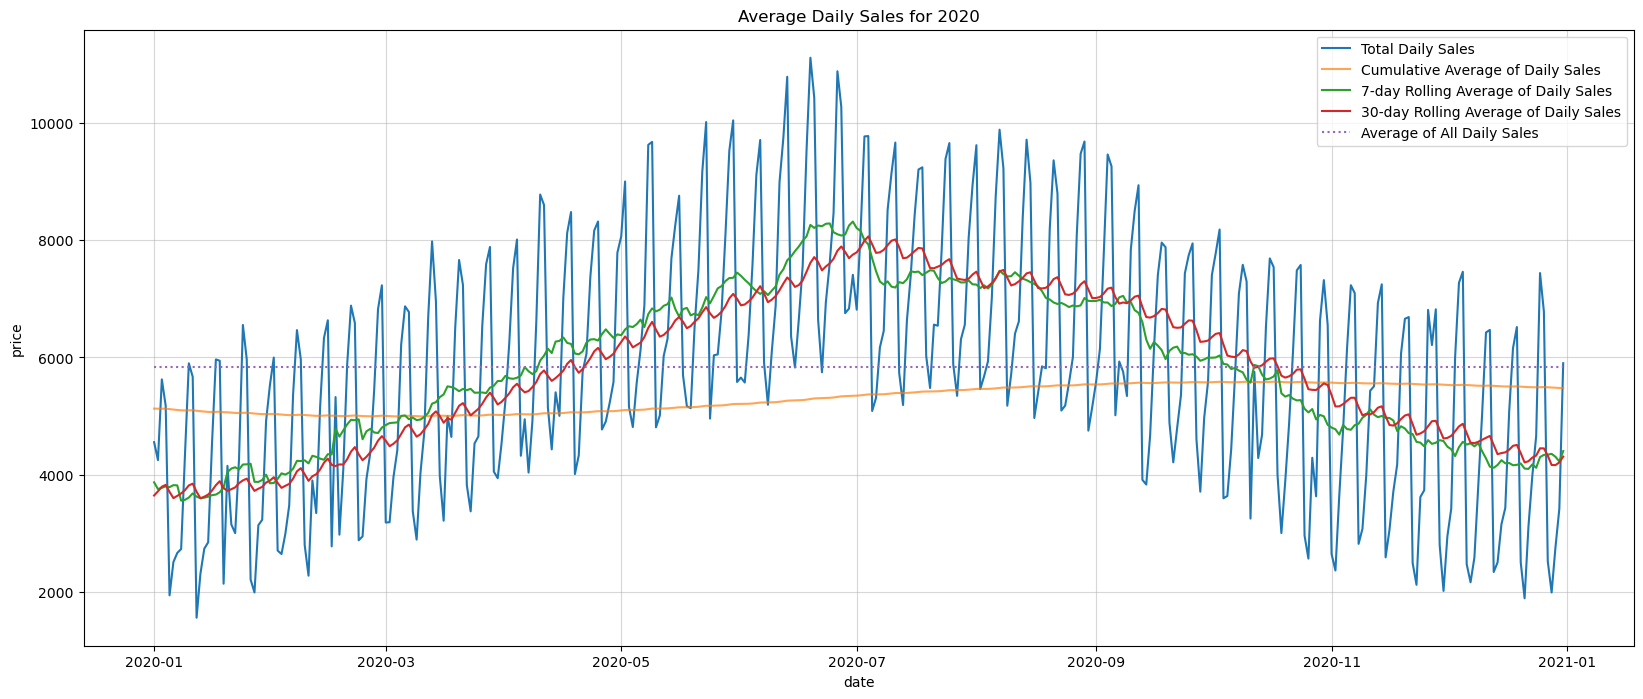

In [44]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average Daily Sales for 2020")
sns.lineplot(data=daywise_sales_2020, x="date", y="price", legend="auto", label="Total Daily Sales")
sns.lineplot(data=daywise_sales_2020, x="date", y="cumulative_avg_sales", label="Cumulative Average of Daily Sales", linestyle="solid", alpha=0.7)
sns.lineplot(data=daywise_sales_2020, x="date", y="rolling_7d_avg_sales", label="7-day Rolling Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales_2020, x="date", y="rolling_30d_avg_sales", label="30-day Rolling Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales_2020, x="date", y=daywise_sales["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
plt.grid(alpha=0.5)
plt.savefig("Daily_Sales_2020.png", dpi=600, facecolor="white")
plt.show()

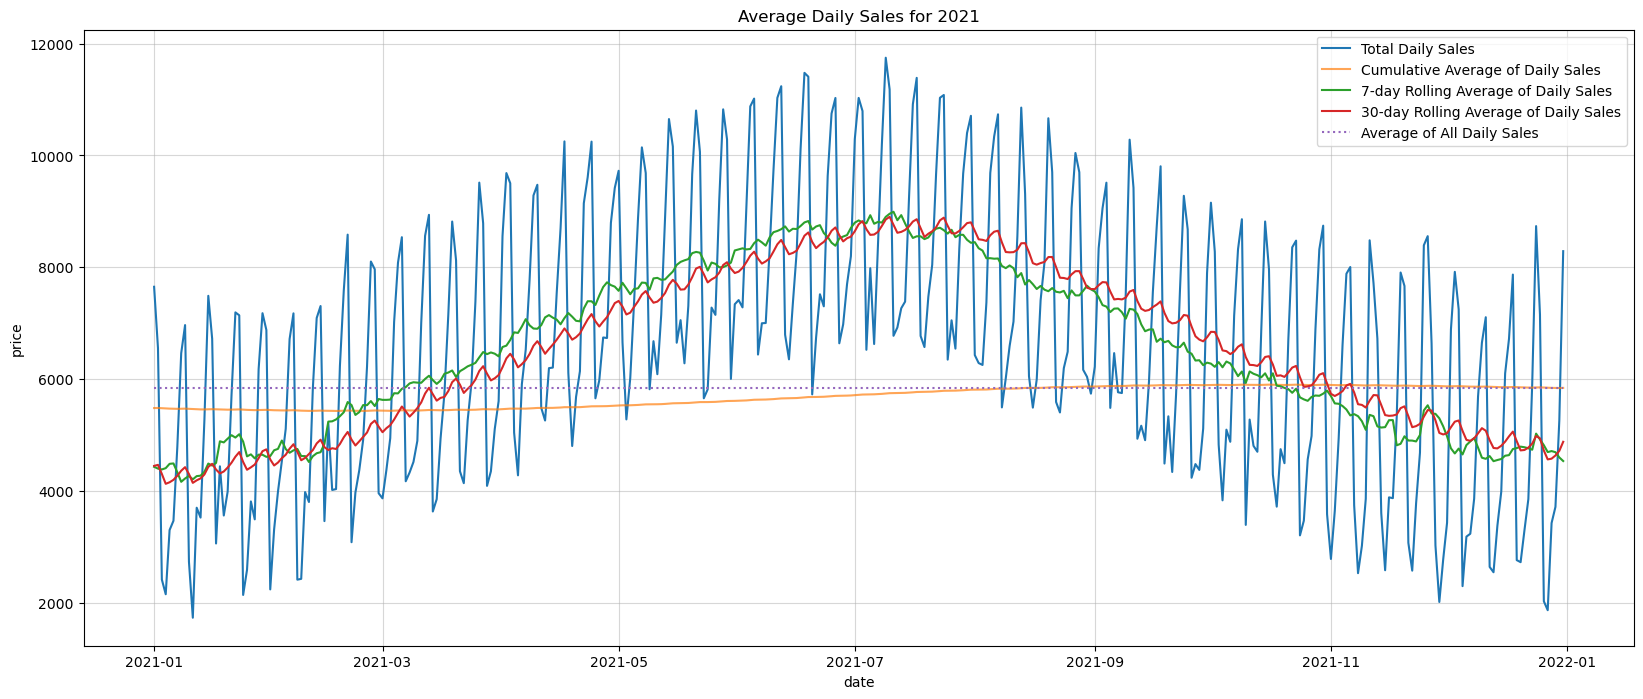

In [45]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average Daily Sales for 2021")
sns.lineplot(data=daywise_sales_2021, x="date", y="price", legend="auto", label="Total Daily Sales")
sns.lineplot(data=daywise_sales_2021, x="date", y="cumulative_avg_sales", label="Cumulative Average of Daily Sales", linestyle="solid", alpha=0.7)
sns.lineplot(data=daywise_sales_2021, x="date", y="rolling_7d_avg_sales", label="7-day Rolling Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales_2021, x="date", y="rolling_30d_avg_sales", label="30-day Rolling Average of Daily Sales", linestyle="solid")
sns.lineplot(data=daywise_sales_2021, x="date", y=daywise_sales["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
plt.grid(alpha=0.5)
plt.savefig("Daily_Sales_2021.png", dpi=600, facecolor="white")
plt.show()

#### Graph for same period with units sold as the main focus.

In [46]:
daywise_sales.columns

Index(['date', 'price', 'item_count', 'week', 'year_month', 'quarter', 'year',
       'cumulative_avg_sales', 'rolling_7d_avg_sales', 'rolling_30d_avg_sales',
       'weekly_avg_sales', 'monthly_avg_sales', 'qrtrly_avg_sales',
       'yearly_avg_sales'],
      dtype='object')

In [47]:
# Create a table for daily items sold.
daywise_units = sales_df.loc[:, ["date", "item_count", "week", "year_month", "quarter", "year"]]
daywise_units["cumulative_avg_units"] = daywise_units["item_count"].expanding().mean()
daywise_units["rolling_7d_avg_units"] = daywise_units["item_count"].rolling(7).mean()
daywise_units["rolling_30d_avg_units"] = daywise_units["item_count"].rolling(30).mean()
daywise_units

,date,item_count,week,year_month,quarter,year,cumulative_avg_units,rolling_7d_avg_units,rolling_30d_avg_units
0,2019-01-01,427,2018-12-31/2019-01-06,2019-01,2019Q1,2019,427.000000,NaN,NaN
1,2019-01-02,337,2018-12-31/2019-01-06,2019-01,2019Q1,2019,382.000000,NaN,NaN
2,2019-01-03,445,2018-12-31/2019-01-06,2019-01,2019Q1,2019,403.000000,NaN,NaN
3,2019-01-04,564,2018-12-31/2019-01-06,2019-01,2019Q1,2019,443.250000,NaN,NaN
4,2019-01-05,552,2018-12-31/2019-01-06,2019-01,2019Q1,2019,465.000000,NaN,NaN
...,...,...,...,...,...,...,...,...,...
1091,2021-12-27,192,2021-12-27/2022-01-02,2021-12,2021Q4,2021,634.366300,477.142857,460.033333
1092,2021-12-28,344,2021-12-27/2022-01-02,2021-12,2021Q4,2021,634.100640,479.285714,461.700000
1093,2021-12-29,371,2021-12-27/2022-01-02,2021-12,2021Q4,2021,633.860146,475.285714,466.500000
1094,2021-12-30,527,2021-12-27/2022-01-02,2021-12,2021Q4,2021,633.762557,461.000000,474.966667


In [48]:
# Create a dictionary from 'weekly_avg_sales' with 'week' as keys and 'item_count' as values.
# The average 'item_count' was already calculated when creating the 'weekly_avg_sales' dataframe.
week_units_dict = dict(zip(weekly_avg_sales['week'], weekly_avg_sales['item_count']))
week_units_dict

{Period('2018-12-31/2019-01-06', 'W-SUN'): 418.6666666666667,
 Period('2019-01-07/2019-01-13', 'W-SUN'): 391.7142857142857,
 Period('2019-01-14/2019-01-20', 'W-SUN'): 401.85714285714283,
 Period('2019-01-21/2019-01-27', 'W-SUN'): 452.0,
 Period('2019-01-28/2019-02-03', 'W-SUN'): 423.14285714285717,
 Period('2019-02-04/2019-02-10', 'W-SUN'): 441.57142857142856,
 Period('2019-02-11/2019-02-17', 'W-SUN'): 452.85714285714283,
 Period('2019-02-18/2019-02-24', 'W-SUN'): 509.14285714285717,
 Period('2019-02-25/2019-03-03', 'W-SUN'): 489.14285714285717,
 Period('2019-03-04/2019-03-10', 'W-SUN'): 511.7142857142857,
 Period('2019-03-11/2019-03-17', 'W-SUN'): 558.7142857142857,
 Period('2019-03-18/2019-03-24', 'W-SUN'): 573.8571428571429,
 Period('2019-03-25/2019-03-31', 'W-SUN'): 611.2857142857143,
 Period('2019-04-01/2019-04-07', 'W-SUN'): 613.8571428571429,
 Period('2019-04-08/2019-04-14', 'W-SUN'): 619.7142857142857,
 Period('2019-04-15/2019-04-21', 'W-SUN'): 666.2857142857143,
 Period('2019-

In [49]:
month_units_dict = dict(zip(monthly_avg_sales['year_month'], monthly_avg_sales['item_count']))
month_units_dict

{Period('2019-01', 'M'): 406.2258064516129,
 Period('2019-02', 'M'): 470.85714285714283,
 Period('2019-03', 'M'): 563.0322580645161,
 Period('2019-04', 'M'): 634.4666666666667,
 Period('2019-05', 'M'): 744.2258064516129,
 Period('2019-06', 'M'): 771.8,
 Period('2019-07', 'M'): 745.8387096774194,
 Period('2019-08', 'M'): 710.7096774193549,
 Period('2019-09', 'M'): 599.9666666666667,
 Period('2019-10', 'M'): 519.8064516129032,
 Period('2019-11', 'M'): 468.46666666666664,
 Period('2019-12', 'M'): 400.8709677419355,
 Period('2020-01', 'M'): 444.35483870967744,
 Period('2020-02', 'M'): 522.7931034482758,
 Period('2020-03', 'M'): 591.6774193548387,
 Period('2020-04', 'M'): 706.9666666666667,
 Period('2020-05', 'M'): 801.2258064516129,
 Period('2020-06', 'M'): 820.2333333333333,
 Period('2020-07', 'M'): 825.7741935483871,
 Period('2020-08', 'M'): 742.3225806451613,
 Period('2020-09', 'M'): 654.3333333333334,
 Period('2020-10', 'M'): 587.6451612903226,
 Period('2020-11', 'M'): 482.0,
 Period('

In [50]:
qrtr_units_dict = dict(zip(qrtrly_avg_sales['quarter'], qrtrly_avg_sales['item_count']))
qrtr_units_dict

{Period('2019Q1', 'Q-DEC'): 480.34444444444443,
 Period('2019Q2', 'Q-DEC'): 717.1318681318681,
 Period('2019Q3', 'Q-DEC'): 686.4347826086956,
 Period('2019Q4', 'Q-DEC'): 462.9891304347826,
 Period('2020Q1', 'Q-DEC'): 519.5384615384615,
 Period('2020Q2', 'Q-DEC'): 776.4175824175824,
 Period('2020Q3', 'Q-DEC'): 741.75,
 Period('2020Q4', 'Q-DEC'): 504.4347826086956,
 Period('2021Q1', 'Q-DEC'): 549.9333333333333,
 Period('2021Q2', 'Q-DEC'): 827.3296703296703,
 Period('2021Q3', 'Q-DEC'): 803.195652173913,
 Period('2021Q4', 'Q-DEC'): 535.804347826087}

In [51]:
year_units_dict = dict(zip(yearly_avg_sales['year'], yearly_avg_sales['item_count']))
year_units_dict

{2019: 586.9506849315069, 2020: 635.4672131147541, 2021: 679.3671232876712}

In [52]:
# Adding the diffrent averages to the daily items sold table.
daywise_units['weekly_avg_units'] = daywise_units['week'].map(week_units_dict)
daywise_units['monthly_avg_units'] = daywise_units['year_month'].map(month_units_dict)
daywise_units['qrtrly_avg_units'] = daywise_units['quarter'].map(qrtr_units_dict)
daywise_units['yearly_avg_units'] = daywise_units['year'].map(year_units_dict)
daywise_units

,date,item_count,week,year_month,quarter,year,cumulative_avg_units,rolling_7d_avg_units,rolling_30d_avg_units,weekly_avg_units,monthly_avg_units,qrtrly_avg_units,yearly_avg_units
0,2019-01-01,427,2018-12-31/2019-01-06,2019-01,2019Q1,2019,427.000000,NaN,NaN,418.666667,406.225806,480.344444,586.950685
1,2019-01-02,337,2018-12-31/2019-01-06,2019-01,2019Q1,2019,382.000000,NaN,NaN,418.666667,406.225806,480.344444,586.950685
2,2019-01-03,445,2018-12-31/2019-01-06,2019-01,2019Q1,2019,403.000000,NaN,NaN,418.666667,406.225806,480.344444,586.950685
3,2019-01-04,564,2018-12-31/2019-01-06,2019-01,2019Q1,2019,443.250000,NaN,NaN,418.666667,406.225806,480.344444,586.950685
4,2019-01-05,552,2018-12-31/2019-01-06,2019-01,2019Q1,2019,465.000000,NaN,NaN,418.666667,406.225806,480.344444,586.950685
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2021-12-27,192,2021-12-27/2022-01-02,2021-12,2021Q4,2021,634.366300,477.142857,460.033333,450.200000,486.000000,535.804348,679.367123
1092,2021-12-28,344,2021-12-27/2022-01-02,2021-12,2021Q4,2021,634.100640,479.285714,461.700000,450.200000,486.000000,535.804348,679.367123
1093,2021-12-29,371,2021-12-27/2022-01-02,2021-12,2021Q4,2021,633.860146,475.285714,466.500000,450.200000,486.000000,535.804348,679.367123
1094,2021-12-30,527,2021-12-27/2022-01-02,2021-12,2021Q4,2021,633.762557,461.000000,474.966667,450.200000,486.000000,535.804348,679.367123


In [53]:
daywise_units_2019 = daywise_units[daywise_units["year"] == 2019]
daywise_units_2020 = daywise_units[daywise_units["year"] == 2020]
daywise_units_2021 = daywise_units[daywise_units["year"] == 2021]

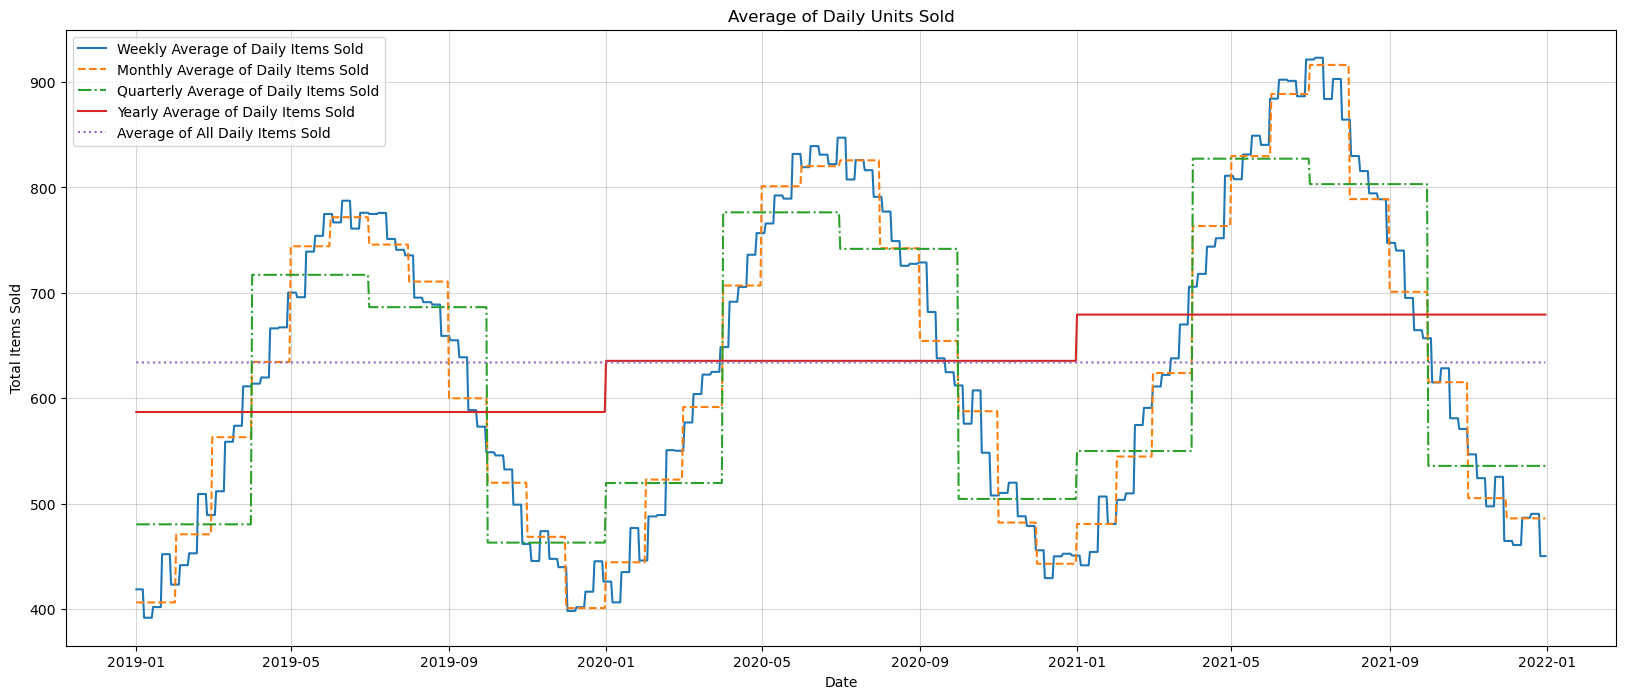

In [54]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average of Daily Units Sold")

ax1 = plt.subplot(1, 1, 1)
sns.lineplot(data=daywise_units, x="date", y="weekly_avg_units", label="Weekly Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units, x="date", y="monthly_avg_units", label="Monthly Average of Daily Items Sold", linestyle="dashed")
sns.lineplot(data=daywise_units, x="date", y="qrtrly_avg_units", label="Quarterly Average of Daily Items Sold", linestyle="dashdot")
sns.lineplot(data=daywise_units, x="date", y="yearly_avg_units", label="Yearly Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units, x="date", y=daywise_units["item_count"].mean(), label="Average of All Daily Items Sold", linestyle="dotted")
ax1.set(xlabel="Date", ylabel="Total Items Sold")
plt.grid(alpha=0.5)

# plt.savefig("Daily_Sales_2019.png", dpi=600, facecolor="white")

plt.show()

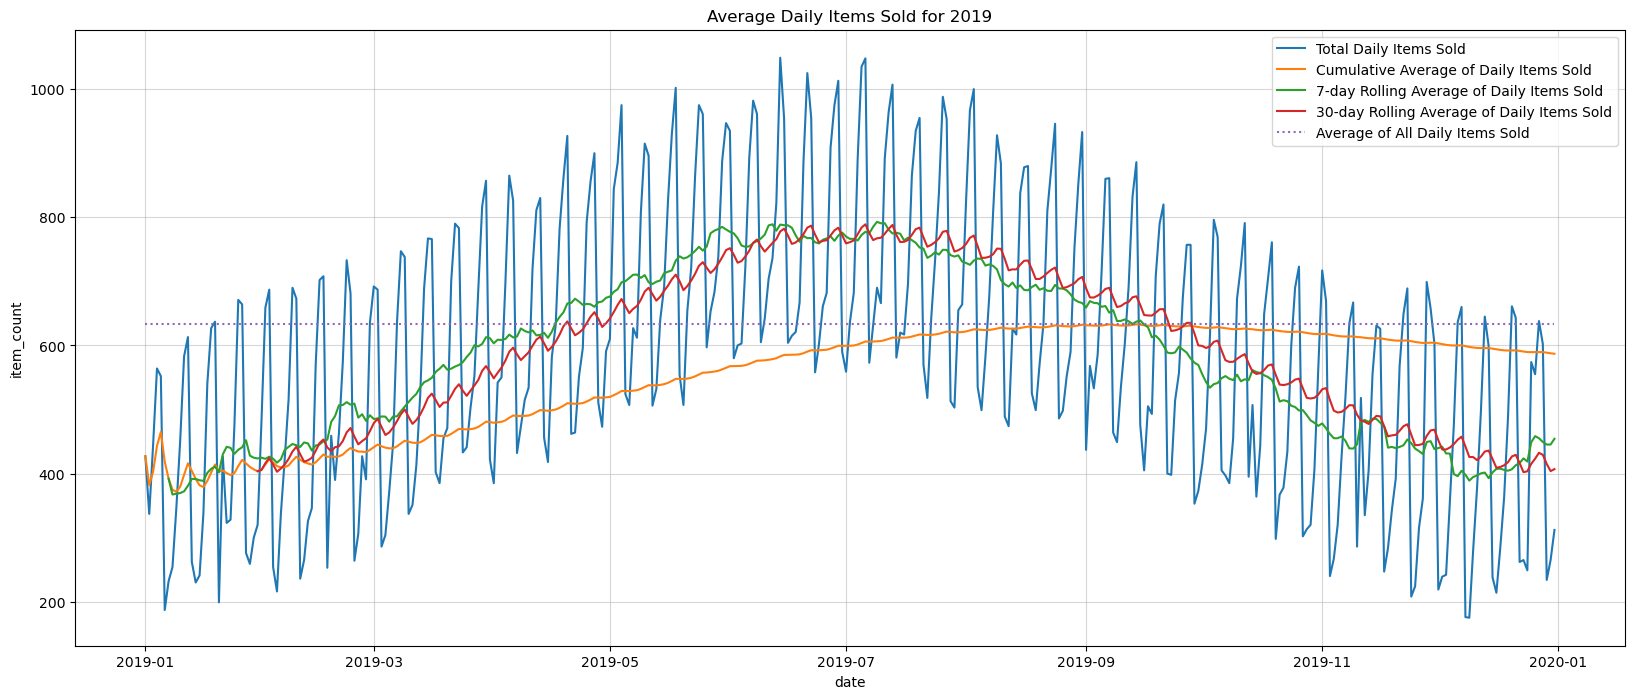

In [55]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average Daily Items Sold for 2019")
sns.lineplot(data=daywise_units_2019, x="date", y="item_count", legend="auto", label="Total Daily Items Sold")
sns.lineplot(data=daywise_units_2019, x="date", y="cumulative_avg_units", label="Cumulative Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2019, x="date", y="rolling_7d_avg_units", label="7-day Rolling Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2019, x="date", y="rolling_30d_avg_units", label="30-day Rolling Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2019, x="date", y=daywise_units["item_count"].mean(), label="Average of All Daily Items Sold", linestyle="dotted")
plt.grid(alpha=0.5)
plt.savefig("Daily_Items_Sold_2019.png", dpi=600, facecolor="white")
plt.show()

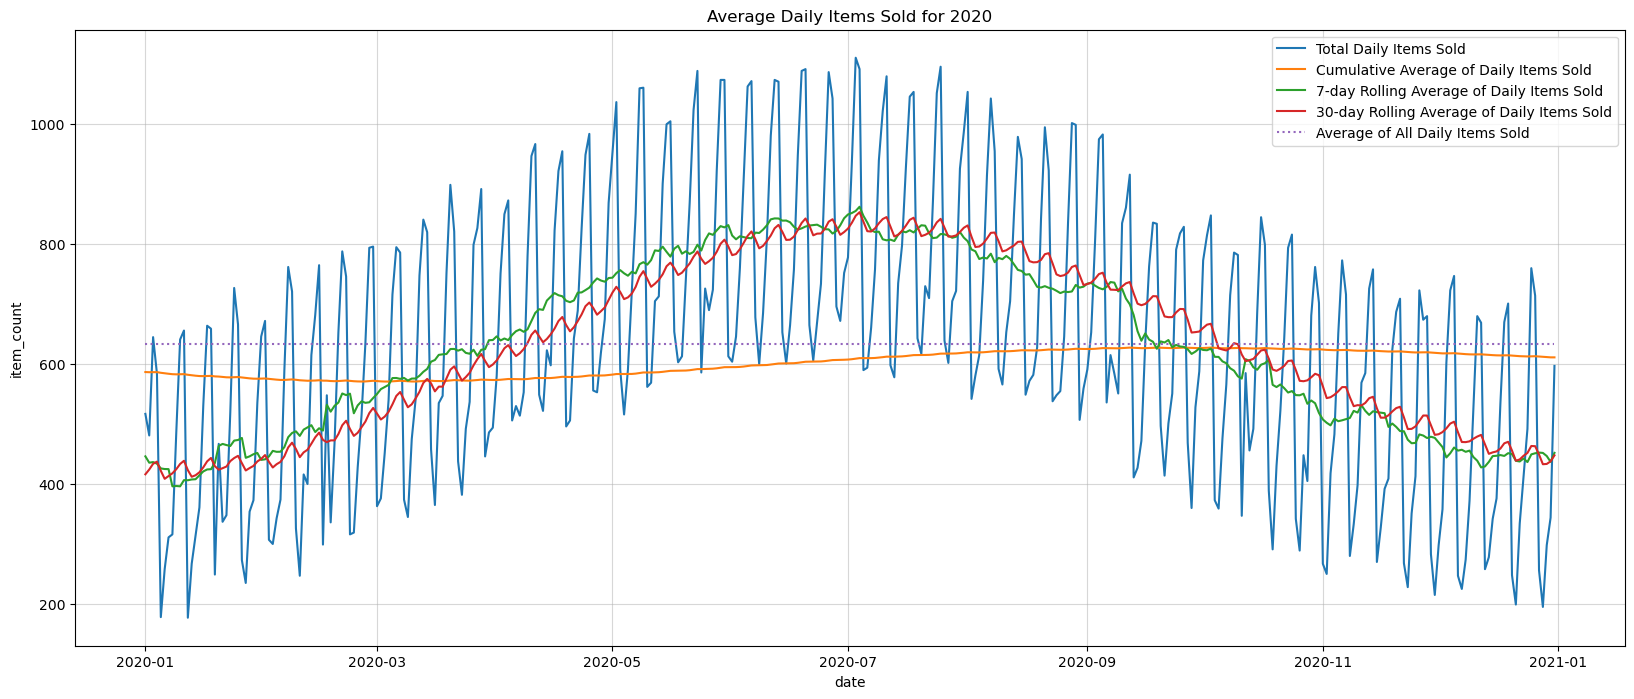

In [56]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average Daily Items Sold for 2020")
sns.lineplot(data=daywise_units_2020, x="date", y="item_count", legend="auto", label="Total Daily Items Sold")
sns.lineplot(data=daywise_units_2020, x="date", y="cumulative_avg_units", label="Cumulative Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2020, x="date", y="rolling_7d_avg_units", label="7-day Rolling Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2020, x="date", y="rolling_30d_avg_units", label="30-day Rolling Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2020, x="date", y=daywise_units["item_count"].mean(), label="Average of All Daily Items Sold", linestyle="dotted")
plt.grid(alpha=0.5)
plt.savefig("Daily_Items_Sold_2020.png", dpi=600, facecolor="white")
plt.show()

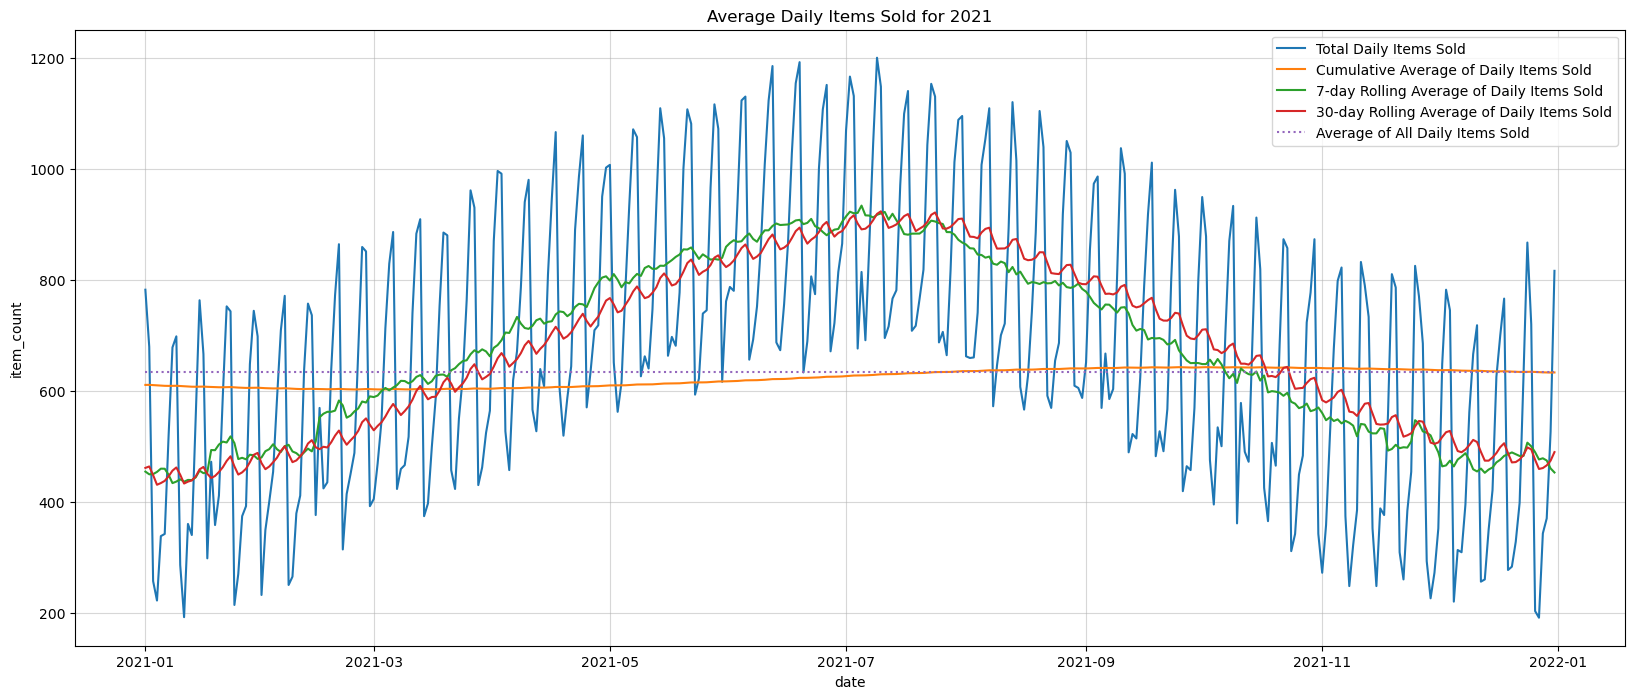

In [57]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average Daily Items Sold for 2021")
sns.lineplot(data=daywise_units_2021, x="date", y="item_count", legend="auto", label="Total Daily Items Sold")
sns.lineplot(data=daywise_units_2021, x="date", y="cumulative_avg_units", label="Cumulative Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2021, x="date", y="rolling_7d_avg_units", label="7-day Rolling Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2021, x="date", y="rolling_30d_avg_units", label="30-day Rolling Average of Daily Items Sold", linestyle="solid")
sns.lineplot(data=daywise_units_2021, x="date", y=daywise_units["item_count"].mean(), label="Average of All Daily Items Sold", linestyle="dotted")
plt.grid(alpha=0.5)
plt.savefig("Daily_Items_Sold_2021.png", dpi=600, facecolor="white")
plt.show()

#### - Sales are usually high in the months of June and July with the overall sales being much higher during second and third quarter than the other two quarters every year.
#### - Sales are especially bad during the months of January and December, with sales starting to pick up during the 3rd or 4th week of the year.
#### - The average sales has increased every consecutive year.

#### Average Sales based on Day of Week

In [58]:
day_of_week_wise = sales_df.groupby(by="day_of_week", observed=False).agg({"price":"mean", "item_count":"mean"})
day_of_week_wise

,price,item_count
day_of_week,,
Monday,4133.333141,449.435897
Tuesday,4678.971083,506.076433
Wednesday,5175.880955,562.407643
Thursday,6837.799490,744.885350
Friday,8008.523312,868.152866
Saturday,8016.502051,869.512821
Sunday,4040.254551,436.102564


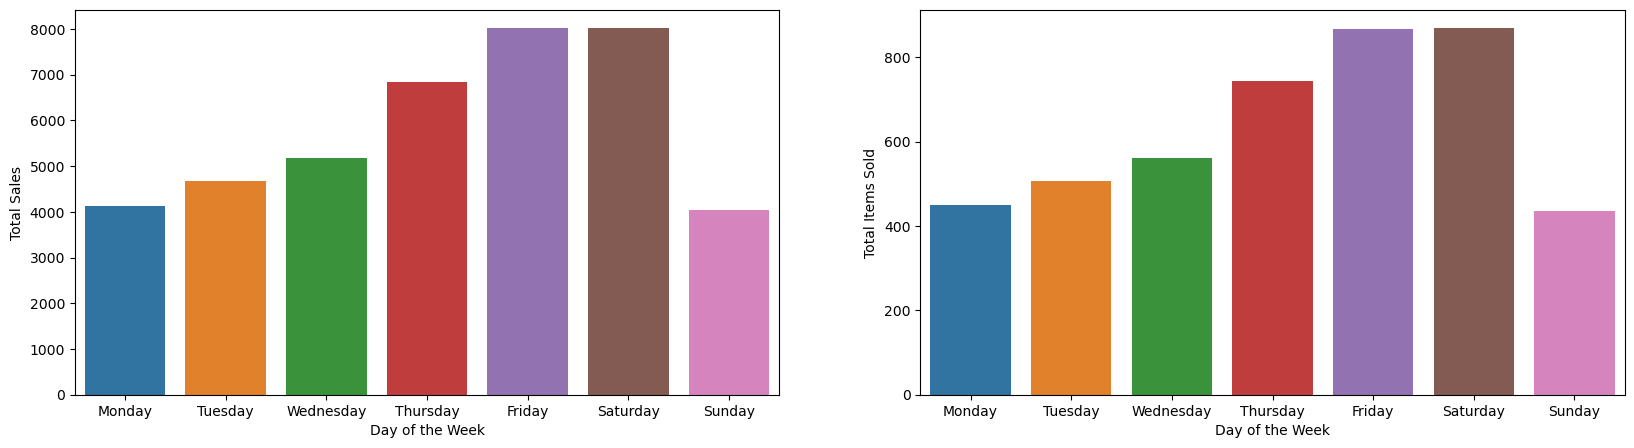

In [59]:
fig, ax = plt.subplots(nrows=1, ncols=2, figsize=(20, 5))

# plt.title("Total Sales based on Day of Week")
plt.subplot(1, 2, 1)
ax1 = sns.barplot(day_of_week_wise, x="day_of_week", y="price", hue="day_of_week")

plt.subplot(1, 2, 2)
ax2 = sns.barplot(day_of_week_wise, x="day_of_week", y="item_count", hue="day_of_week")

ax1.set(xlabel="Day of the Week", ylabel="Total Sales")
ax2.set(xlabel="Day of the Week", ylabel="Total Items Sold")
plt.show()

#### - From the graph we can see that sales are much higher on Friday and Saturday, most likely coinciding with the end of workweek.
#### - Sales are lowest on Sunday, probably due to people staying home, resting and preparing for the start of next workweek.
#### - Sales are low on Monday with the number gradually increasing as the week draws closer to an end.

#### Total Sales categorized by Restaurant

In [60]:
# Total Sales for each restaurant
store_wise = final_df.groupby(by="store_name").agg({"price":"sum"})
store_wise

,price
store_name,
Beachfront Bar,3796.20
Bob's Diner,6337275.69
Corner Cafe,16551.43
Fou Cher,27885.37
Surfs Up,15651.49
Sweet Shack,2578.27


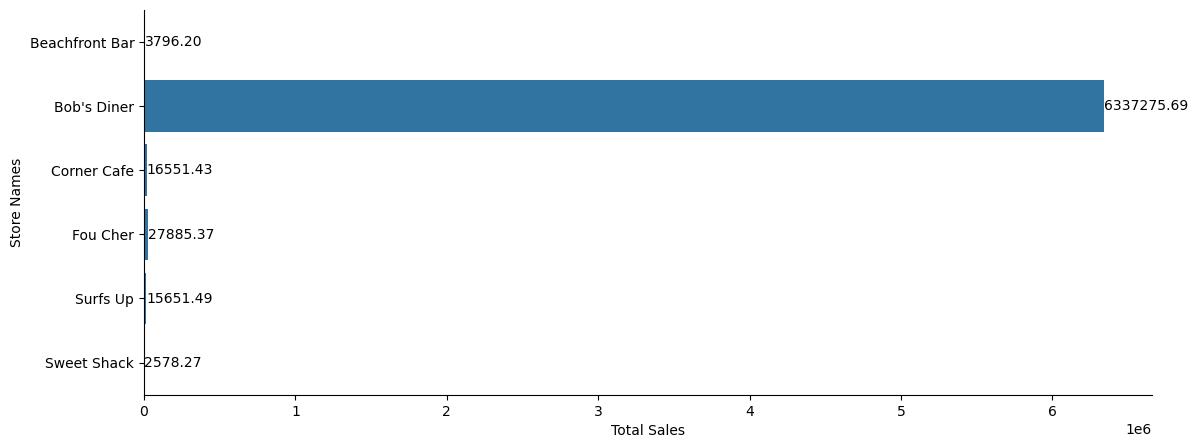

In [61]:
# Creating a bar graph for total sales
plt.subplots(figsize=(13,5))

ax = sns.barplot(store_wise, x="price", y="store_name")
ax.set(xlabel="Total Sales", ylabel="Store Names")
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

plt.show()

#### Bob's Diner has the highest sales in the time period and the scale of sales is much higher than that of any other restaurant in the data.

In [62]:
stores = df["store_name"].unique()
print(stores)

["Bob's Diner" 'Surfs Up' 'Beachfront Bar' 'Fou Cher' 'Corner Cafe'
 'Sweet Shack']


### Beachfront Bar Sales

In [63]:
beach = df[df["store_name"] == "Beachfront Bar"]
beach

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
10,2019-01-01,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
107,2019-01-02,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Wednesday
208,2019-01-03,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Thursday
308,2019-01-04,29,2.43,1,Original Crazy Cocktail,228,2,Beachfront Bar,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Friday
309,2019-01-04,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109111,2021-12-27,42,5.82,2,Fantastic Milky Smoothy,318,2,Beachfront Bar,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Monday
109210,2021-12-28,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Tuesday
109310,2021-12-29,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Wednesday
109408,2021-12-30,29,2.43,1,Original Crazy Cocktail,228,2,Beachfront Bar,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Thursday


In [64]:
beach_daily = beach.groupby(by=["date"], sort=False).agg({"price": "sum", "item_count": "sum"}).reset_index()
beach_daily

,date,price,item_count
0,2019-01-01,2.91,1
1,2019-01-02,2.91,1
2,2019-01-03,2.91,1
3,2019-01-04,5.34,2
4,2019-01-05,2.91,1
...,...,...,...
801,2021-12-27,5.82,2
802,2021-12-28,2.91,1
803,2021-12-29,2.91,1
804,2021-12-30,2.43,1


In [65]:
beach_daily['month'] = pd.Categorical(beach_daily['date'].dt.month_name(), list(calendar.month_name)[1:])
beach_daily['year'] = beach_daily['date'].dt.year
beach_daily['year_month'] = beach_daily["date"].dt.to_period("M")
beach_daily['day_of_week'] = pd.Categorical(beach_daily['date'].dt.day_name(), list(calendar.day_name))
beach_daily

,date,price,item_count,month,year,year_month,day_of_week
0,2019-01-01,2.91,1,January,2019,2019-01,Tuesday
1,2019-01-02,2.91,1,January,2019,2019-01,Wednesday
2,2019-01-03,2.91,1,January,2019,2019-01,Thursday
3,2019-01-04,5.34,2,January,2019,2019-01,Friday
4,2019-01-05,2.91,1,January,2019,2019-01,Saturday
...,...,...,...,...,...,...,...
801,2021-12-27,5.82,2,December,2021,2021-12,Monday
802,2021-12-28,2.91,1,December,2021,2021-12,Tuesday
803,2021-12-29,2.91,1,December,2021,2021-12,Wednesday
804,2021-12-30,2.43,1,December,2021,2021-12,Thursday


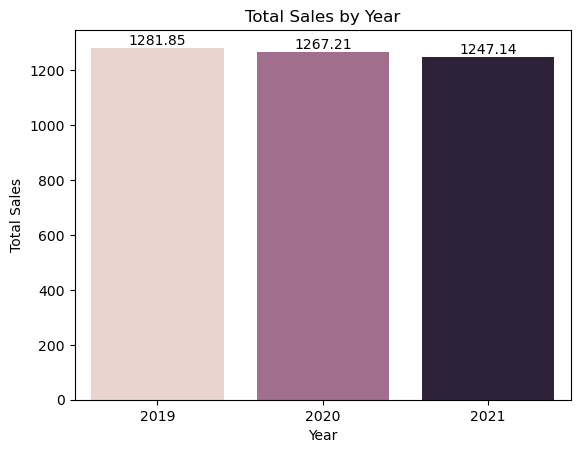

In [66]:
plt.title("Total Sales by Year")
ax = sns.barplot(beach_daily.groupby("year").agg({"price":"sum"}), x="year", y="price", hue="year", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Year", ylabel="Total Sales")
plt.show()

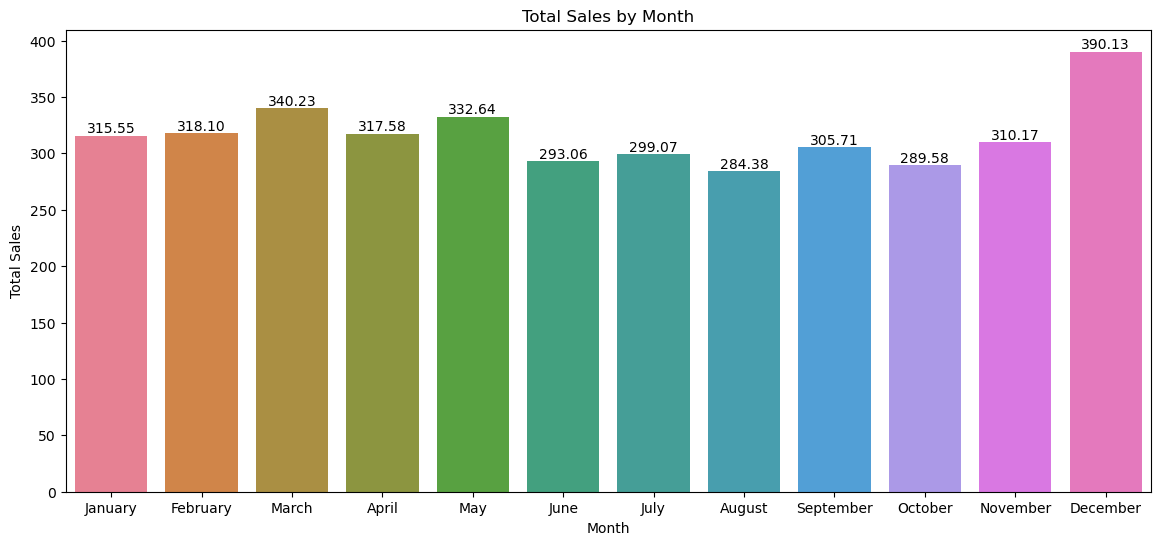

In [67]:
plt.subplots(figsize = (14, 6))

plt.title("Total Sales by Month")
ax = sns.barplot(beach_daily.groupby("month", observed=False).agg({"price":"sum"}), x="month", y="price", hue="month", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Month", ylabel="Total Sales")
plt.show()

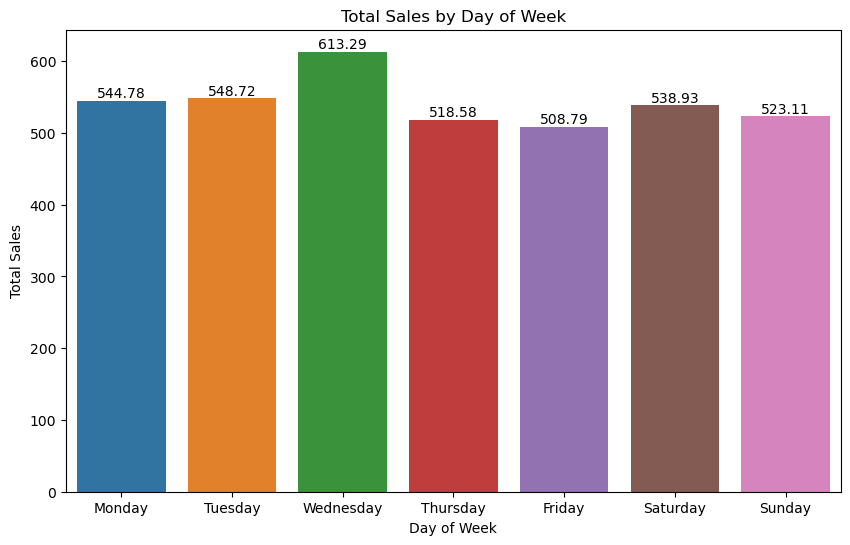

In [68]:
plt.subplots(figsize = (10, 6))

plt.title("Total Sales by Day of Week")
ax = sns.barplot(beach_daily.groupby("day_of_week", observed=False).agg({"price":"sum"}), x="day_of_week", y="price", hue="day_of_week", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Day of Week", ylabel="Total Sales")
plt.show()

In [69]:
monthly_avg_sales = beach_daily.groupby("year_month", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
yearly_avg_sales = beach_daily.groupby("year", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()

month_sales_dict = dict(zip(monthly_avg_sales['year_month'], monthly_avg_sales['price']))
year_sales_dict = dict(zip(yearly_avg_sales['year'], yearly_avg_sales['price']))

In [70]:
beach_daily['monthly_avg_sales'] = beach_daily['year_month'].map(month_sales_dict)
beach_daily['yearly_avg_sales'] = beach_daily['year'].map(year_sales_dict)
beach_daily

,date,price,item_count,month,year,year_month,day_of_week,monthly_avg_sales,yearly_avg_sales
0,2019-01-01,2.91,1,January,2019,2019-01,Tuesday,4.082857,4.695421
1,2019-01-02,2.91,1,January,2019,2019-01,Wednesday,4.082857,4.695421
2,2019-01-03,2.91,1,January,2019,2019-01,Thursday,4.082857,4.695421
3,2019-01-04,5.34,2,January,2019,2019-01,Friday,4.082857,4.695421
4,2019-01-05,2.91,1,January,2019,2019-01,Saturday,4.082857,4.695421
...,...,...,...,...,...,...,...,...,...
801,2021-12-27,5.82,2,December,2021,2021-12,Monday,4.770800,4.636208
802,2021-12-28,2.91,1,December,2021,2021-12,Tuesday,4.770800,4.636208
803,2021-12-29,2.91,1,December,2021,2021-12,Wednesday,4.770800,4.636208
804,2021-12-30,2.43,1,December,2021,2021-12,Thursday,4.770800,4.636208


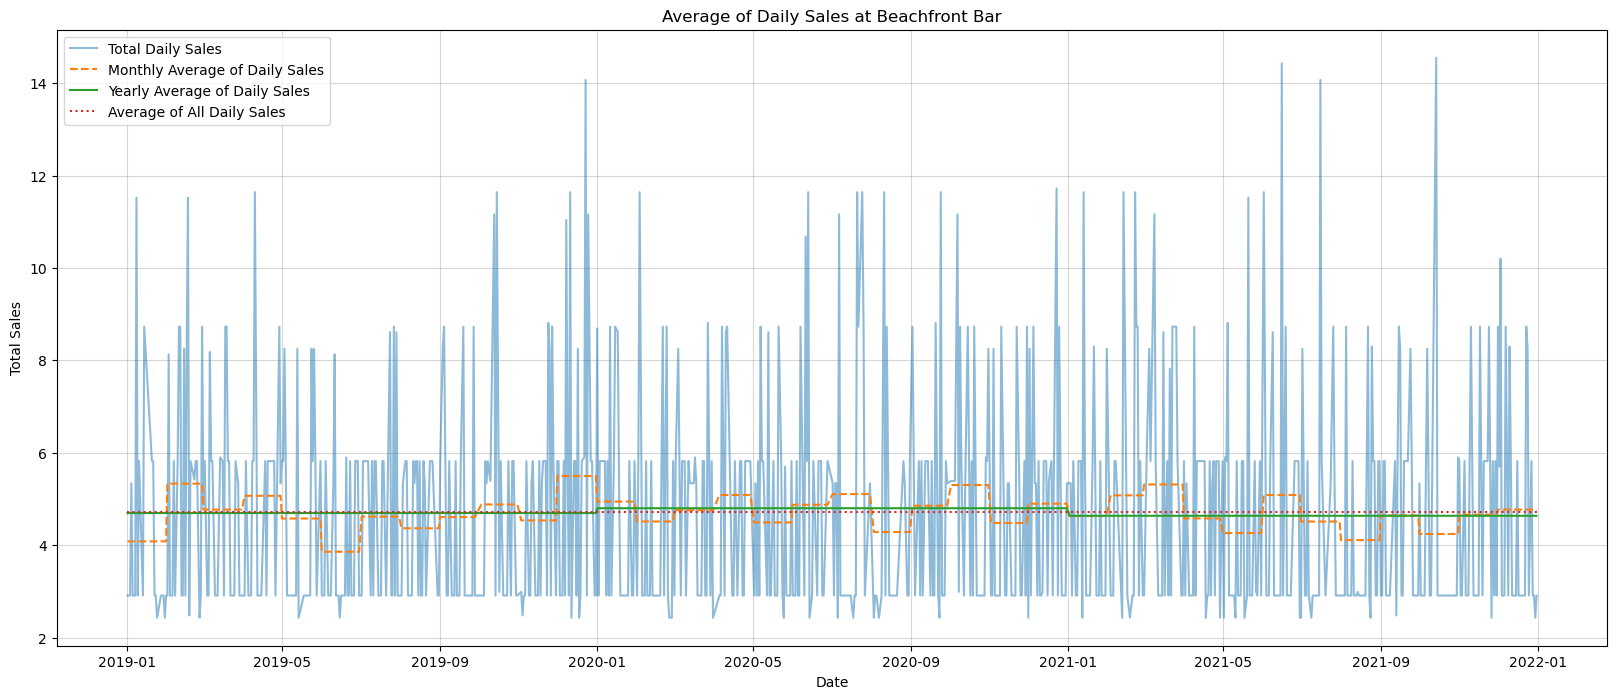

In [71]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average of Daily Sales at Beachfront Bar")

ax = sns.lineplot(data=beach_daily, x="date", y="price", legend="auto", label="Total Daily Sales", alpha=0.5)
sns.lineplot(data=beach_daily, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=beach_daily, x="date", y="yearly_avg_sales", label="Yearly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=beach_daily, x="date", y=beach_daily["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

### Bob's Diner Sales

In [72]:
bob = df[df["store_name"] == "Bob's Diner"]
bob

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
0,2019-01-01,3,58.44,2,Sweet Fruity Cake,931,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
1,2019-01-01,4,581.24,22,Amazing Steak Dinner with Rolls,763,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
2,2019-01-01,12,34.09,7,Fantastic Sweet Cola,478,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
3,2019-01-01,13,50.16,12,Sweet Frozen Soft Drink,490,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
4,2019-01-01,16,436.56,136,Frozen Milky Smoothy,284,1,Bob's Diner,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109517,2021-12-31,67,42.00,6,Sweet Lamb Cake,558,1,Bob's Diner,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109518,2021-12-31,68,8.70,1,Blue Ribbon Fruity Milky Cake,652,1,Bob's Diner,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109519,2021-12-31,73,51.60,10,Milky Cake,596,1,Bob's Diner,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday
109520,2021-12-31,76,1255.10,70,Amazing pork lunch,679,1,Bob's Diner,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Friday


In [73]:
bob_daily = bob.groupby(by=["date"], sort=False).agg({"price": "sum", "item_count": "sum"}).reset_index()
bob_daily

,date,price,item_count
0,2019-01-01,3956.02,421
1,2019-01-02,2941.22,330
2,2019-01-03,3914.70,438
3,2019-01-04,4944.71,559
4,2019-01-05,4845.76,545
...,...,...,...
1091,2021-12-27,1793.41,184
1092,2021-12-28,3390.57,340
1093,2021-12-29,3698.71,366
1094,2021-12-30,5257.53,525


In [74]:
bob_daily['month'] = pd.Categorical(bob_daily['date'].dt.month_name(), list(calendar.month_name)[1:])
bob_daily['year'] = bob_daily['date'].dt.year
bob_daily['year_month'] = bob_daily["date"].dt.to_period("M")
bob_daily['day_of_week'] = pd.Categorical(bob_daily['date'].dt.day_name(), list(calendar.day_name))
bob_daily

,date,price,item_count,month,year,year_month,day_of_week
0,2019-01-01,3956.02,421,January,2019,2019-01,Tuesday
1,2019-01-02,2941.22,330,January,2019,2019-01,Wednesday
2,2019-01-03,3914.70,438,January,2019,2019-01,Thursday
3,2019-01-04,4944.71,559,January,2019,2019-01,Friday
4,2019-01-05,4845.76,545,January,2019,2019-01,Saturday
...,...,...,...,...,...,...,...
1091,2021-12-27,1793.41,184,December,2021,2021-12,Monday
1092,2021-12-28,3390.57,340,December,2021,2021-12,Tuesday
1093,2021-12-29,3698.71,366,December,2021,2021-12,Wednesday
1094,2021-12-30,5257.53,525,December,2021,2021-12,Thursday


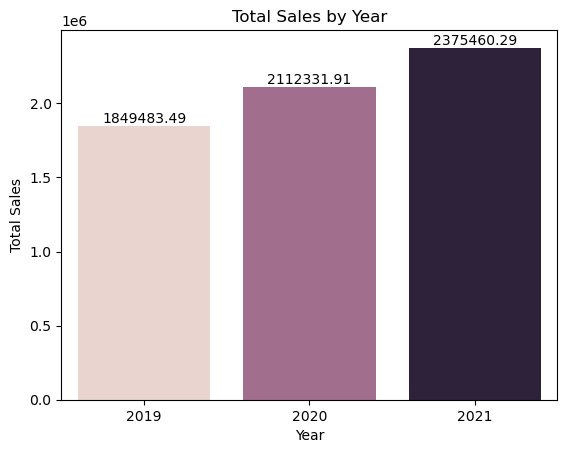

In [75]:

plt.title("Total Sales by Year")
ax = sns.barplot(bob_daily.groupby("year").agg({"price":"sum"}), x="year", y="price", hue="year", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Year", ylabel="Total Sales")
plt.show()

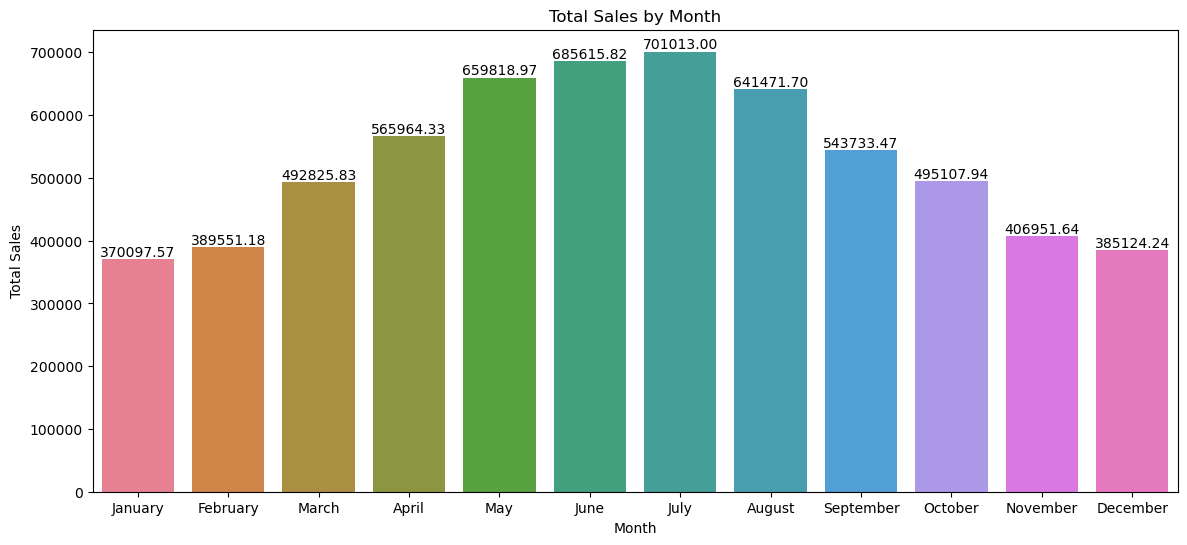

In [76]:
plt.subplots(figsize = (14, 6))

plt.title("Total Sales by Month")
ax = sns.barplot(bob_daily.groupby("month", observed=False).agg({"price":"sum"}), x="month", y="price", hue="month", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Month", ylabel="Total Sales")
plt.show()

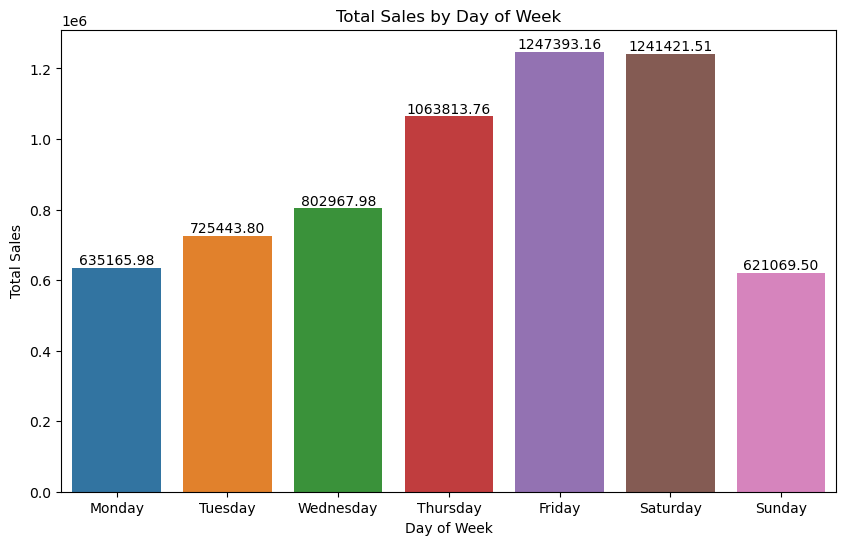

In [77]:
plt.subplots(figsize = (10, 6))

plt.title("Total Sales by Day of Week")
ax = sns.barplot(bob_daily.groupby("day_of_week", observed=False).agg({"price":"sum"}), x="day_of_week", y="price", hue="day_of_week", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Day of Week", ylabel="Total Sales")
plt.show()

In [78]:
monthly_avg_sales = bob_daily.groupby("year_month", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
yearly_avg_sales = bob_daily.groupby("year", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()

month_sales_dict = dict(zip(monthly_avg_sales['year_month'], monthly_avg_sales['price']))
year_sales_dict = dict(zip(yearly_avg_sales['year'], yearly_avg_sales['price']))

In [79]:
bob_daily['monthly_avg_sales'] = bob_daily['year_month'].map(month_sales_dict)
bob_daily['yearly_avg_sales'] = bob_daily['year'].map(year_sales_dict)
bob_daily

,date,price,item_count,month,year,year_month,day_of_week,monthly_avg_sales,yearly_avg_sales
0,2019-01-01,3956.02,421,January,2019,2019-01,Tuesday,3476.004839,5067.078055
1,2019-01-02,2941.22,330,January,2019,2019-01,Wednesday,3476.004839,5067.078055
2,2019-01-03,3914.70,438,January,2019,2019-01,Thursday,3476.004839,5067.078055
3,2019-01-04,4944.71,559,January,2019,2019-01,Friday,3476.004839,5067.078055
4,2019-01-05,4845.76,545,January,2019,2019-01,Saturday,3476.004839,5067.078055
...,...,...,...,...,...,...,...,...,...
1091,2021-12-27,1793.41,184,December,2021,2021-12,Monday,4766.140000,6508.110384
1092,2021-12-28,3390.57,340,December,2021,2021-12,Tuesday,4766.140000,6508.110384
1093,2021-12-29,3698.71,366,December,2021,2021-12,Wednesday,4766.140000,6508.110384
1094,2021-12-30,5257.53,525,December,2021,2021-12,Thursday,4766.140000,6508.110384


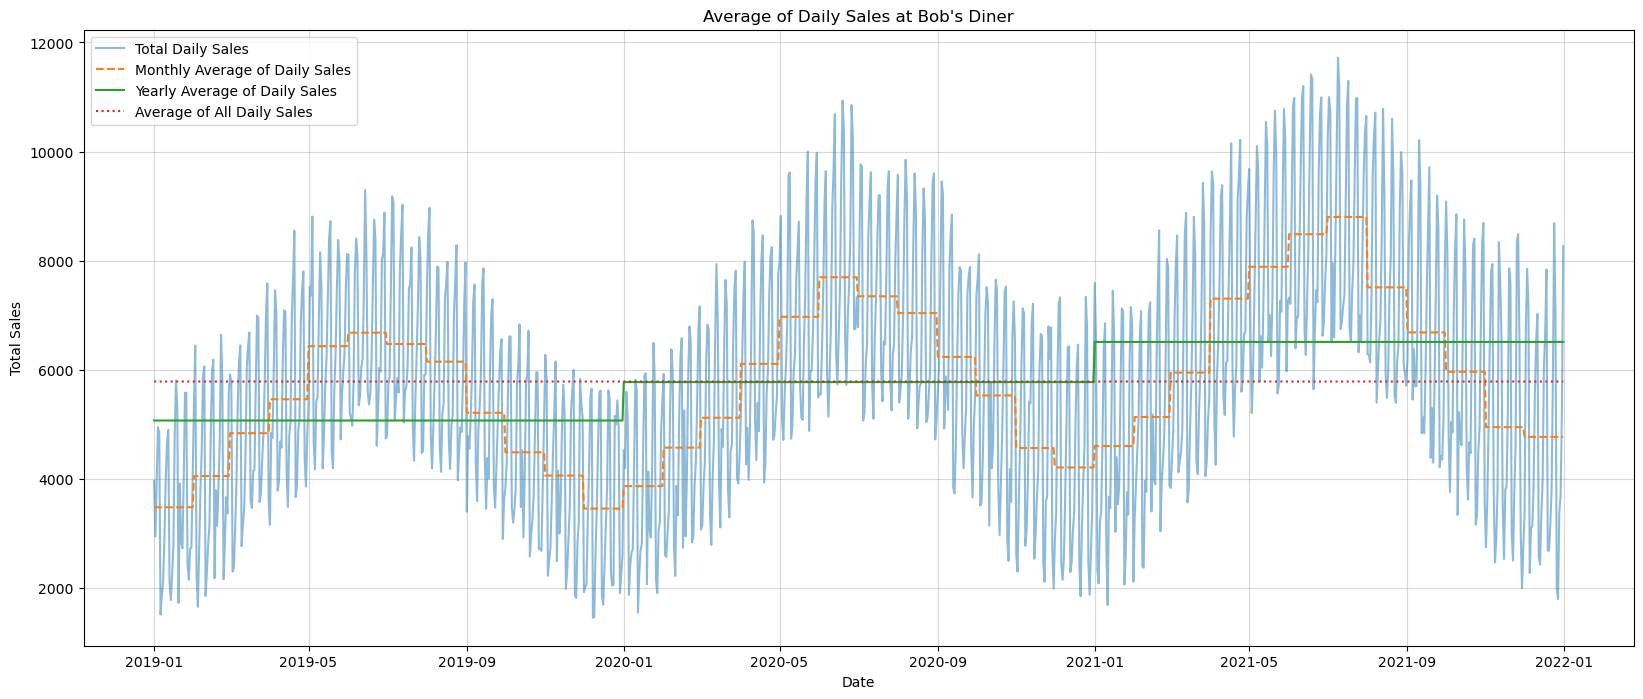

In [80]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average of Daily Sales at Bob's Diner")

ax = sns.lineplot(data=bob_daily, x="date", y="price", legend="auto", label="Total Daily Sales", alpha=0.5)
sns.lineplot(data=bob_daily, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=bob_daily, x="date", y="yearly_avg_sales", label="Yearly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=bob_daily, x="date", y=bob_daily["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

### Corner Cafe Sales

In [81]:
sorted(df["store_name"].unique())

['Beachfront Bar',
 "Bob's Diner",
 'Corner Cafe',
 'Fou Cher',
 'Surfs Up',
 'Sweet Shack']

In [82]:
corner = df[df["store_name"] == "Corner Cafe"]
corner

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
19,2019-01-01,91,15.46,1,Halibut with Bread Dinner,468,5,Corner Cafe,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
20,2019-01-01,93,12.44,1,Lamb with Bread Entree,585,5,Corner Cafe,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
118,2019-01-02,93,12.44,1,Lamb with Bread Entree,585,5,Corner Cafe,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Wednesday
411,2019-01-05,50,26.37,1,Pike Lunch,653,5,Corner Cafe,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Saturday
419,2019-01-05,91,15.46,1,Halibut with Bread Dinner,468,5,Corner Cafe,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Saturday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108922,2021-12-25,84,19.77,1,BBQ Pork Steak,855,5,Corner Cafe,2021-12-20/2021-12-26,December,2021,2021-12,2021Q4,Saturday
109014,2021-12-26,58,13.66,1,Lamb with Vegetables Meal,485,5,Corner Cafe,2021-12-20/2021-12-26,December,2021,2021-12,2021Q4,Sunday
109017,2021-12-26,71,3.98,1,Frozen Milky Smoothy,211,5,Corner Cafe,2021-12-20/2021-12-26,December,2021,2021-12,2021Q4,Sunday
109020,2021-12-26,84,19.77,1,BBQ Pork Steak,855,5,Corner Cafe,2021-12-20/2021-12-26,December,2021,2021-12,2021Q4,Sunday


In [83]:
corner_daily = corner.groupby(by=["date"], sort=False).agg({"price": "sum", "item_count": "sum"}).reset_index()
corner_daily

,date,price,item_count
0,2019-01-01,27.90,2
1,2019-01-02,12.44,1
2,2019-01-05,41.83,2
3,2019-01-06,11.53,2
4,2019-01-08,13.66,1
...,...,...,...
778,2021-12-23,19.99,2
779,2021-12-24,12.44,1
780,2021-12-25,19.77,1
781,2021-12-26,37.41,3


In [84]:
corner_daily['month'] = pd.Categorical(corner_daily['date'].dt.month_name(), list(calendar.month_name)[1:])
corner_daily['year'] = corner_daily['date'].dt.year
corner_daily['year_month'] = corner_daily["date"].dt.to_period("M")
corner_daily['day_of_week'] = pd.Categorical(corner_daily['date'].dt.day_name(), list(calendar.day_name))
corner_daily

,date,price,item_count,month,year,year_month,day_of_week
0,2019-01-01,27.90,2,January,2019,2019-01,Tuesday
1,2019-01-02,12.44,1,January,2019,2019-01,Wednesday
2,2019-01-05,41.83,2,January,2019,2019-01,Saturday
3,2019-01-06,11.53,2,January,2019,2019-01,Sunday
4,2019-01-08,13.66,1,January,2019,2019-01,Tuesday
...,...,...,...,...,...,...,...
778,2021-12-23,19.99,2,December,2021,2021-12,Thursday
779,2021-12-24,12.44,1,December,2021,2021-12,Friday
780,2021-12-25,19.77,1,December,2021,2021-12,Saturday
781,2021-12-26,37.41,3,December,2021,2021-12,Sunday


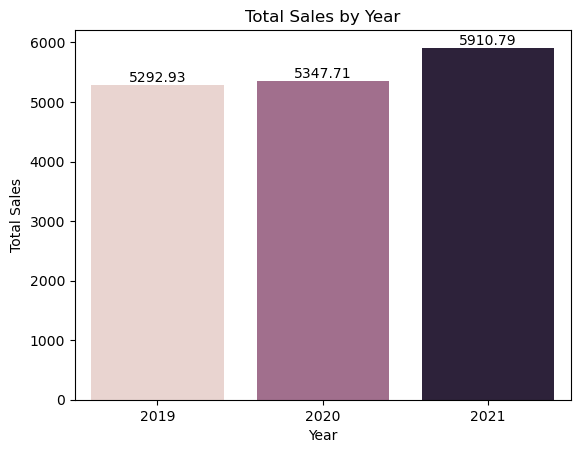

In [85]:

plt.title("Total Sales by Year")
ax = sns.barplot(corner_daily.groupby("year").agg({"price":"sum"}), x="year", y="price", hue="year", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Year", ylabel="Total Sales")
plt.show()

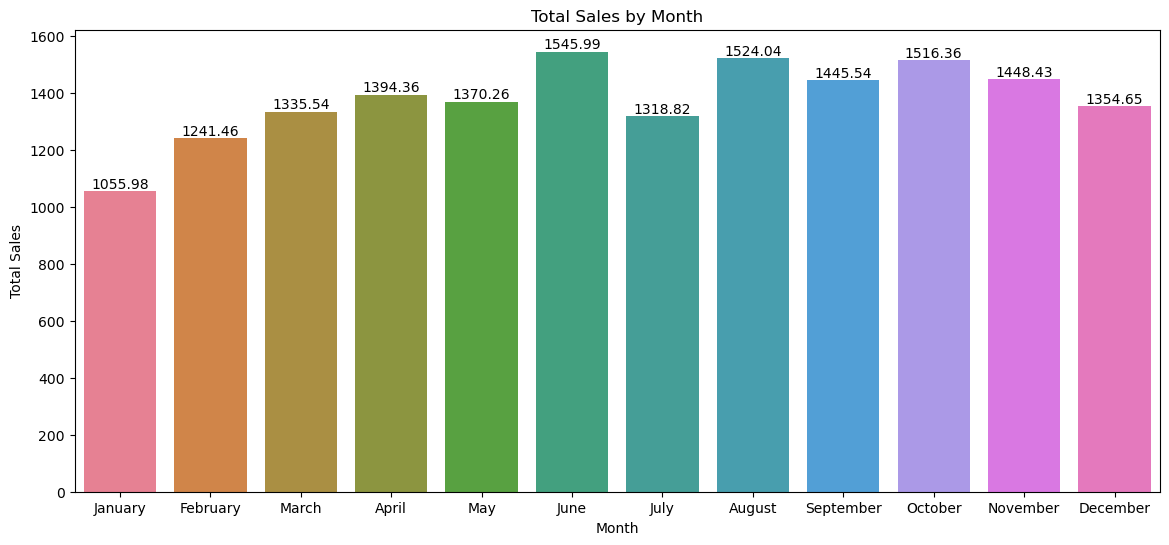

In [86]:
plt.subplots(figsize = (14, 6))

plt.title("Total Sales by Month")
ax = sns.barplot(corner_daily.groupby("month", observed=False).agg({"price":"sum"}), x="month", y="price", hue="month", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Month", ylabel="Total Sales")
plt.show()

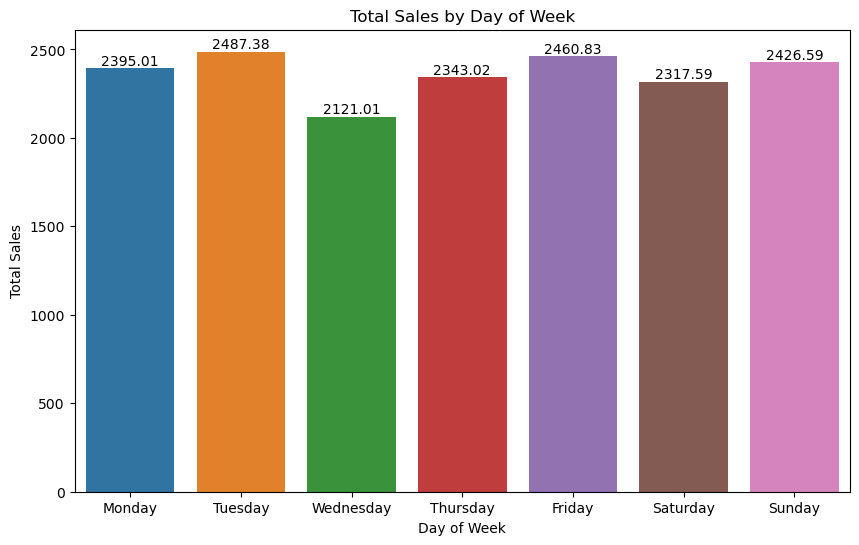

In [87]:
plt.subplots(figsize = (10, 6))

plt.title("Total Sales by Day of Week")
ax = sns.barplot(corner_daily.groupby("day_of_week", observed=False).agg({"price":"sum"}), x="day_of_week", y="price", hue="day_of_week", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Day of Week", ylabel="Total Sales")
plt.show()

In [88]:
monthly_avg_sales = corner_daily.groupby("year_month", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
yearly_avg_sales = corner_daily.groupby("year", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()

month_sales_dict = dict(zip(monthly_avg_sales['year_month'], monthly_avg_sales['price']))
year_sales_dict = dict(zip(yearly_avg_sales['year'], yearly_avg_sales['price']))

In [89]:
corner_daily['monthly_avg_sales'] = corner_daily['year_month'].map(month_sales_dict)
corner_daily['yearly_avg_sales'] = corner_daily['year'].map(year_sales_dict)
corner_daily

,date,price,item_count,month,year,year_month,day_of_week,monthly_avg_sales,yearly_avg_sales
0,2019-01-01,27.90,2,January,2019,2019-01,Tuesday,18.09500,20.756588
1,2019-01-02,12.44,1,January,2019,2019-01,Wednesday,18.09500,20.756588
2,2019-01-05,41.83,2,January,2019,2019-01,Saturday,18.09500,20.756588
3,2019-01-06,11.53,2,January,2019,2019-01,Sunday,18.09500,20.756588
4,2019-01-08,13.66,1,January,2019,2019-01,Tuesday,18.09500,20.756588
...,...,...,...,...,...,...,...,...,...
778,2021-12-23,19.99,2,December,2021,2021-12,Thursday,24.55087,21.493782
779,2021-12-24,12.44,1,December,2021,2021-12,Friday,24.55087,21.493782
780,2021-12-25,19.77,1,December,2021,2021-12,Saturday,24.55087,21.493782
781,2021-12-26,37.41,3,December,2021,2021-12,Sunday,24.55087,21.493782


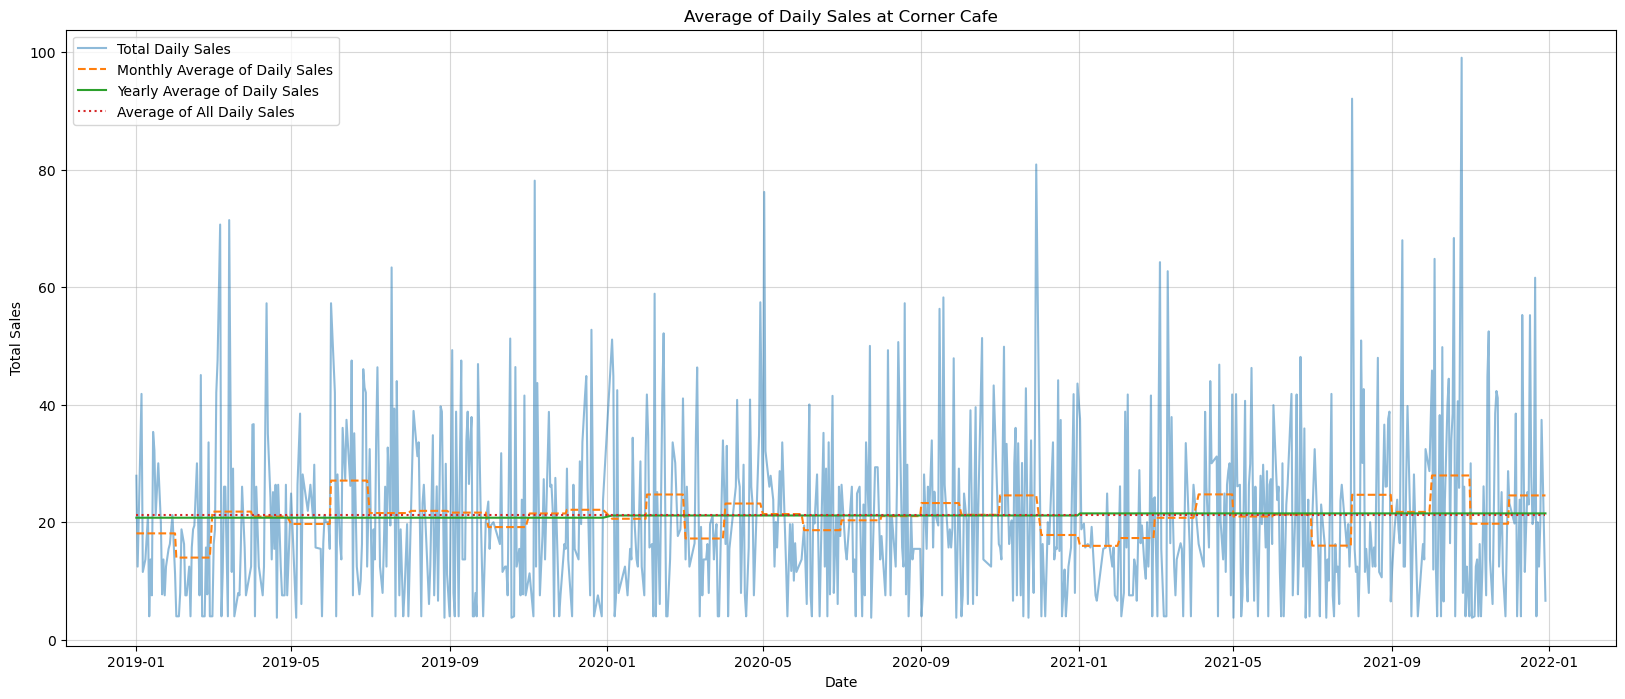

In [90]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average of Daily Sales at Corner Cafe")

ax = sns.lineplot(data=corner_daily, x="date", y="price", legend="auto", label="Total Daily Sales", alpha=0.5)
sns.lineplot(data=corner_daily, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=corner_daily, x="date", y="yearly_avg_sales", label="Yearly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=corner_daily, x="date", y=corner_daily["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

### Fou Cher Sales

In [91]:
sorted(df["store_name"].unique())

['Beachfront Bar',
 "Bob's Diner",
 'Corner Cafe',
 'Fou Cher',
 'Surfs Up',
 'Sweet Shack']

In [92]:
fou = df[df["store_name"] == "Fou Cher"]
fou

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
16,2019-01-01,75,5.60,1,Blue Ribbon Milky Smoothy,459,4,Fou Cher,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
115,2019-01-02,80,107.96,2,Blue Ribbon Fruity Vegi Lunch,881,4,Fou Cher,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Wednesday
216,2019-01-03,80,107.96,2,Blue Ribbon Fruity Vegi Lunch,881,4,Fou Cher,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Thursday
218,2019-01-03,97,28.65,1,Original Fruity Cod with Bread and Vegetables ...,744,4,Fou Cher,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Thursday
316,2019-01-04,80,53.98,1,Blue Ribbon Fruity Vegi Lunch,881,4,Fou Cher,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108921,2021-12-25,80,107.96,2,Blue Ribbon Fruity Vegi Lunch,881,4,Fou Cher,2021-12-20/2021-12-26,December,2021,2021-12,2021Q4,Saturday
109117,2021-12-27,75,5.60,1,Blue Ribbon Milky Smoothy,459,4,Fou Cher,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Monday
109119,2021-12-27,80,53.98,1,Blue Ribbon Fruity Vegi Lunch,881,4,Fou Cher,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Monday
109216,2021-12-28,79,3.75,1,Fruity Frozen Slushy,137,4,Fou Cher,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Tuesday


In [93]:
fou_daily = fou.groupby(by=["date"], sort=False).agg({"price": "sum", "item_count": "sum"}).reset_index()
fou_daily

,date,price,item_count
0,2019-01-01,5.60,1
1,2019-01-02,107.96,2
2,2019-01-03,136.61,3
3,2019-01-04,53.98,1
4,2019-01-05,34.25,2
...,...,...,...
762,2021-12-24,28.65,1
763,2021-12-25,107.96,2
764,2021-12-27,59.58,2
765,2021-12-28,3.75,1


In [94]:
fou_daily['month'] = pd.Categorical(fou_daily['date'].dt.month_name(), list(calendar.month_name)[1:])
fou_daily['year'] = fou_daily['date'].dt.year
fou_daily['year_month'] = fou_daily["date"].dt.to_period("M")
fou_daily['day_of_week'] = pd.Categorical(fou_daily['date'].dt.day_name(), list(calendar.day_name))
fou_daily

,date,price,item_count,month,year,year_month,day_of_week
0,2019-01-01,5.60,1,January,2019,2019-01,Tuesday
1,2019-01-02,107.96,2,January,2019,2019-01,Wednesday
2,2019-01-03,136.61,3,January,2019,2019-01,Thursday
3,2019-01-04,53.98,1,January,2019,2019-01,Friday
4,2019-01-05,34.25,2,January,2019,2019-01,Saturday
...,...,...,...,...,...,...,...
762,2021-12-24,28.65,1,December,2021,2021-12,Friday
763,2021-12-25,107.96,2,December,2021,2021-12,Saturday
764,2021-12-27,59.58,2,December,2021,2021-12,Monday
765,2021-12-28,3.75,1,December,2021,2021-12,Tuesday


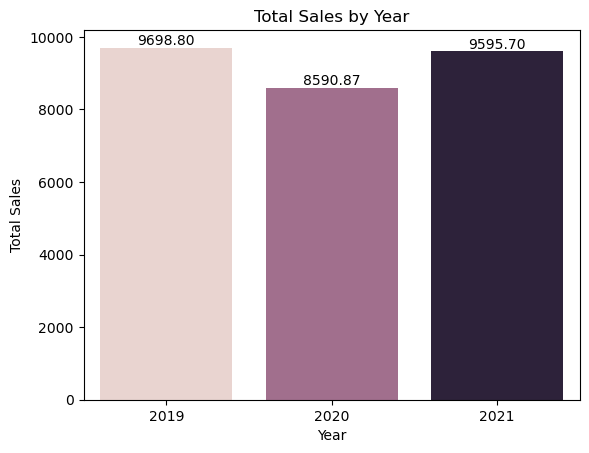

In [95]:

plt.title("Total Sales by Year")
ax = sns.barplot(fou_daily.groupby("year").agg({"price":"sum"}), x="year", y="price", hue="year", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Year", ylabel="Total Sales")
plt.show()

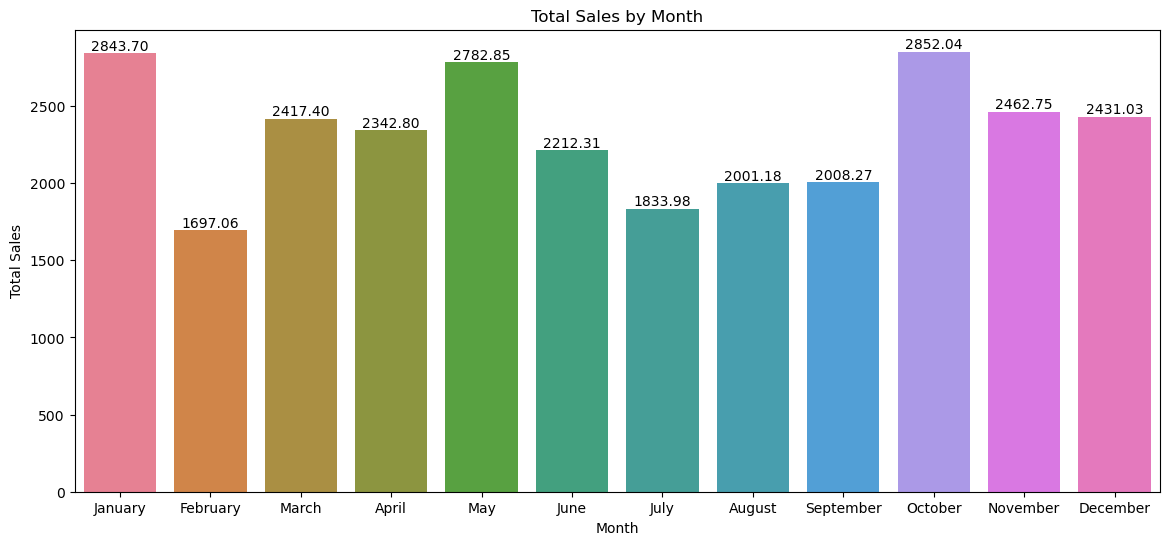

In [96]:
plt.subplots(figsize = (14, 6))

plt.title("Total Sales by Month")
ax = sns.barplot(fou_daily.groupby("month", observed=False).agg({"price":"sum"}), x="month", y="price", hue="month", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Month", ylabel="Total Sales")
plt.show()

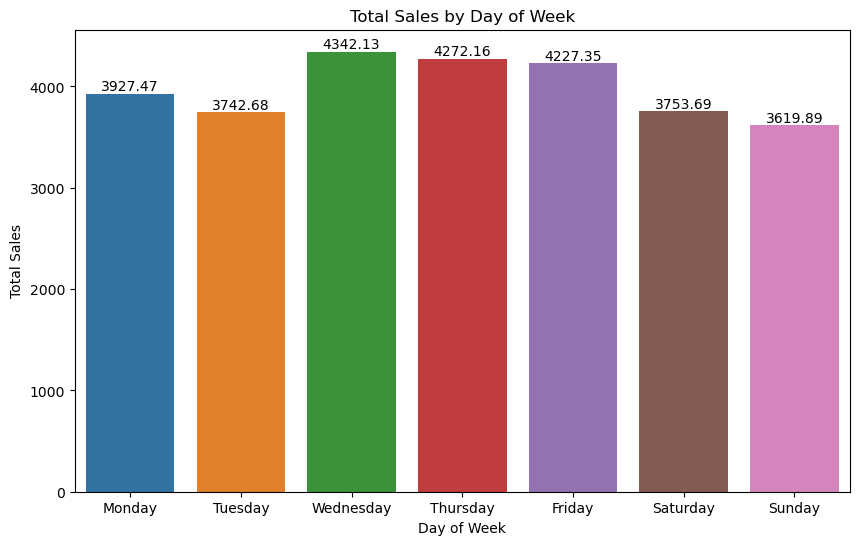

In [97]:
plt.subplots(figsize = (10, 6))

plt.title("Total Sales by Day of Week")
ax = sns.barplot(fou_daily.groupby("day_of_week", observed=False).agg({"price":"sum"}), x="day_of_week", y="price", hue="day_of_week", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Day of Week", ylabel="Total Sales")
plt.show()

In [98]:
monthly_avg_sales = fou_daily.groupby("year_month", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
yearly_avg_sales = fou_daily.groupby("year", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()

month_sales_dict = dict(zip(monthly_avg_sales['year_month'], monthly_avg_sales['price']))
year_sales_dict = dict(zip(yearly_avg_sales['year'], yearly_avg_sales['price']))

In [99]:
fou_daily['monthly_avg_sales'] = fou_daily['year_month'].map(month_sales_dict)
fou_daily['yearly_avg_sales'] = fou_daily['year'].map(year_sales_dict)
fou_daily

,date,price,item_count,month,year,year_month,day_of_week,monthly_avg_sales,yearly_avg_sales
0,2019-01-01,5.60,1,January,2019,2019-01,Tuesday,43.5750,37.447104
1,2019-01-02,107.96,2,January,2019,2019-01,Wednesday,43.5750,37.447104
2,2019-01-03,136.61,3,January,2019,2019-01,Thursday,43.5750,37.447104
3,2019-01-04,53.98,1,January,2019,2019-01,Friday,43.5750,37.447104
4,2019-01-05,34.25,2,January,2019,2019-01,Saturday,43.5750,37.447104
...,...,...,...,...,...,...,...,...,...
762,2021-12-24,28.65,1,December,2021,2021-12,Friday,46.4765,36.906538
763,2021-12-25,107.96,2,December,2021,2021-12,Saturday,46.4765,36.906538
764,2021-12-27,59.58,2,December,2021,2021-12,Monday,46.4765,36.906538
765,2021-12-28,3.75,1,December,2021,2021-12,Tuesday,46.4765,36.906538


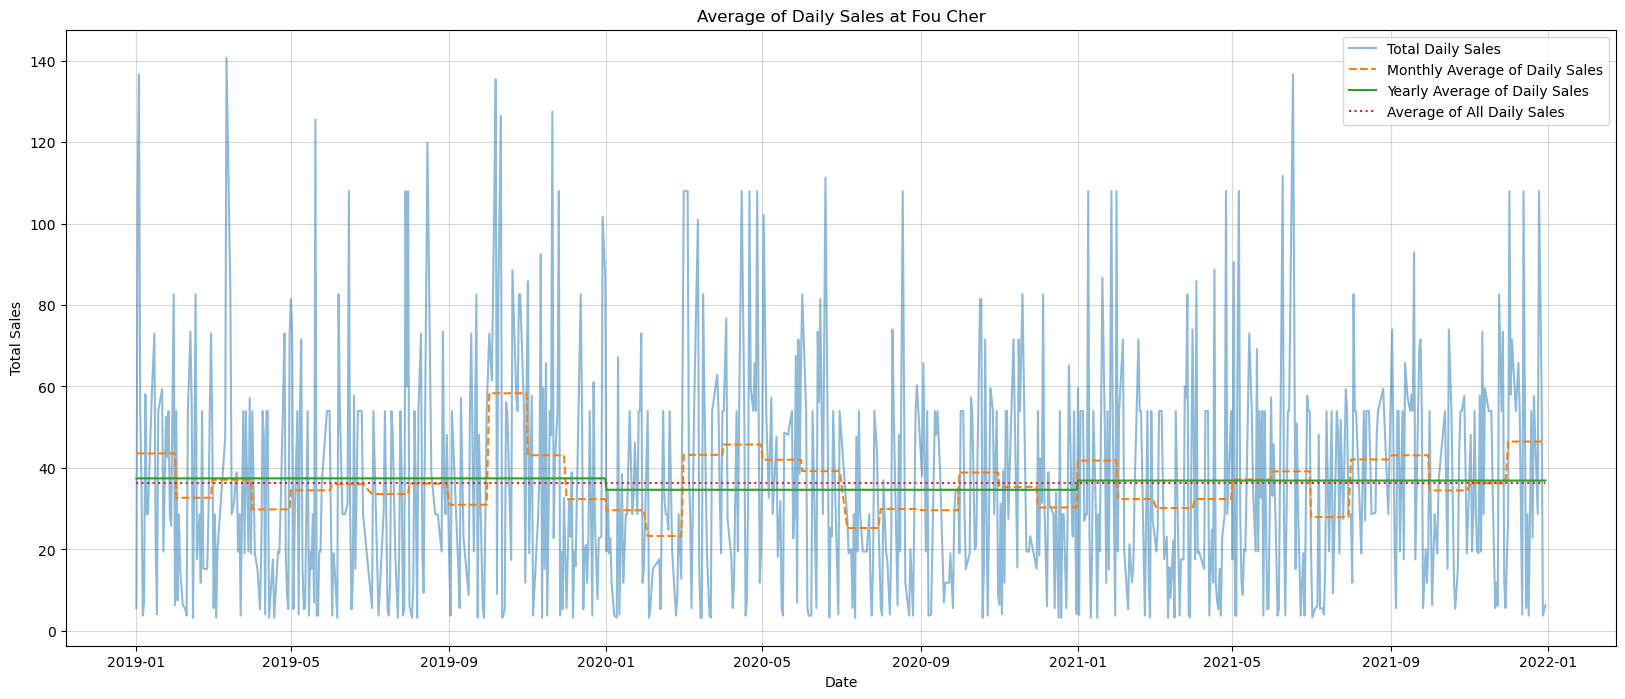

In [100]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average of Daily Sales at Fou Cher")

ax = sns.lineplot(data=fou_daily, x="date", y="price", legend="auto", label="Total Daily Sales", alpha=0.5)
sns.lineplot(data=fou_daily, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=fou_daily, x="date", y="yearly_avg_sales", label="Yearly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=fou_daily, x="date", y=fou_daily["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

### Surfs Up Sales

In [101]:
sorted(df["store_name"].unique())

['Beachfront Bar',
 "Bob's Diner",
 'Corner Cafe',
 'Fou Cher',
 'Surfs Up',
 'Sweet Shack']

In [102]:
surf = df[df["store_name"] == "Surfs Up"]
surf

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
8,2019-01-01,27,26.21,1,Steak Meal,607,6,Surfs Up,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
9,2019-01-01,35,4.36,1,Blue Ribbon Cocktail,456,6,Surfs Up,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Tuesday
116,2019-01-02,89,3.06,1,Awesome Soft Drink,248,6,Surfs Up,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Wednesday
119,2019-01-02,94,5.71,1,Fruity Milky Smoothy,331,6,Surfs Up,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Wednesday
217,2019-01-03,94,5.71,1,Fruity Milky Smoothy,331,6,Surfs Up,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Thursday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
109120,2021-12-27,89,6.12,2,Awesome Soft Drink,248,6,Surfs Up,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Monday
109208,2021-12-28,27,26.21,1,Steak Meal,607,6,Surfs Up,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Tuesday
109217,2021-12-28,89,3.06,1,Awesome Soft Drink,248,6,Surfs Up,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Tuesday
109308,2021-12-29,35,4.36,1,Blue Ribbon Cocktail,456,6,Surfs Up,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Wednesday


In [103]:
surf_daily = surf.groupby(by=["date"], sort=False).agg({"price": "sum", "item_count": "sum"}).reset_index()
surf_daily

,date,price,item_count
0,2019-01-01,30.57,2
1,2019-01-02,8.77,2
2,2019-01-03,5.71,1
3,2019-01-06,31.92,2
4,2019-01-07,30.95,5
...,...,...,...
897,2021-12-26,3.06,1
898,2021-12-27,6.12,2
899,2021-12-28,29.27,2
900,2021-12-29,4.36,1


In [104]:
surf_daily['month'] = pd.Categorical(surf_daily['date'].dt.month_name(), list(calendar.month_name)[1:])
surf_daily['year'] = surf_daily['date'].dt.year
surf_daily['year_month'] = surf_daily["date"].dt.to_period("M")
surf_daily['day_of_week'] = pd.Categorical(surf_daily['date'].dt.day_name(), list(calendar.day_name))
surf_daily

,date,price,item_count,month,year,year_month,day_of_week
0,2019-01-01,30.57,2,January,2019,2019-01,Tuesday
1,2019-01-02,8.77,2,January,2019,2019-01,Wednesday
2,2019-01-03,5.71,1,January,2019,2019-01,Thursday
3,2019-01-06,31.92,2,January,2019,2019-01,Sunday
4,2019-01-07,30.95,5,January,2019,2019-01,Monday
...,...,...,...,...,...,...,...
897,2021-12-26,3.06,1,December,2021,2021-12,Sunday
898,2021-12-27,6.12,2,December,2021,2021-12,Monday
899,2021-12-28,29.27,2,December,2021,2021-12,Tuesday
900,2021-12-29,4.36,1,December,2021,2021-12,Wednesday


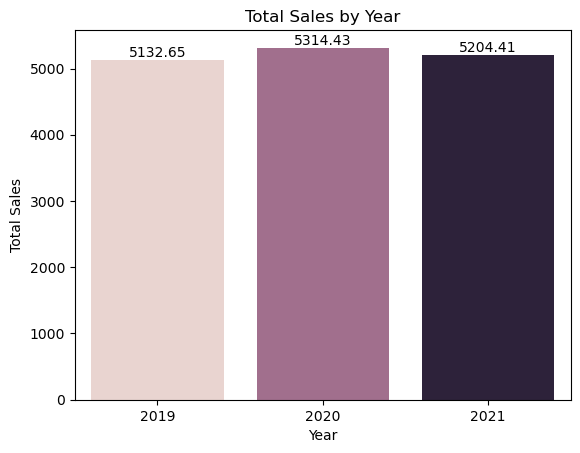

In [105]:

plt.title("Total Sales by Year")
ax = sns.barplot(surf_daily.groupby("year").agg({"price":"sum"}), x="year", y="price", hue="year", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Year", ylabel="Total Sales")
plt.show()

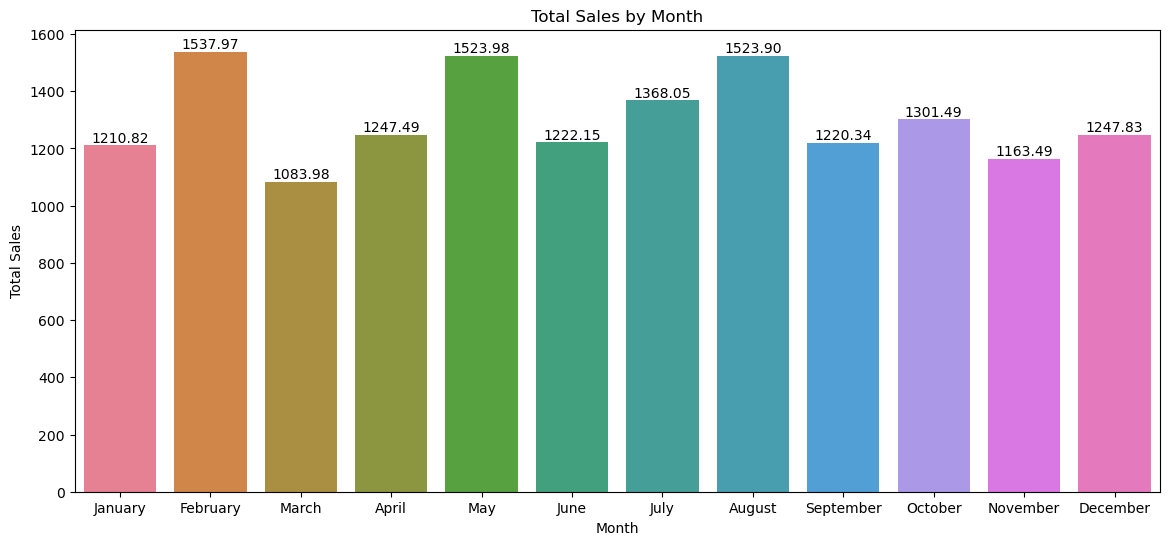

In [106]:
plt.subplots(figsize = (14, 6))

plt.title("Total Sales by Month")
ax = sns.barplot(surf_daily.groupby("month", observed=False).agg({"price":"sum"}), x="month", y="price", hue="month", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Month", ylabel="Total Sales")
plt.show()

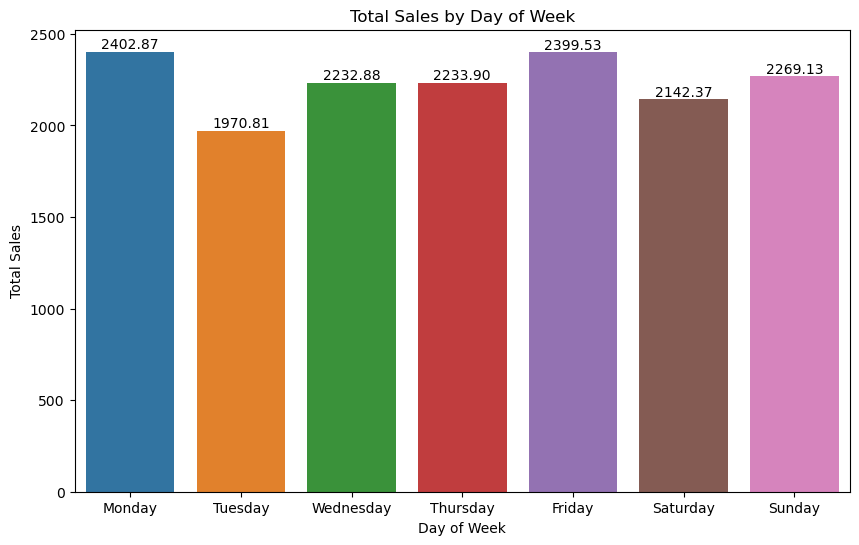

In [107]:
plt.subplots(figsize = (10, 6))

plt.title("Total Sales by Day of Week")
ax = sns.barplot(surf_daily.groupby("day_of_week", observed=False).agg({"price":"sum"}), x="day_of_week", y="price", hue="day_of_week", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Day of Week", ylabel="Total Sales")
plt.show()

In [108]:
monthly_avg_sales = surf_daily.groupby("year_month", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
yearly_avg_sales = surf_daily.groupby("year", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()

month_sales_dict = dict(zip(monthly_avg_sales['year_month'], monthly_avg_sales['price']))
year_sales_dict = dict(zip(yearly_avg_sales['year'], yearly_avg_sales['price']))

In [109]:
surf_daily['monthly_avg_sales'] = surf_daily['year_month'].map(month_sales_dict)
surf_daily['yearly_avg_sales'] = surf_daily['year'].map(year_sales_dict)
surf_daily

,date,price,item_count,month,year,year_month,day_of_week,monthly_avg_sales,yearly_avg_sales
0,2019-01-01,30.57,2,January,2019,2019-01,Tuesday,18.798095,17.108833
1,2019-01-02,8.77,2,January,2019,2019-01,Wednesday,18.798095,17.108833
2,2019-01-03,5.71,1,January,2019,2019-01,Thursday,18.798095,17.108833
3,2019-01-06,31.92,2,January,2019,2019-01,Sunday,18.798095,17.108833
4,2019-01-07,30.95,5,January,2019,2019-01,Monday,18.798095,17.108833
...,...,...,...,...,...,...,...,...,...
897,2021-12-26,3.06,1,December,2021,2021-12,Sunday,15.721304,17.233146
898,2021-12-27,6.12,2,December,2021,2021-12,Monday,15.721304,17.233146
899,2021-12-28,29.27,2,December,2021,2021-12,Tuesday,15.721304,17.233146
900,2021-12-29,4.36,1,December,2021,2021-12,Wednesday,15.721304,17.233146


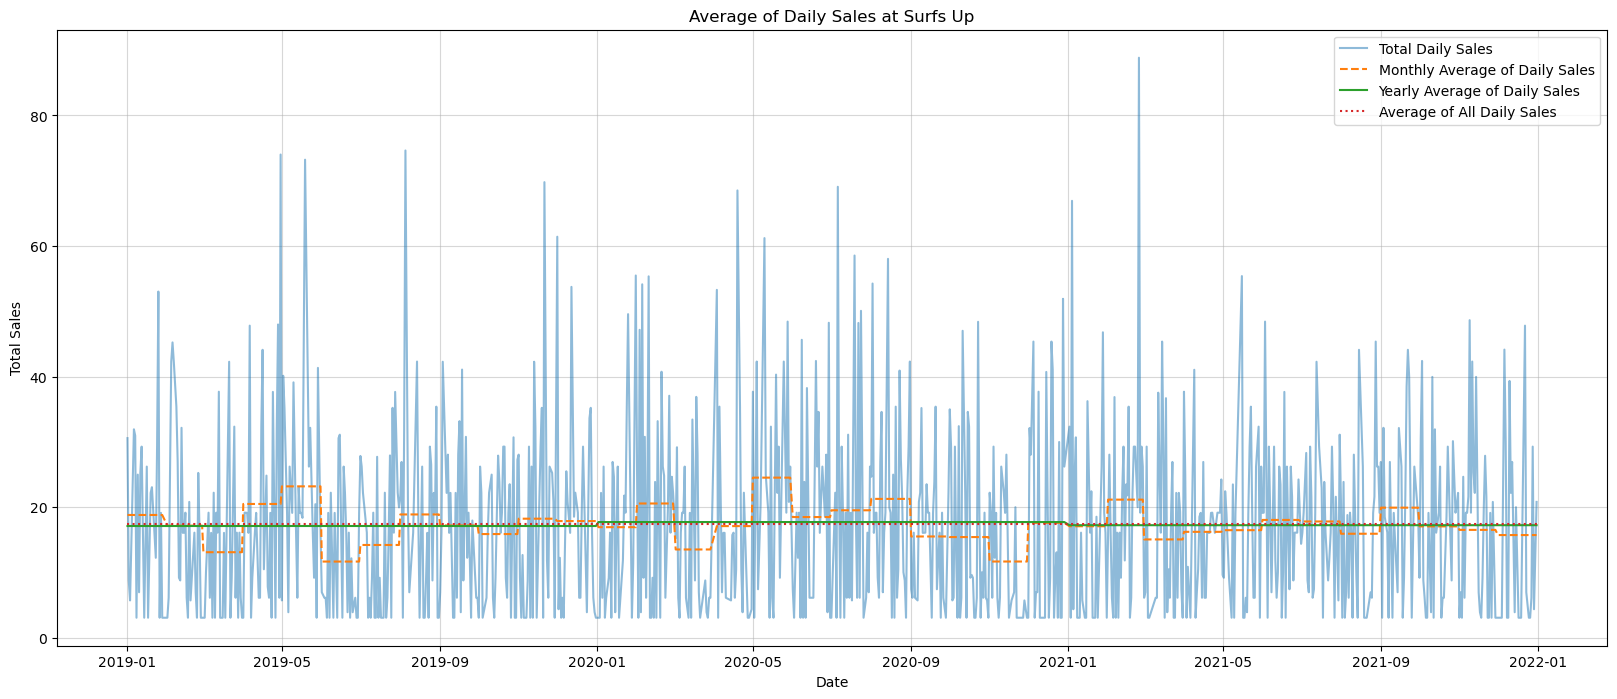

In [110]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average of Daily Sales at Surfs Up")

ax = sns.lineplot(data=surf_daily, x="date", y="price", legend="auto", label="Total Daily Sales", alpha=0.5)
sns.lineplot(data=surf_daily, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=surf_daily, x="date", y="yearly_avg_sales", label="Yearly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=surf_daily, x="date", y=surf_daily["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

### Sweet Shack Sales

In [111]:
sorted(df["store_name"].unique())

['Beachfront Bar',
 "Bob's Diner",
 'Corner Cafe',
 'Fou Cher',
 'Surfs Up',
 'Sweet Shack']

In [112]:
sw_shack = df[df["store_name"] == "Sweet Shack"]
sw_shack

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
109,2019-01-02,49,1.39,1,Awesome Smoothy,78,3,Sweet Shack,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Wednesday
210,2019-01-03,49,2.78,2,Awesome Smoothy,78,3,Sweet Shack,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Thursday
311,2019-01-04,49,2.78,2,Awesome Smoothy,78,3,Sweet Shack,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Friday
410,2019-01-05,49,2.78,2,Awesome Smoothy,78,3,Sweet Shack,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Saturday
512,2019-01-06,49,4.17,3,Awesome Smoothy,78,3,Sweet Shack,2018-12-31/2019-01-06,January,2019,2019-01,2019Q1,Sunday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
108815,2021-12-24,49,2.78,2,Awesome Smoothy,78,3,Sweet Shack,2021-12-20/2021-12-26,December,2021,2021-12,2021Q4,Friday
108914,2021-12-25,49,4.17,3,Awesome Smoothy,78,3,Sweet Shack,2021-12-20/2021-12-26,December,2021,2021-12,2021Q4,Saturday
109012,2021-12-26,49,5.56,4,Awesome Smoothy,78,3,Sweet Shack,2021-12-20/2021-12-26,December,2021,2021-12,2021Q4,Sunday
109113,2021-12-27,49,2.78,2,Awesome Smoothy,78,3,Sweet Shack,2021-12-27/2022-01-02,December,2021,2021-12,2021Q4,Monday


In [113]:
sw_shack_daily = sw_shack.groupby(by=["date"], sort=False).agg({"price": "sum", "item_count": "sum"}).reset_index()
sw_shack_daily

,date,price,item_count
0,2019-01-02,1.39,1
1,2019-01-03,2.78,2
2,2019-01-04,2.78,2
3,2019-01-05,2.78,2
4,2019-01-06,4.17,3
...,...,...,...
888,2021-12-24,2.78,2
889,2021-12-25,4.17,3
890,2021-12-26,5.56,4
891,2021-12-27,2.78,2


In [114]:
sw_shack_daily['month'] = pd.Categorical(sw_shack_daily['date'].dt.month_name(), list(calendar.month_name)[1:])
sw_shack_daily['year'] = sw_shack_daily['date'].dt.year
sw_shack_daily['year_month'] = sw_shack_daily["date"].dt.to_period("M")
sw_shack_daily['day_of_week'] = pd.Categorical(sw_shack_daily['date'].dt.day_name(), list(calendar.day_name))
sw_shack_daily

,date,price,item_count,month,year,year_month,day_of_week
0,2019-01-02,1.39,1,January,2019,2019-01,Wednesday
1,2019-01-03,2.78,2,January,2019,2019-01,Thursday
2,2019-01-04,2.78,2,January,2019,2019-01,Friday
3,2019-01-05,2.78,2,January,2019,2019-01,Saturday
4,2019-01-06,4.17,3,January,2019,2019-01,Sunday
...,...,...,...,...,...,...,...
888,2021-12-24,2.78,2,December,2021,2021-12,Friday
889,2021-12-25,4.17,3,December,2021,2021-12,Saturday
890,2021-12-26,5.56,4,December,2021,2021-12,Sunday
891,2021-12-27,2.78,2,December,2021,2021-12,Monday


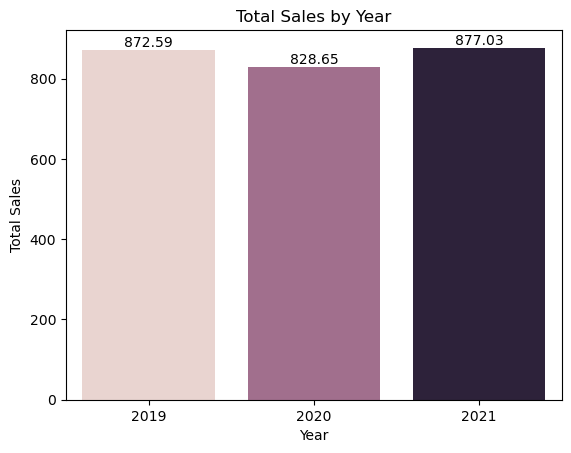

In [115]:

plt.title("Total Sales by Year")
ax = sns.barplot(sw_shack_daily.groupby("year").agg({"price":"sum"}), x="year", y="price", hue="year", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Year", ylabel="Total Sales")
plt.show()

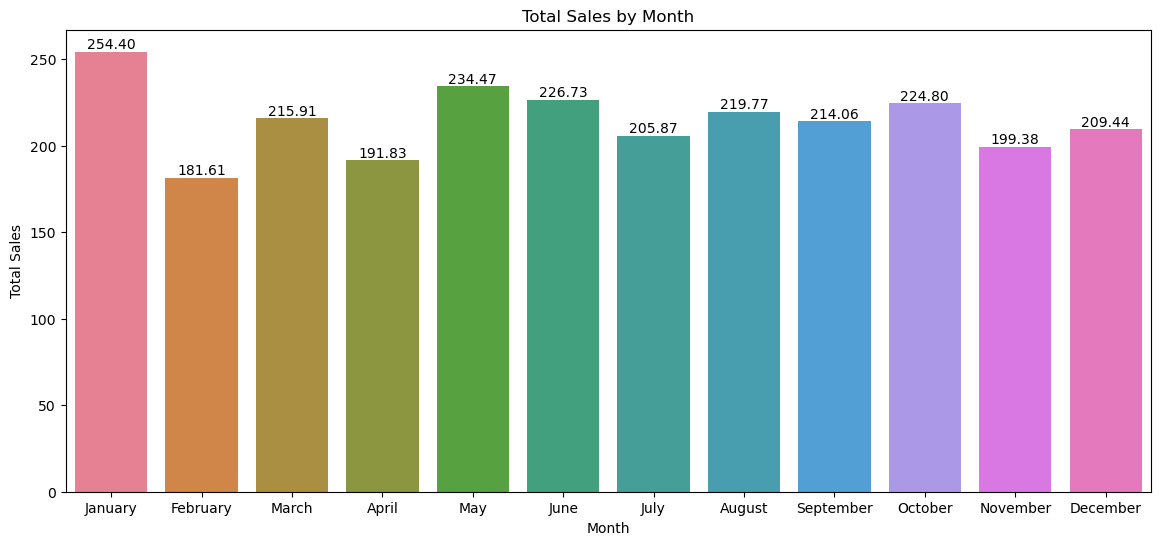

In [116]:
plt.subplots(figsize = (14, 6))

plt.title("Total Sales by Month")
ax = sns.barplot(sw_shack_daily.groupby("month", observed=False).agg({"price":"sum"}), x="month", y="price", hue="month", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Month", ylabel="Total Sales")
plt.show()

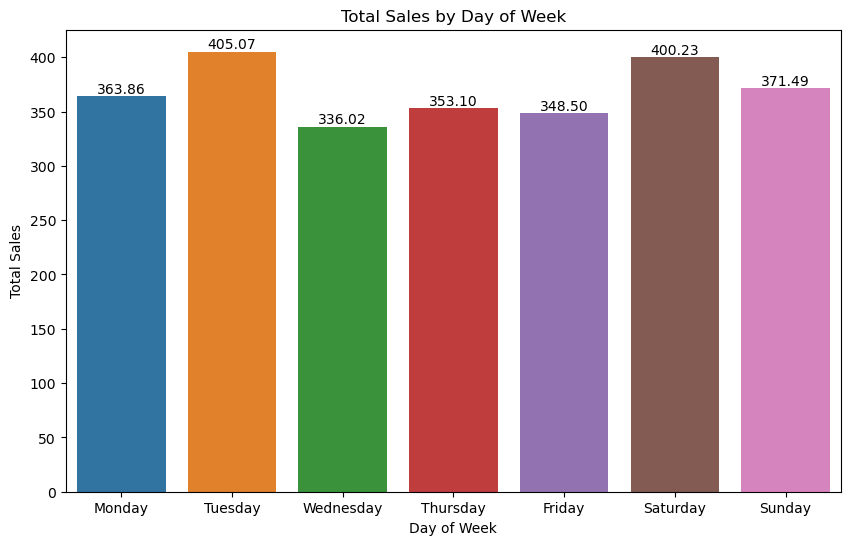

In [117]:
plt.subplots(figsize = (10, 6))

plt.title("Total Sales by Day of Week")
ax = sns.barplot(sw_shack_daily.groupby("day_of_week", observed=False).agg({"price":"sum"}), x="day_of_week", y="price", hue="day_of_week", legend=False)
for i in ax.containers:
    ax.bar_label(i, fmt="%.2f")

ax.set(xlabel="Day of Week", ylabel="Total Sales")
plt.show()

In [118]:
monthly_avg_sales = sw_shack_daily.groupby("year_month", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()
yearly_avg_sales = sw_shack_daily.groupby("year", sort=False).agg({"price":"mean", "item_count":"mean"}).reset_index()

month_sales_dict = dict(zip(monthly_avg_sales['year_month'], monthly_avg_sales['price']))
year_sales_dict = dict(zip(yearly_avg_sales['year'], yearly_avg_sales['price']))

In [119]:
sw_shack_daily['monthly_avg_sales'] = sw_shack_daily['year_month'].map(month_sales_dict)
sw_shack_daily['yearly_avg_sales'] = sw_shack_daily['year'].map(year_sales_dict)
sw_shack_daily

,date,price,item_count,month,year,year_month,day_of_week,monthly_avg_sales,yearly_avg_sales
0,2019-01-02,1.39,1,January,2019,2019-01,Wednesday,3.1692,2.908633
1,2019-01-03,2.78,2,January,2019,2019-01,Thursday,3.1692,2.908633
2,2019-01-04,2.78,2,January,2019,2019-01,Friday,3.1692,2.908633
3,2019-01-05,2.78,2,January,2019,2019-01,Saturday,3.1692,2.908633
4,2019-01-06,4.17,3,January,2019,2019-01,Sunday,3.1692,2.908633
...,...,...,...,...,...,...,...,...,...
888,2021-12-24,2.78,2,December,2021,2021-12,Friday,3.2248,2.923433
889,2021-12-25,4.17,3,December,2021,2021-12,Saturday,3.2248,2.923433
890,2021-12-26,5.56,4,December,2021,2021-12,Sunday,3.2248,2.923433
891,2021-12-27,2.78,2,December,2021,2021-12,Monday,3.2248,2.923433


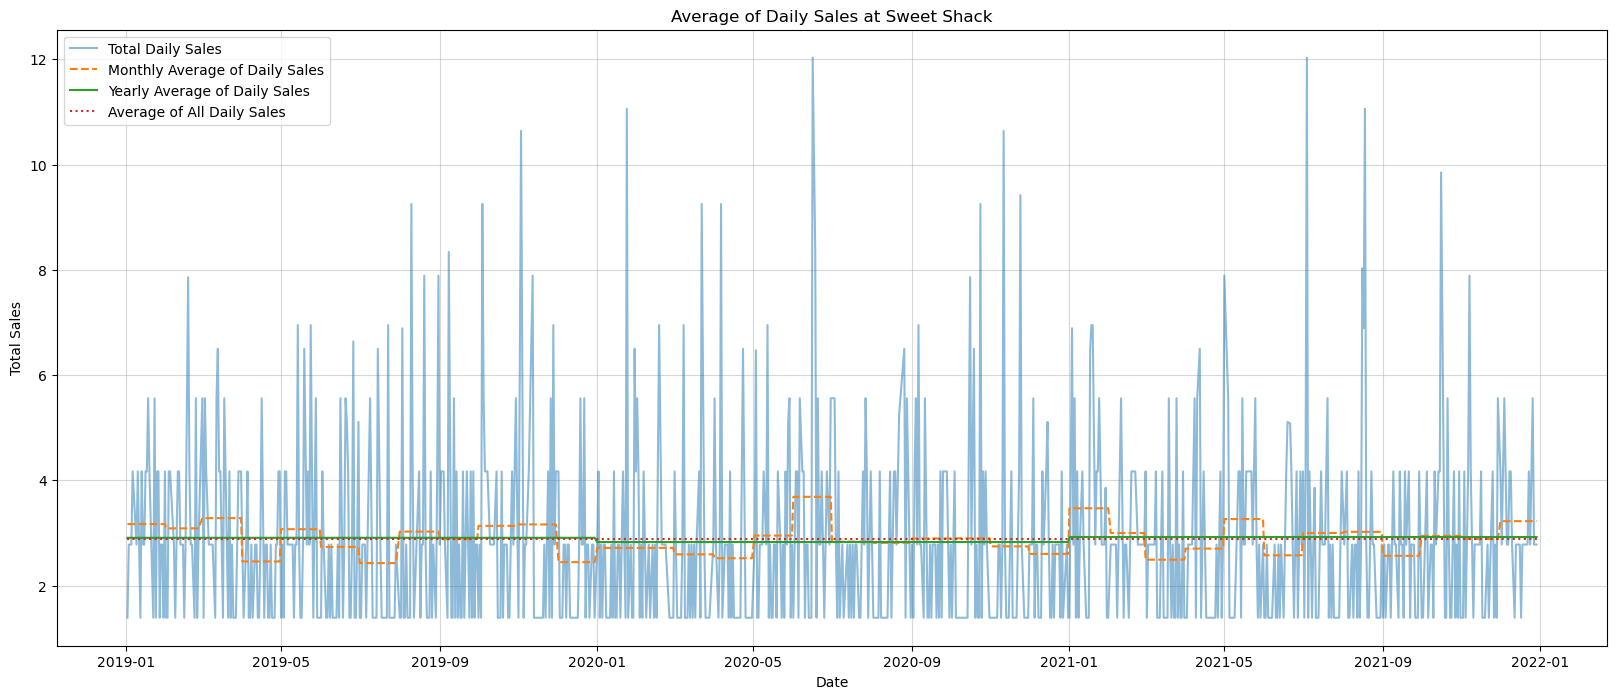

In [120]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Average of Daily Sales at Sweet Shack")

ax = sns.lineplot(data=sw_shack_daily, x="date", y="price", legend="auto", label="Total Daily Sales", alpha=0.5)
sns.lineplot(data=sw_shack_daily, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=sw_shack_daily, x="date", y="yearly_avg_sales", label="Yearly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=sw_shack_daily, x="date", y=sw_shack_daily["price"].mean(), label="Average of All Daily Sales", linestyle="dotted")
ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

### Restaurant Total Sales Comparison

In [121]:
sorted(df["store_name"].unique())

['Beachfront Bar',
 "Bob's Diner",
 'Corner Cafe',
 'Fou Cher',
 'Surfs Up',
 'Sweet Shack']

#### Bob's Diner has been excluded in this section as including the restaurant causes the rest of the data to become extremely small in comparison and almost imposssible to discern.

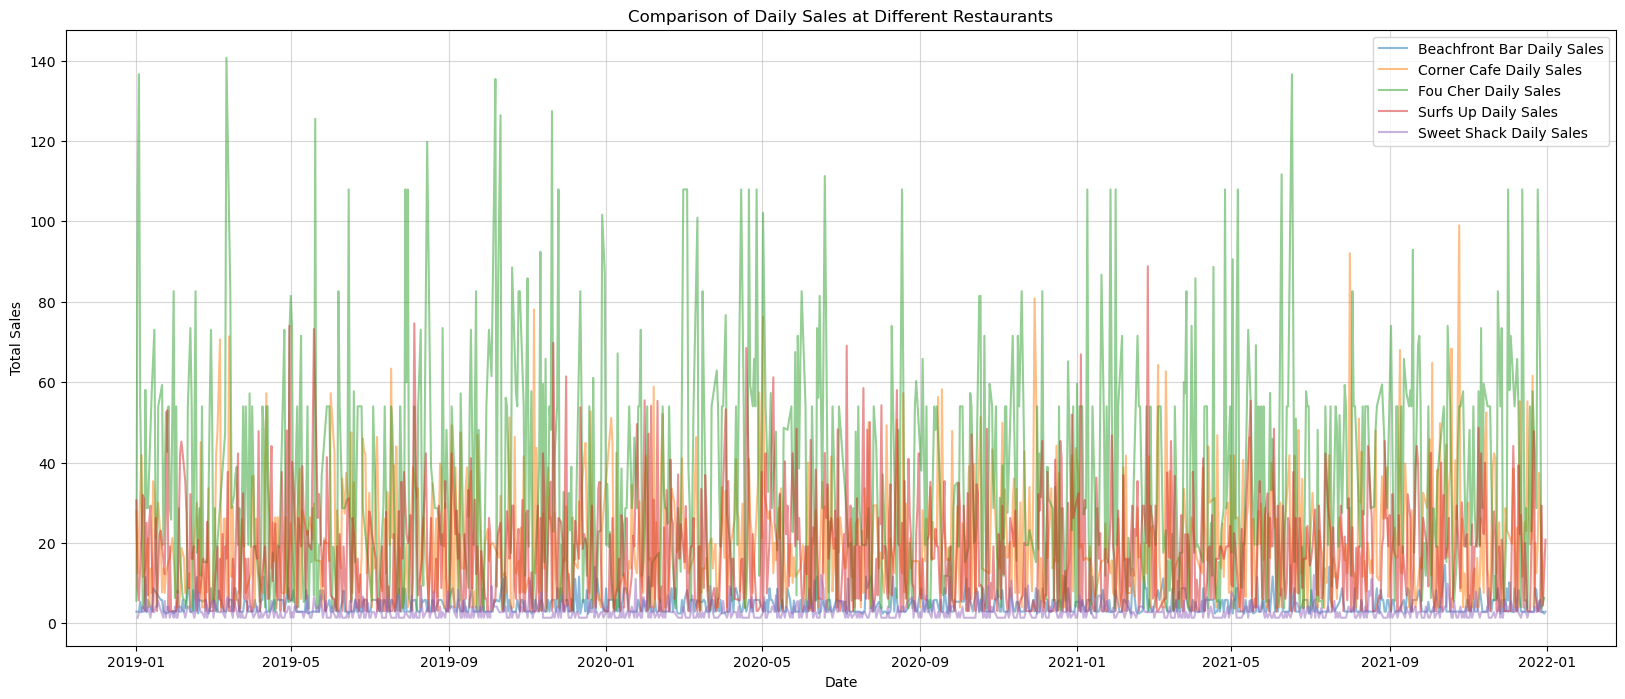

In [122]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Comparison of Daily Sales at Different Restaurants")

ax = sns.lineplot(data=beach_daily, x="date", y="price", legend="auto", label="Beachfront Bar Daily Sales", alpha=0.5)
# sns.lineplot(data=bob_daily, x="date", y="price", legend="auto", label="Bob's Diner Daily Sales", alpha=0.5)
sns.lineplot(data=corner_daily, x="date", y="price", legend="auto", label="Corner Cafe Daily Sales", alpha=0.5)
sns.lineplot(data=fou_daily, x="date", y="price", legend="auto", label="Fou Cher Daily Sales", alpha=0.5)
sns.lineplot(data=surf_daily, x="date", y="price", legend="auto", label="Surfs Up Daily Sales", alpha=0.5)
sns.lineplot(data=sw_shack_daily, x="date", y="price", legend="auto", label="Sweet Shack Daily Sales", alpha=0.5)

ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

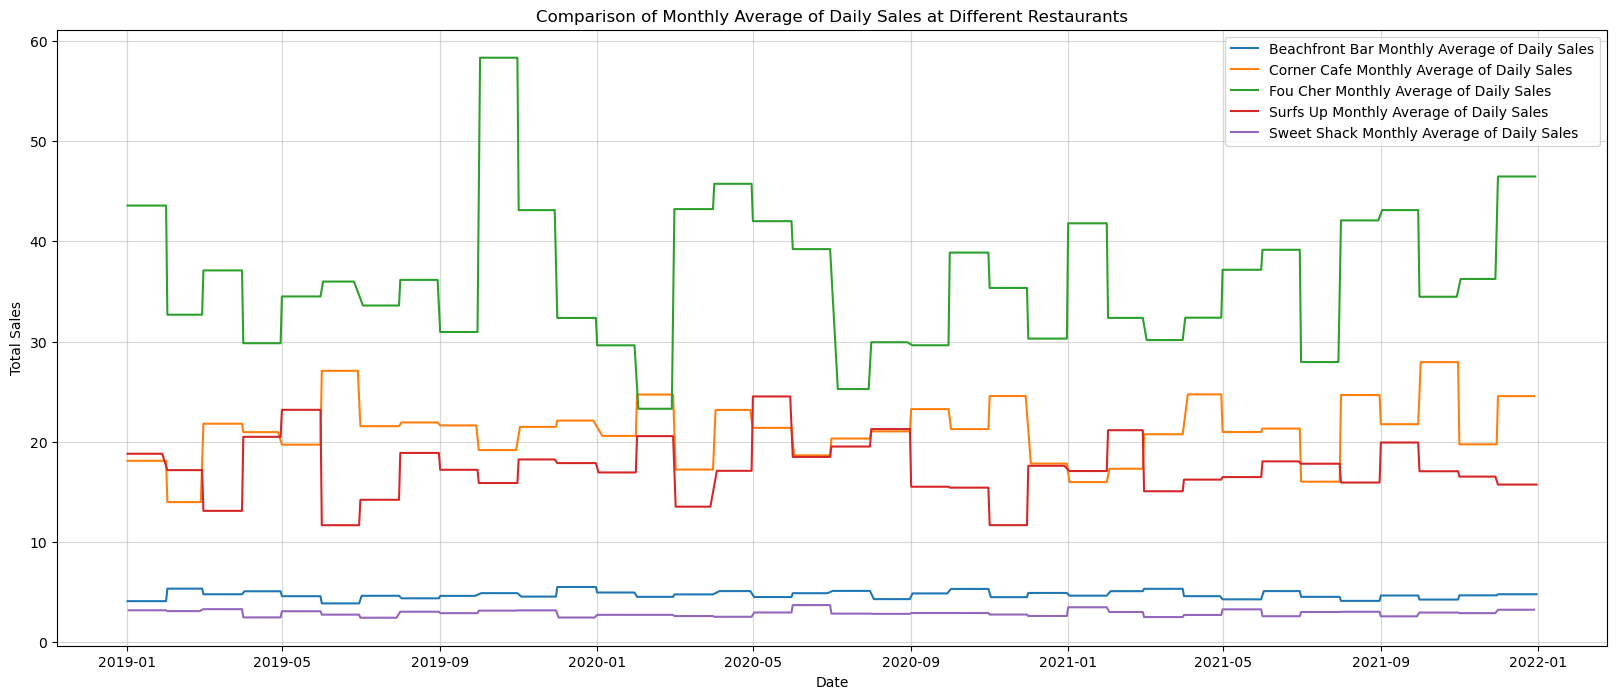

In [123]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Comparison of Monthly Average of Daily Sales at Different Restaurants")

ax = sns.lineplot(data=beach_daily, x="date", y="monthly_avg_sales", legend="auto", label="Beachfront Bar Monthly Average of Daily Sales")
sns.lineplot(data=corner_daily, x="date", y="monthly_avg_sales", legend="auto", label="Corner Cafe Monthly Average of Daily Sales")
sns.lineplot(data=fou_daily, x="date", y="monthly_avg_sales", legend="auto", label="Fou Cher Monthly Average of Daily Sales")
sns.lineplot(data=surf_daily, x="date", y="monthly_avg_sales", legend="auto", label="Surfs Up Monthly Average of Daily Sales")
sns.lineplot(data=sw_shack_daily, x="date", y="monthly_avg_sales", legend="auto", label="Sweet Shack Monthly Average of Daily Sales")

ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

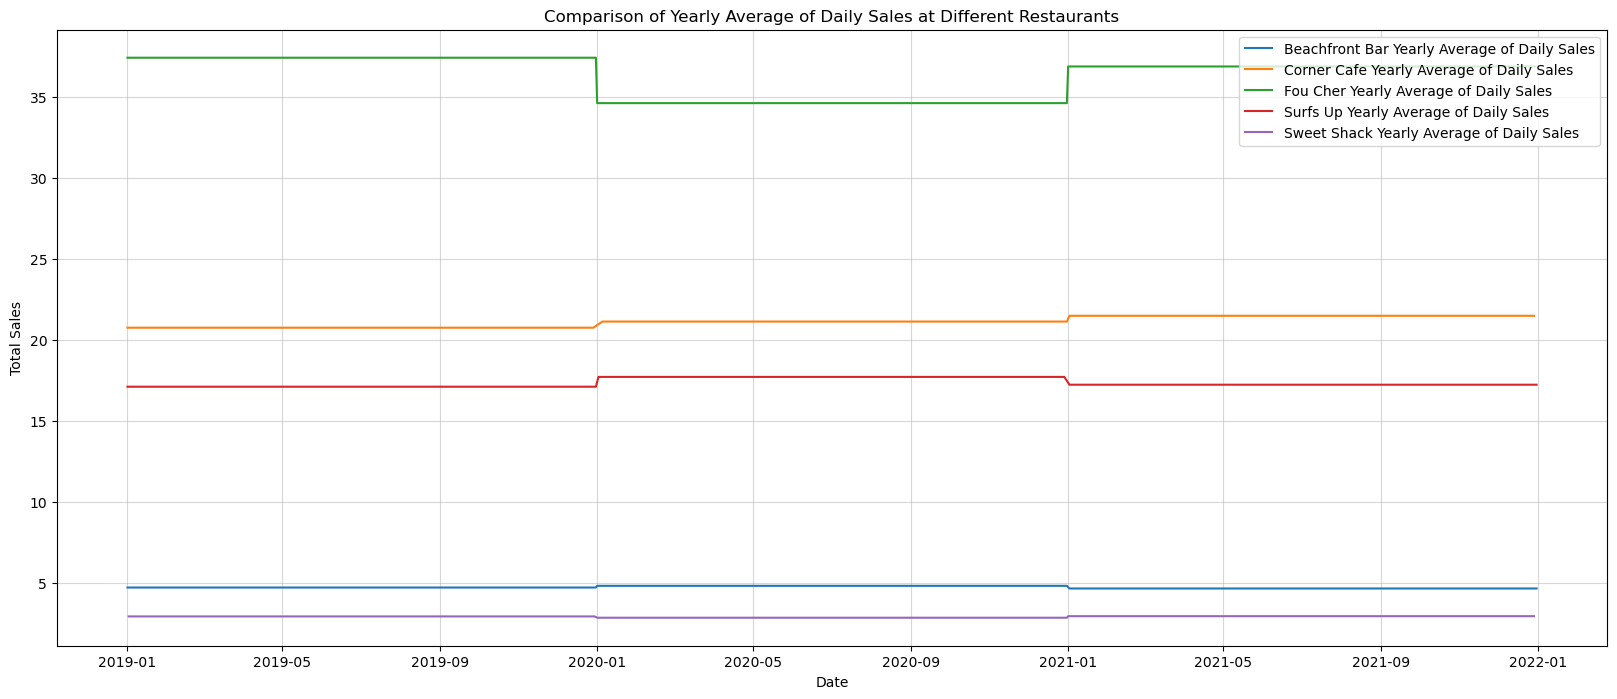

In [124]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Comparison of Yearly Average of Daily Sales at Different Restaurants")

ax = sns.lineplot(data=beach_daily, x="date", y="yearly_avg_sales", legend="auto", label="Beachfront Bar Yearly Average of Daily Sales")
sns.lineplot(data=corner_daily, x="date", y="yearly_avg_sales", legend="auto", label="Corner Cafe Yearly Average of Daily Sales")
sns.lineplot(data=fou_daily, x="date", y="yearly_avg_sales", legend="auto", label="Fou Cher Yearly Average of Daily Sales")
sns.lineplot(data=surf_daily, x="date", y="yearly_avg_sales", legend="auto", label="Surfs Up Yearly Average of Daily Sales")
sns.lineplot(data=sw_shack_daily, x="date", y="yearly_avg_sales", legend="auto", label="Sweet Shack Yearly Average of Daily Sales")

ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

# plt.savefig("Bob's_Diner_Sales.png", dpi=600, facecolor="white")

plt.show()

In [125]:
res_day_sales = df.groupby(["day_of_week",  "store_name"], observed=False).agg({"price":"sum"}).reset_index()
res_day_sales = res_day_sales[res_day_sales["store_name"] != "Bob's Diner"]
res_day_sales

,day_of_week,store_name,price
0,Monday,Beachfront Bar,544.78
2,Monday,Corner Cafe,2395.01
3,Monday,Fou Cher,3927.47
4,Monday,Surfs Up,2402.87
5,Monday,Sweet Shack,363.86
6,Tuesday,Beachfront Bar,548.72
8,Tuesday,Corner Cafe,2487.38
9,Tuesday,Fou Cher,3742.68
10,Tuesday,Surfs Up,1970.81
11,Tuesday,Sweet Shack,405.07


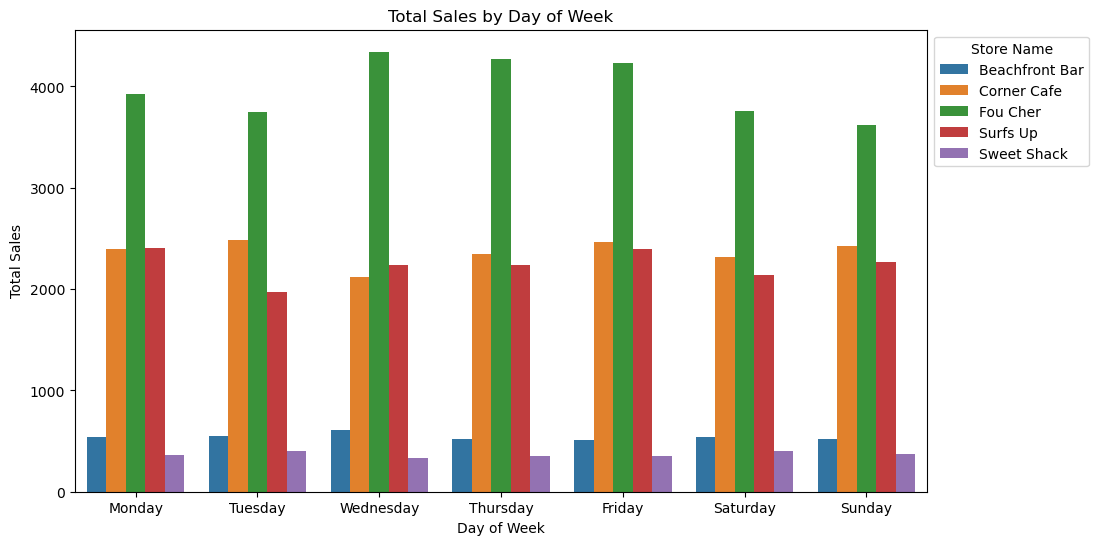

In [126]:
plt.subplots(figsize = (11, 6))

plt.title("Total Sales by Day of Week")
ax = sns.barplot(res_day_sales, x="day_of_week", y="price", hue="store_name", legend="auto")

# legend_handles, _= ax.get_legend_handles_labels()
# ax.legend(legend_handles, ['Fill your labels here'])

ax.set(xlabel="Day of Week", ylabel="Total Sales")
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), title="Store Name")
plt.show()

In [127]:
res_month_sales = df.groupby(["month",  "store_name"], observed=False).agg({"price":"sum"}).reset_index()
res_month_sales = res_month_sales[res_month_sales["store_name"] != "Bob's Diner"]
res_month_sales

,month,store_name,price
0,January,Beachfront Bar,315.55
2,January,Corner Cafe,1055.98
3,January,Fou Cher,2843.70
4,January,Surfs Up,1210.82
5,January,Sweet Shack,254.40
6,February,Beachfront Bar,318.10
8,February,Corner Cafe,1241.46
9,February,Fou Cher,1697.06
10,February,Surfs Up,1537.97
11,February,Sweet Shack,181.61


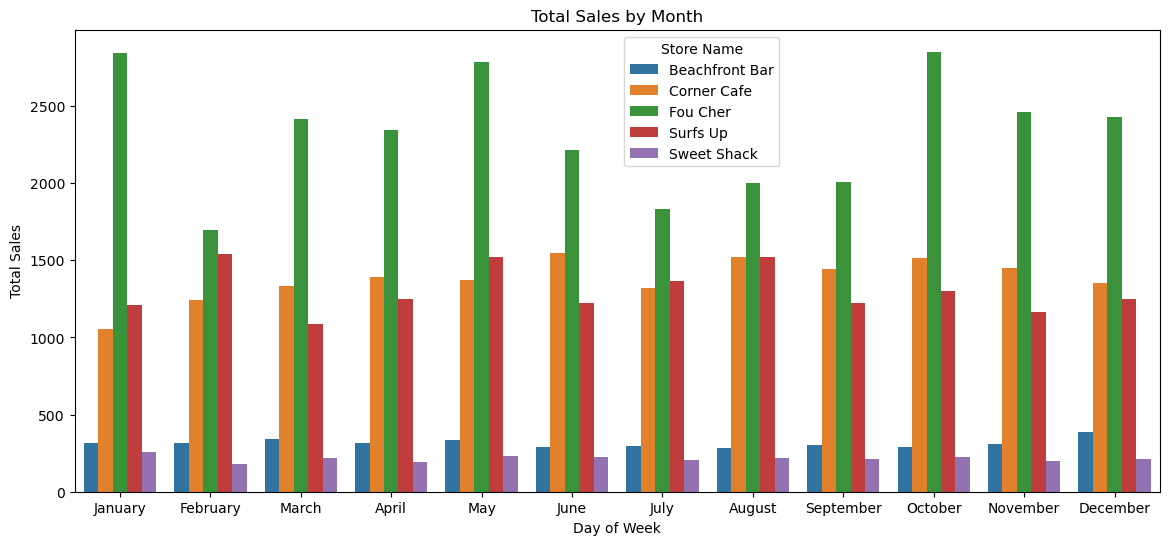

In [128]:
plt.subplots(figsize = (14, 6))

plt.title("Total Sales by Month")
ax = sns.barplot(res_month_sales, x="month", y="price", hue="store_name", legend="auto")

# legend_handles, _= ax.get_legend_handles_labels()
# ax.legend(legend_handles, ['Fill your labels here'])

ax.set(xlabel="Day of Week", ylabel="Total Sales")
ax.legend(bbox_to_anchor=(0.5, 1), title="Store Name")
plt.show()

In [129]:
res_year_sales = df.groupby(["year",  "store_name"], observed=False).agg({"price":"sum"}).reset_index()
res_year_sales = res_year_sales[res_year_sales["store_name"] != "Bob's Diner"]
res_year_sales

,year,store_name,price
0,2019,Beachfront Bar,1281.85
2,2019,Corner Cafe,5292.93
3,2019,Fou Cher,9698.80
4,2019,Surfs Up,5132.65
5,2019,Sweet Shack,872.59
6,2020,Beachfront Bar,1267.21
8,2020,Corner Cafe,5347.71
9,2020,Fou Cher,8590.87
10,2020,Surfs Up,5314.43
11,2020,Sweet Shack,828.65


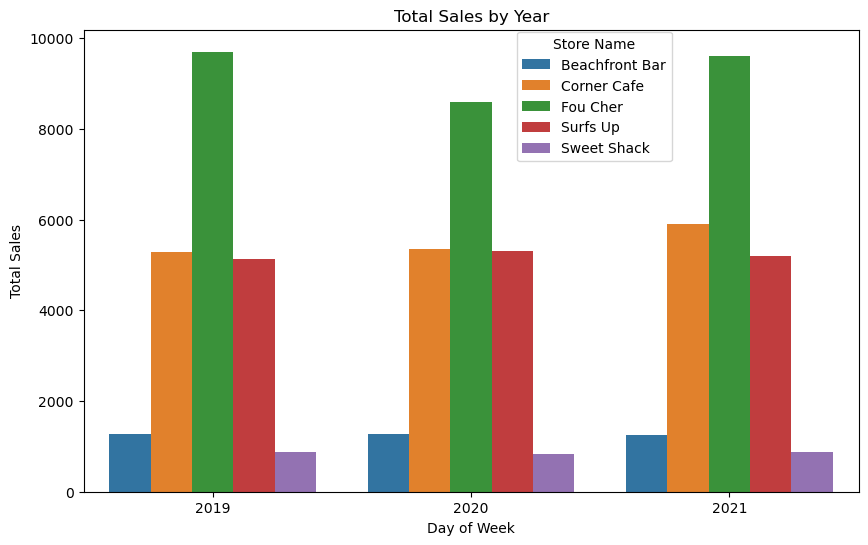

In [130]:
plt.subplots(figsize = (10, 6))

plt.title("Total Sales by Year")
ax = sns.barplot(res_year_sales, x="year", y="price", hue="store_name", legend="auto")

# legend_handles, _= ax.get_legend_handles_labels()
# ax.legend(legend_handles, ['Fill your labels here'])

ax.set(xlabel="Day of Week", ylabel="Total Sales")
ax.legend(bbox_to_anchor=(0.55, 0.7), title="Store Name")
plt.show()

#### Due to the high volume of data from Bob's Diner, the overall data matches the patterns of Bob's Diner, even though other restaurants show different patterns.

### Item-related Comparisons

In [131]:
item_sales = df.groupby(["item_name",  "store_name"], observed=False).agg({"item_count":"sum", "price":"sum"}).reset_index()
item_sales

,item_name,store_name,item_count,price
0,Amazing Cocktail,Surfs Up,91,354.90
1,Amazing Fish with Vegetables Meal,Bob's Diner,13190,306403.70
2,Amazing Frozen Milky Cake,Bob's Diner,211,1185.82
3,Amazing Lamb Dinner,Fou Cher,52,912.60
4,Amazing Steak Dinner with Rolls,Bob's Diner,34439,909878.38
...,...,...,...,...
87,Sweet Fruity Cake,Bob's Diner,2946,86082.12
88,Sweet Lamb Cake,Bob's Diner,18764,131348.00
89,Sweet Savory Cake,Fou Cher,25,686.75
90,Sweet Vegi Soft Drink,Beachfront Bar,19,108.30


In [132]:
# The top 10 most ordered items.
item_sales.sort_values(by="item_count", ascending=False).head(10)

,item_name,store_name,item_count,price
83,Strawberry Smoothy,Bob's Diner,236337,683013.93
44,Frozen Milky Smoothy,Bob's Diner,102990,330597.90
9,Amazing pork lunch,Bob's Diner,61043,1094500.99
64,Mutton Dinner,Bob's Diner,52772,569937.60
67,Orange Juice,Bob's Diner,43874,171547.34
21,Blue Ribbon Beef Entree,Bob's Diner,42774,999628.38
4,Amazing Steak Dinner with Rolls,Bob's Diner,34439,909878.38
86,Sweet Frozen Soft Drink,Bob's Diner,27490,114908.20
81,Sea Bass with Vegetables Dinner,Bob's Diner,23839,685371.25
88,Sweet Lamb Cake,Bob's Diner,18764,131348.00


In [133]:
item_sales.loc[item_sales['item_count'].idxmax()]

item_name     Strawberry Smoothy
store_name           Bob's Diner
item_count                236337
price                  683013.93
Name: 83, dtype: object

- The item with highest sales is ***Strawberry Smoothy*** from ***Bob's Diner***.

##### The best selling items of different restaurants

In [134]:
sorted(item_sales['store_name'].unique())

['Beachfront Bar',
 "Bob's Diner",
 'Corner Cafe',
 'Fou Cher',
 'Surfs Up',
 'Sweet Shack']

In [135]:
item_sales[item_sales['store_name'] == "Beachfront Bar"].loc[item_sales[item_sales['store_name'] == "Beachfront Bar"]['item_count'].idxmax()]

item_name     Fantastic Milky Smoothy
store_name             Beachfront Bar
item_count                       1147
price                         3337.77
Name: 37, dtype: object

In [136]:
item_sales[item_sales['store_name'] == "Corner Cafe"].loc[item_sales[item_sales['store_name'] == "Corner Cafe"]['item_count'].idxmax()]

item_name     Frozen Milky Smoothy
store_name             Corner Cafe
item_count                     273
price                      1086.54
Name: 45, dtype: object

In [137]:
item_sales[item_sales['store_name'] == "Fou Cher"].loc[item_sales[item_sales['store_name'] == "Fou Cher"]['item_count'].idxmax()]

item_name     Blue Ribbon Fruity Vegi Lunch
store_name                         Fou Cher
item_count                              298
price                              16086.04
Name: 25, dtype: object

In [138]:
item_sales[item_sales['store_name'] == "Surfs Up"].loc[item_sales[item_sales['store_name'] == "Surfs Up"]['item_count'].idxmax()]

item_name     Awesome Soft Drink
store_name              Surfs Up
item_count                   997
price                    3050.82
Name: 16, dtype: object

In [139]:
item_sales[item_sales['store_name'] == "Sweet Shack"].loc[item_sales[item_sales['store_name'] == "Sweet Shack"]['item_count'].idxmax()]

item_name     Awesome Smoothy
store_name        Sweet Shack
item_count               1692
price                 2351.88
Name: 15, dtype: object

In [140]:
# Verifying that the highest sales and item count match and belong to the same store.
item_sales.groupby("store_name").agg({"price":"sum", "item_count":"sum"})

,price,item_count
store_name,,
Beachfront Bar,3796.20,1305
Bob's Diner,6337275.69,687527
Corner Cafe,16551.43,1310
Fou Cher,27885.37,1106
Surfs Up,15651.49,1803
Sweet Shack,2578.27,1736


In [141]:
item_price = df.groupby(["store_id","store_name","item_id","item_name"]).agg({"price":"sum", "item_count":"sum", "kcal":"mean"}).reset_index()
item_price["cost"] = item_price["price"]/item_price["item_count"]
item_price

,store_id,store_name,item_id,item_name,price,item_count,kcal,cost
0,1,Bob's Diner,3,Sweet Fruity Cake,86082.12,2946,931.0,29.22
1,1,Bob's Diner,4,Amazing Steak Dinner with Rolls,909878.38,34439,763.0,26.42
2,1,Bob's Diner,9,Orange Juice,171547.34,43874,135.0,3.91
3,1,Bob's Diner,12,Fantastic Sweet Cola,37942.17,7791,478.0,4.87
4,1,Bob's Diner,13,Sweet Frozen Soft Drink,114908.20,27490,490.0,4.18
...,...,...,...,...,...,...,...,...
87,6,Surfs Up,61,Awesome Pork with Vegetables Lunch,1167.39,63,848.0,18.53
88,6,Surfs Up,64,Roast Mutton Entree,2654.85,165,293.0,16.09
89,6,Surfs Up,88,Oysters Rockefeller,2521.42,157,204.0,16.06
90,6,Surfs Up,89,Awesome Soft Drink,3050.82,997,248.0,3.06


In [142]:
for i in sorted(item_price["store_name"].unique()):
    idx = item_price[item_price["store_name"] == i]["cost"].idxmax()
    print(f"The most expensive item at {i} is the {item_price.loc[idx, 'item_name']} and has {item_price.loc[idx, 'kcal']} calories.")

The most expensive item at Beachfront Bar is the Sweet Vegi Soft Drink and has 538.0 calories.
The most expensive item at Bob's Diner is the Sweet Fruity Cake and has 931.0 calories.
The most expensive item at Corner Cafe is the Pike Lunch and has 653.0 calories.
The most expensive item at Fou Cher is the Blue Ribbon Fruity Vegi Lunch and has 881.0 calories.
The most expensive item at Surfs Up is the Steak Meal and has 607.0 calories.
The most expensive item at Sweet Shack is the Blue Ribbon Milky Cake and has 612.0 calories.


In [143]:
# Pivot Table of sales of different restaurants by day of week.
final_df.pivot_table(values="price", index="store_name", columns="day_of_week", aggfunc="sum", observed=False)

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
store_name,,,,,,,
Beachfront Bar,544.78,548.72,613.29,518.58,508.79,538.93,523.11
Bob's Diner,635165.98,725443.80,802967.98,1063813.76,1247393.16,1241421.51,621069.50
Corner Cafe,2395.01,2487.38,2121.01,2343.02,2460.83,2317.59,2426.59
Fou Cher,3927.47,3742.68,4342.13,4272.16,4227.35,3753.69,3619.89
Surfs Up,2402.87,1970.81,2232.88,2233.90,2399.53,2142.37,2269.13
Sweet Shack,363.86,405.07,336.02,353.10,348.50,400.23,371.49


In [144]:
# Pivot table of different items by day of week.
final_df.pivot_table(values="price", index="item_name", columns="day_of_week", aggfunc="sum", observed=False)

day_of_week,Monday,Tuesday,Wednesday,Thursday,Friday,Saturday,Sunday
item_name,,,,,,,
Amazing Cocktail,58.50,78.00,42.90,39.00,42.90,42.90,50.70
Amazing Fish with Vegetables Meal,30756.52,34589.47,38422.42,51013.08,60374.77,59886.94,31360.50
Amazing Frozen Milky Cake,73.06,151.74,129.26,196.70,297.86,207.94,129.26
Amazing Lamb Dinner,157.95,105.30,193.05,122.85,157.95,87.75,87.75
Amazing Steak Dinner with Rolls,92390.74,104676.04,115270.46,151413.02,178731.30,177383.88,90012.94
...,...,...,...,...,...,...,...
Sweet Fruity Cake,9438.06,9730.26,10752.96,14697.66,17093.70,16421.64,7947.84
Sweet Lamb Cake,13041.00,15197.00,16996.00,21476.00,26012.00,25802.00,12824.00
Sweet Savory Cake,164.82,54.94,109.88,82.41,27.47,54.94,192.29


In [145]:
# All items sold by Bob's Diner sorted by highest to lowest sales.
final_df[final_df['store_name'] == "Bob's Diner"].groupby("item_name").agg({"item_count":"sum"}).sort_values(by="item_count", ascending=False)

,item_count
item_name,
Strawberry Smoothy,236337
Frozen Milky Smoothy,102990
Amazing pork lunch,61043
Mutton Dinner,52772
Orange Juice,43874
Blue Ribbon Beef Entree,42774
Amazing Steak Dinner with Rolls,34439
Sweet Frozen Soft Drink,27490
Sea Bass with Vegetables Dinner,23839


In [146]:
df[df["item_name"].duplicated(keep=False)].sort_values(by="store_name")

,date,item_id,price,item_count,item_name,kcal,store_id,store_name,week,month,year,year_month,quarter,day_of_week
96910,2021-08-27,42,5.82,2,Fantastic Milky Smoothy,318,2,Beachfront Bar,2021-08-23/2021-08-29,August,2021,2021-08,2021Q3,Friday
91812,2021-07-07,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2021-07-05/2021-07-11,July,2021,2021-07,2021Q3,Wednesday
55709,2020-07-11,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2020-07-06/2020-07-12,July,2020,2020-07,2020Q3,Saturday
50011,2020-05-15,42,2.91,1,Fantastic Milky Smoothy,318,2,Beachfront Bar,2020-05-11/2020-05-17,May,2020,2020-05,2020Q2,Friday
19210,2019-07-12,42,5.82,2,Fantastic Milky Smoothy,318,2,Beachfront Bar,2019-07-08/2019-07-14,July,2019,2019-07,2019Q3,Friday
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
67812,2020-11-09,49,1.39,1,Awesome Smoothy,78,3,Sweet Shack,2020-11-09/2020-11-15,November,2020,2020-11,2020Q4,Monday
55613,2020-07-10,49,1.39,1,Awesome Smoothy,78,3,Sweet Shack,2020-07-06/2020-07-12,July,2020,2020-07,2020Q3,Friday
21611,2019-08-05,49,1.39,1,Awesome Smoothy,78,3,Sweet Shack,2019-08-05/2019-08-11,August,2019,2019-08,2019Q3,Monday
11511,2019-04-26,49,1.39,1,Awesome Smoothy,78,3,Sweet Shack,2019-04-22/2019-04-28,April,2019,2019-04,2019Q2,Friday


In [147]:
# Pivot table to daily sales of different restaurants
daywise_store_pivot = final_df.pivot_table(values="price", index="date", columns="store_name",
                                           aggfunc="sum", observed=True)
daywise_store_pivot

store_name,Beachfront Bar,Bob's Diner,Corner Cafe,Fou Cher,Surfs Up,Sweet Shack
date,,,,,,
2019-01-01,2.91,3956.02,27.90,5.60,30.57,0.00
2019-01-02,2.91,2941.22,12.44,107.96,8.77,1.39
2019-01-03,2.91,3914.70,0.00,136.61,5.71,2.78
2019-01-04,5.34,4944.71,0.00,53.98,0.00,2.78
2019-01-05,2.91,4845.76,41.83,34.25,0.00,2.78
...,...,...,...,...,...,...
2021-12-27,5.82,1793.41,0.00,59.58,6.12,2.78
2021-12-28,2.91,3390.57,0.00,3.75,29.27,0.00
2021-12-29,2.91,3698.71,6.63,0.00,4.36,2.78


In [148]:
# Average Daily Sales per Restaurant ignoring the days with no sales.
daywise_store_pivot.mask(daywise_store_pivot == 0).mean()

store_name
Beachfront Bar       4.709926
Bob's Diner       5782.185849
Corner Cafe         21.138480
Fou Cher            36.356415
Surfs Up            17.351984
Sweet Shack          2.887200
dtype: float64

## Model Training

### Data Preparation

As the problem statement does not mention what the target is, I have decided to go with 'Daily Sales' as the target.

In [149]:
prep_table = final_df.groupby(by=["date"], sort=False).agg({"price": "sum"}).reset_index()
prep_table

,date,price
0,2019-01-01,4023.00
1,2019-01-02,3074.69
2,2019-01-03,4062.71
3,2019-01-04,5006.81
4,2019-01-05,4927.53
...,...,...
1091,2021-12-27,1867.71
1092,2021-12-28,3426.50
1093,2021-12-29,3715.39
1094,2021-12-30,5266.27


In [150]:
prep_table['date'] = pd.to_datetime(prep_table['date'], dayfirst=True)
prep_table['day'] = prep_table['date'].dt.day
prep_table['day_of_week'] = prep_table['date'].dt.dayofweek
prep_table['week'] = prep_table['date'].dt.isocalendar().week
prep_table['month'] = prep_table['date'].dt.month
prep_table['quarter'] = prep_table['date'].dt.quarter
prep_table['year'] = prep_table['date'].dt.year
prep_table

,date,price,day,day_of_week,week,month,quarter,year
0,2019-01-01,4023.00,1,1,1,1,1,2019
1,2019-01-02,3074.69,2,2,1,1,1,2019
2,2019-01-03,4062.71,3,3,1,1,1,2019
3,2019-01-04,5006.81,4,4,1,1,1,2019
4,2019-01-05,4927.53,5,5,1,1,1,2019
...,...,...,...,...,...,...,...,...
1091,2021-12-27,1867.71,27,0,52,12,4,2021
1092,2021-12-28,3426.50,28,1,52,12,4,2021
1093,2021-12-29,3715.39,29,2,52,12,4,2021
1094,2021-12-30,5266.27,30,3,52,12,4,2021


In [151]:
# Splitting train and test data based on requirements mentioned in the problem statement.
train_set = prep_table[prep_table["date"] < "2021-07-01"]
test_set = prep_table[prep_table["date"] >= "2021-07-01"]

In [152]:
X_train = train_set.drop(["date", "price"], axis=1)
X_train

,day,day_of_week,week,month,quarter,year
0,1,1,1,1,1,2019
1,2,2,1,1,1,2019
2,3,3,1,1,1,2019
3,4,4,1,1,1,2019
4,5,5,1,1,1,2019
...,...,...,...,...,...,...
907,26,5,25,6,2,2021
908,27,6,25,6,2,2021
909,28,0,26,6,2,2021
910,29,1,26,6,2,2021


In [153]:
y_train = train_set.loc[:,"price"]
y_train

0       4023.00
1       3074.69
2       4062.71
3       5006.81
4       4927.53
         ...   
907    11026.93
908     6640.55
909     6978.39
910     7697.64
911     8198.43
Name: price, Length: 912, dtype: float64

In [154]:
X_test = test_set.drop(["date", "price"], axis=1)
X_test

,day,day_of_week,week,month,quarter,year
912,1,3,26,7,3,2021
913,2,4,26,7,3,2021
914,3,5,26,7,3,2021
915,4,6,26,7,3,2021
916,5,0,27,7,3,2021
...,...,...,...,...,...,...
1091,27,0,52,12,4,2021
1092,28,1,52,12,4,2021
1093,29,2,52,12,4,2021
1094,30,3,52,12,4,2021


In [155]:
y_test = test_set.loc[:,"price"]
y_test

912     10290.33
913     11028.59
914     10793.51
915      6524.13
916      7983.57
          ...   
1091     1867.71
1092     3426.50
1093     3715.39
1094     5266.27
1095     8287.81
Name: price, Length: 184, dtype: float64

In [156]:
linear_reg = LinearRegression(n_jobs=-1)
rf_reg = RandomForestRegressor(n_estimators=1000, n_jobs=-1)
xgb_reg = XGBRegressor()

scaler = MinMaxScaler()

In [157]:
X_train_sc = scaler.fit_transform(X_train)
X_test_sc = scaler.transform(X_test)

In [158]:
linear_reg.fit(X_train_sc, y_train)

LinearRegression(n_jobs=-1)

In [159]:
pred = linear_reg.predict(X_test_sc)
print(f"RMSE: {root_mean_squared_error(y_test, pred):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, pred):.4f}")

RMSE: 2390.9606
MAPE: 0.4178


In [160]:
rf_reg.fit(X_train_sc, y_train)

RandomForestRegressor(n_estimators=1000, n_jobs=-1)

In [161]:
pred2 = rf_reg.predict(X_test_sc)
print(f"RMSE: {root_mean_squared_error(y_test, pred2):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, pred2):.4f}")

RMSE: 829.9545
MAPE: 0.1121


In [162]:
xgb_reg.fit(X_train_sc, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=None, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=None,
             n_jobs=None, num_parallel_tree=None, ...)

In [163]:
pred3 = xgb_reg.predict(X_test_sc)
print(f"RMSE: {root_mean_squared_error(y_test, pred3):.4f}")
print(f"MAPE: {mean_absolute_percentage_error(y_test, pred3):.4f}")

RMSE: 735.0540
MAPE: 0.1060


#### Based on RMSE and MAPE score, the best model for forecasting is the XGBoost Regression model.

In [164]:
X_forecast = pd.DataFrame(pd.date_range(start="2022-01-01", end="2022-12-31"), columns=["date"])
X_forecast

,date
0,2022-01-01
1,2022-01-02
2,2022-01-03
3,2022-01-04
4,2022-01-05
...,...
360,2022-12-27
361,2022-12-28
362,2022-12-29
363,2022-12-30


In [165]:
# X_forecast['date'] = pd.to_datetime(X_forecast['date'], dayfirst=True)
X_forecast['day'] = X_forecast['date'].dt.day
X_forecast['day_of_week'] = X_forecast['date'].dt.dayofweek
X_forecast['week'] = X_forecast['date'].dt.isocalendar().week
X_forecast['month'] = X_forecast['date'].dt.month
X_forecast['quarter'] = X_forecast['date'].dt.quarter
X_forecast['year'] = X_forecast['date'].dt.year
X_forecast.drop(["date"], axis=1, inplace=True)
X_forecast

,day,day_of_week,week,month,quarter,year
0,1,5,52,1,1,2022
1,2,6,52,1,1,2022
2,3,0,1,1,1,2022
3,4,1,1,1,1,2022
4,5,2,1,1,1,2022
...,...,...,...,...,...,...
360,27,1,52,12,4,2022
361,28,2,52,12,4,2022
362,29,3,52,12,4,2022
363,30,4,52,12,4,2022


In [166]:
X_forecast_sc = scaler.transform(X_forecast)

In [167]:
f_pred = xgb_reg.predict(X_forecast_sc)
f_pred

array([ 7383.8306,  2252.7449,  2637.2522,  3255.2642,  3374.407 ,
        5167.5415,  6509.964 ,  6410.4697,  2706.1147,  2096.608 ,
        3367.3538,  3495.2302,  5488.4487,  7073.5166,  7265.0386,
        2816.1978,  4754.277 ,  3572.3726,  3725.816 ,  5931.0566,
        7254.138 ,  7019.55  ,  2374.6284,  2715.1223,  3618.9062,
        3727.5447,  5767.032 ,  7244.9478,  7112.3193,  2411.728 ,
        2572.4653,  4325.0493,  4300.229 ,  5546.2197,  6714.24  ,
        6944.1167,  2609.601 ,  2588.199 ,  3617.7703,  3978.1206,
        5747.6772,  7111.479 ,  7399.528 ,  3384.7583,  4081.7437,
        4493.06  ,  4290.024 ,  6102.7075,  7853.806 ,  8043.915 ,
        3348.277 ,  4324.733 ,  4386.5347,  4808.3784,  6336.4478,
        7936.6177,  8176.071 ,  3394.7905,  3999.7507,  4546.918 ,
        4995.9956,  6870.4824,  8226.587 ,  8292.293 ,  4038.2852,
        4236.194 ,  4612.0234,  5099.2734,  6968.4883,  8485.359 ,
        8704.653 ,  4121.212 ,  3898.2632,  4770.3325,  5565.0

In [168]:
forecast_table = pd.DataFrame(pd.date_range(start="2022-01-01", end="2022-12-31"), columns=["date"])
forecast_table["price"] = f_pred
forecast_table

,date,price
0,2022-01-01,7383.830566
1,2022-01-02,2252.744873
2,2022-01-03,2637.252197
3,2022-01-04,3255.264160
4,2022-01-05,3374.406982
...,...,...
360,2022-12-27,2800.512695
361,2022-12-28,3546.214111
362,2022-12-29,6418.290039
363,2022-12-30,7501.478516


In [169]:
forecast_table['week'] = forecast_table["date"].dt.to_period("W")
forecast_table['year'] = forecast_table['date'].dt.year
forecast_table['year_month'] = forecast_table["date"].dt.to_period("M")
forecast_table['quarter'] = pd.PeriodIndex(forecast_table['date'], freq='Q')

forecast_table

,date,price,week,year,year_month,quarter
0,2022-01-01,7383.830566,2021-12-27/2022-01-02,2022,2022-01,2022Q1
1,2022-01-02,2252.744873,2021-12-27/2022-01-02,2022,2022-01,2022Q1
2,2022-01-03,2637.252197,2022-01-03/2022-01-09,2022,2022-01,2022Q1
3,2022-01-04,3255.264160,2022-01-03/2022-01-09,2022,2022-01,2022Q1
4,2022-01-05,3374.406982,2022-01-03/2022-01-09,2022,2022-01,2022Q1
...,...,...,...,...,...,...
360,2022-12-27,2800.512695,2022-12-26/2023-01-01,2022,2022-12,2022Q4
361,2022-12-28,3546.214111,2022-12-26/2023-01-01,2022,2022-12,2022Q4
362,2022-12-29,6418.290039,2022-12-26/2023-01-01,2022,2022-12,2022Q4
363,2022-12-30,7501.478516,2022-12-26/2023-01-01,2022,2022-12,2022Q4


In [170]:
weekly_avg_frcst = forecast_table.groupby("week", sort=False).agg({"price":"mean"}).reset_index()
weekly_avg_frcst

,week,price
0,2021-12-27/2022-01-02,4818.287598
1,2022-01-03/2022-01-09,4294.430664
2,2022-01-10/2022-01-16,4514.627930
3,2022-01-17/2022-01-23,4947.405762
4,2022-01-24/2022-01-30,4656.800293
5,2022-01-31/2022-02-06,4715.988770
6,2022-02-07/2022-02-13,4832.504395
7,2022-02-14/2022-02-20,5459.076660
8,2022-02-21/2022-02-27,5623.367676
9,2022-02-28/2022-03-06,5852.901855


In [171]:
monthly_avg_frcst = forecast_table.groupby("year_month", sort=False).agg({"price":"mean"}).reset_index()
monthly_avg_frcst

,year_month,price
0,2022-01,4551.673828
1,2022-02,5208.708496
2,2022-03,6107.298828
3,2022-04,7369.976562
4,2022-05,7885.636230
5,2022-06,8619.000977
6,2022-07,8450.377930
7,2022-08,8063.672363
8,2022-09,7538.294434
9,2022-10,6011.324707


In [172]:
qrtrly_avg_frcst = forecast_table.groupby("quarter", sort=False).agg({"price":"mean"}).reset_index()
qrtrly_avg_frcst

,quarter,price
0,2022Q1,5291.911133
1,2022Q2,7957.406738
2,2022Q3,8022.656250
3,2022Q4,5433.092285


In [173]:
week_frcst_dict = dict(zip(weekly_avg_frcst['week'], weekly_avg_frcst['price']))
month_frcst_dict = dict(zip(monthly_avg_frcst['year_month'], monthly_avg_frcst['price']))
qrtr_frcst_dict = dict(zip(qrtrly_avg_frcst['quarter'], qrtrly_avg_frcst['price']))

In [174]:
forecast_table['weekly_avg_sales'] = forecast_table['week'].map(week_frcst_dict)
forecast_table['monthly_avg_sales'] = forecast_table['year_month'].map(month_frcst_dict)
forecast_table['qrtrly_avg_sales'] = forecast_table['quarter'].map(qrtr_frcst_dict)
forecast_table

,date,price,week,year,year_month,quarter,weekly_avg_sales,monthly_avg_sales,qrtrly_avg_sales
0,2022-01-01,7383.830566,2021-12-27/2022-01-02,2022,2022-01,2022Q1,4818.287598,4551.673828,5291.911133
1,2022-01-02,2252.744873,2021-12-27/2022-01-02,2022,2022-01,2022Q1,4818.287598,4551.673828,5291.911133
2,2022-01-03,2637.252197,2022-01-03/2022-01-09,2022,2022-01,2022Q1,4294.430664,4551.673828,5291.911133
3,2022-01-04,3255.264160,2022-01-03/2022-01-09,2022,2022-01,2022Q1,4294.430664,4551.673828,5291.911133
4,2022-01-05,3374.406982,2022-01-03/2022-01-09,2022,2022-01,2022Q1,4294.430664,4551.673828,5291.911133
...,...,...,...,...,...,...,...,...,...
360,2022-12-27,2800.512695,2022-12-26/2023-01-01,2022,2022-12,2022Q4,4914.840332,5053.615234,5433.092285
361,2022-12-28,3546.214111,2022-12-26/2023-01-01,2022,2022-12,2022Q4,4914.840332,5053.615234,5433.092285
362,2022-12-29,6418.290039,2022-12-26/2023-01-01,2022,2022-12,2022Q4,4914.840332,5053.615234,5433.092285
363,2022-12-30,7501.478516,2022-12-26/2023-01-01,2022,2022-12,2022Q4,4914.840332,5053.615234,5433.092285


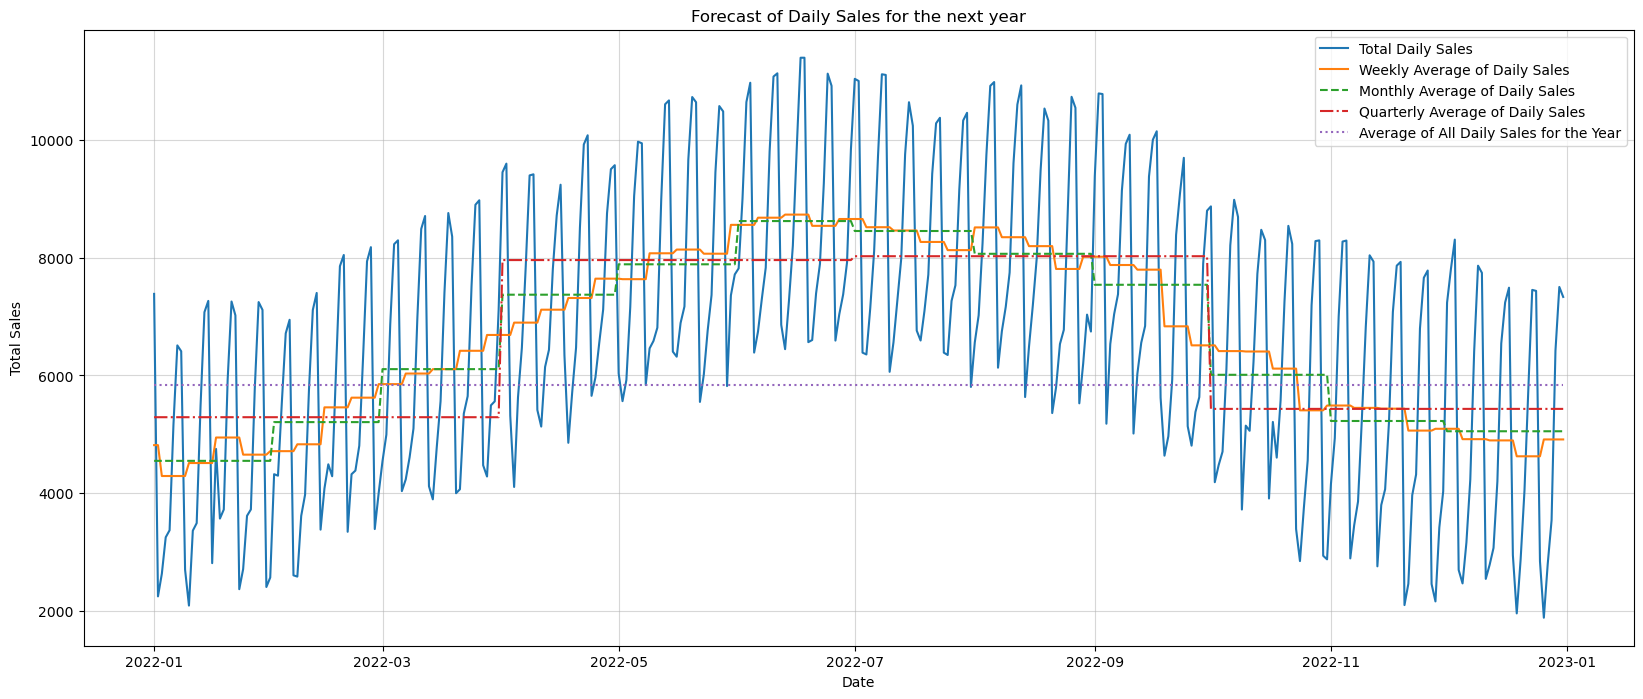

In [175]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Forecast of Daily Sales for the next year")

ax = sns.lineplot(data=forecast_table, x="date", y="price", legend="auto", label="Total Daily Sales")
sns.lineplot(data=forecast_table, x="date", y="weekly_avg_sales", label="Weekly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=forecast_table, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=forecast_table, x="date", y="qrtrly_avg_sales", label="Quarterly Average of Daily Sales", linestyle="dashdot")
sns.lineplot(data=forecast_table, x="date", y=daywise_sales["price"].mean(), label="Average of All Daily Sales for the Year", linestyle="dotted")
ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)

## Deep Learning Model Preparation

In [176]:
prep_table_d = final_df.groupby(by=["date"], sort=False).agg({"price": "sum"}).reset_index()
prep_table_d

,date,price
0,2019-01-01,4023.00
1,2019-01-02,3074.69
2,2019-01-03,4062.71
3,2019-01-04,5006.81
4,2019-01-05,4927.53
...,...,...
1091,2021-12-27,1867.71
1092,2021-12-28,3426.50
1093,2021-12-29,3715.39
1094,2021-12-30,5266.27


In [177]:
prep_table_d['date'] = pd.to_datetime(prep_table_d['date'], dayfirst=True)
prep_table_d['day'] = prep_table_d['date'].dt.day
prep_table_d['day_of_week'] = prep_table_d['date'].dt.dayofweek
prep_table_d['week'] = prep_table_d['date'].dt.isocalendar().week
prep_table_d['month'] = prep_table_d['date'].dt.month
prep_table_d['quarter'] = prep_table_d['date'].dt.quarter
prep_table_d['year'] = prep_table_d['date'].dt.year
prep_table_d

,date,price,day,day_of_week,week,month,quarter,year
0,2019-01-01,4023.00,1,1,1,1,1,2019
1,2019-01-02,3074.69,2,2,1,1,1,2019
2,2019-01-03,4062.71,3,3,1,1,1,2019
3,2019-01-04,5006.81,4,4,1,1,1,2019
4,2019-01-05,4927.53,5,5,1,1,1,2019
...,...,...,...,...,...,...,...,...
1091,2021-12-27,1867.71,27,0,52,12,4,2021
1092,2021-12-28,3426.50,28,1,52,12,4,2021
1093,2021-12-29,3715.39,29,2,52,12,4,2021
1094,2021-12-30,5266.27,30,3,52,12,4,2021


In [178]:
# Define cyclic encoding function
def cyclic_encode(data, col, max_val):
    data[f"{col}_sin"] = np.sin(2 * np.pi * data[col] / max_val)
    data[f"{col}_cos"] = np.cos(2 * np.pi * data[col] / max_val)

In [179]:
# Apply cyclic encoding
cyclic_encode(prep_table_d, "day", 31)          # Days in a month
cyclic_encode(prep_table_d, "day_of_week", 7)   # Days in a week
cyclic_encode(prep_table_d, "week", 52)         # Weeks in a year
cyclic_encode(prep_table_d, "month", 12)        # Months in a year

In [180]:
# Drop original columns (keeping only cyclic versions)
prep_table_d.drop(columns=["day", "day_of_week", "week", "month", ], inplace=True)

In [181]:
prep_table_d

,date,price,quarter,year,day_sin,day_cos,day_of_week_sin,day_of_week_cos,week_sin,week_cos,month_sin,month_cos
0,2019-01-01,4023.00,1,2019,2.012985e-01,0.979530,0.781831,0.623490,0.120537,0.992709,5.000000e-01,0.866025
1,2019-01-02,3074.69,1,2019,3.943559e-01,0.918958,0.974928,-0.222521,0.120537,0.992709,5.000000e-01,0.866025
2,2019-01-03,4062.71,1,2019,5.712682e-01,0.820763,0.433884,-0.900969,0.120537,0.992709,5.000000e-01,0.866025
3,2019-01-04,5006.81,1,2019,7.247928e-01,0.688967,-0.433884,-0.900969,0.120537,0.992709,5.000000e-01,0.866025
4,2019-01-05,4927.53,1,2019,8.486443e-01,0.528964,-0.974928,-0.222521,0.120537,0.992709,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2021-12-27,1867.71,4,2021,-7.247928e-01,0.688967,0.000000,1.000000,0.0,1.0,-2.449294e-16,1.000000
1092,2021-12-28,3426.50,4,2021,-5.712682e-01,0.820763,0.781831,0.623490,0.0,1.0,-2.449294e-16,1.000000
1093,2021-12-29,3715.39,4,2021,-3.943559e-01,0.918958,0.974928,-0.222521,0.0,1.0,-2.449294e-16,1.000000
1094,2021-12-30,5266.27,4,2021,-2.012985e-01,0.979530,0.433884,-0.900969,0.0,1.0,-2.449294e-16,1.000000


In [182]:
# Splitting train and test data based on requirements mentioned in the problem statement.
train_set = prep_table_d[prep_table_d["date"] < "2021-01-01"]
test_set = prep_table_d[prep_table_d["date"] >= "2021-01-01"]

In [183]:
scaler_d = MinMaxScaler()

In [184]:
# Select features and target
features = [col for col in prep_table_d.columns if col != 'price' and col != 'date']
target = 'price'

In [185]:
train_set[features + [target]]

,quarter,year,day_sin,day_cos,day_of_week_sin,day_of_week_cos,week_sin,week_cos,month_sin,month_cos,price
0,1,2019,2.012985e-01,0.979530,0.781831,0.623490,0.120537,0.992709,5.000000e-01,0.866025,4023.00
1,1,2019,3.943559e-01,0.918958,0.974928,-0.222521,0.120537,0.992709,5.000000e-01,0.866025,3074.69
2,1,2019,5.712682e-01,0.820763,0.433884,-0.900969,0.120537,0.992709,5.000000e-01,0.866025,4062.71
3,1,2019,7.247928e-01,0.688967,-0.433884,-0.900969,0.120537,0.992709,5.000000e-01,0.866025,5006.81
4,1,2019,8.486443e-01,0.528964,-0.974928,-0.222521,0.120537,0.992709,5.000000e-01,0.866025,4927.53
...,...,...,...,...,...,...,...,...,...,...,...
726,4,2020,-7.247928e-01,0.688967,-0.781831,0.623490,0.0,1.0,-2.449294e-16,1.000000,2522.51
727,4,2020,-5.712682e-01,0.820763,0.000000,1.000000,0.120537,0.992709,-2.449294e-16,1.000000,1987.62
728,4,2020,-3.943559e-01,0.918958,0.781831,0.623490,0.120537,0.992709,-2.449294e-16,1.000000,2761.22
729,4,2020,-2.012985e-01,0.979530,0.974928,-0.222521,0.120537,0.992709,-2.449294e-16,1.000000,3417.96


In [186]:
train_scaled = scaler_d.fit_transform(train_set[features + [target]])
test_scaled = scaler_d.transform(test_set[features + [target]])

In [187]:
# Prepare sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length, :-1])  # All features except target
        y.append(data[i + seq_length, -1])  # Target variable
    return np.array(X), np.array(y)

In [188]:
seq_length = 30  # Use the last 30 days to predict the next day

In [189]:
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

In [190]:
model = 0 

In [191]:
# Build LSTM model
model = Sequential([
    Input(shape=(seq_length, len(features))),  # Define input layer
    LSTM(50, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

In [192]:
model.compile(optimizer='adam', loss='mse')

In [193]:
history = model.fit(X_train, y_train, epochs=50, batch_size=16, validation_data=(X_test, y_test), verbose=1)

Epoch 1/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 5s 20ms/step - loss: 0.1267 - val_loss: 0.0447
Epoch 2/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0321 - val_loss: 0.0412
Epoch 3/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0321 - val_loss: 0.0425
Epoch 4/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0296 - val_loss: 0.0507
Epoch 5/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0288 - val_loss: 0.0498
Epoch 6/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0282 - val_loss: 0.0348
Epoch 7/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0273 - val_loss: 0.0409
Epoch 8/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 0.0248 - val_loss: 0.0298
Epoch 9/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 0.0230 - val_loss: 0.0262
Epoch 10/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0166 - val_loss: 0.0125
Epoch 11/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0136 - val_loss: 0.0192
Epoch 12/50
44/44 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0128 -

In [194]:
y_pred = model.predict(X_test)
y_pred_inv = scaler_d.inverse_transform(np.hstack((test_scaled[seq_length:, :-1], y_pred.reshape(-1,1))))[:, -1]
y_test_inv = scaler_d.inverse_transform(np.hstack((test_scaled[seq_length:, :-1], y_test.reshape(-1,1))))[:, -1]

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 28ms/step 


In [195]:
# Evaluate model
mape = mean_absolute_percentage_error(y_test_inv, y_pred_inv)
rmse = root_mean_squared_error(y_test_inv, y_pred_inv)
print(f"MAPE: {mape:.4f}, RMSE: {rmse:.2f}")

MAPE: 0.0981, RMSE: 668.34


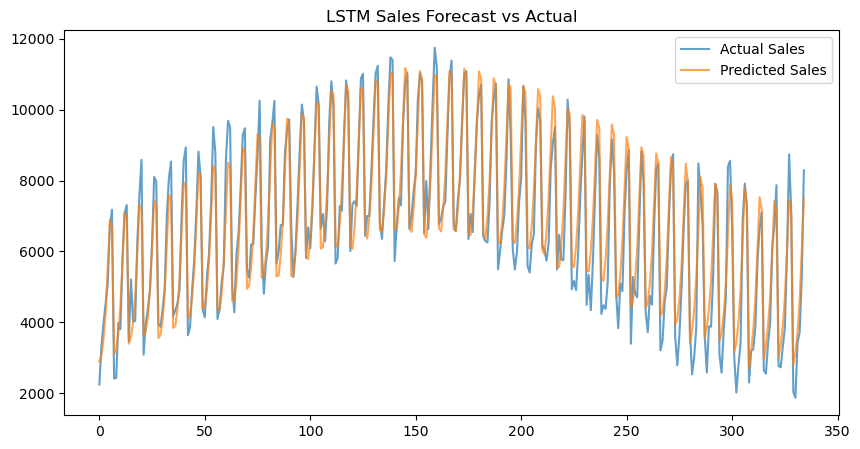

In [196]:
# Plot results
plt.figure(figsize=(10, 5))
plt.plot(y_test_inv, label='Actual Sales', alpha=0.7)
plt.plot(y_pred_inv, label='Predicted Sales', alpha=0.7)
plt.legend()
plt.title("LSTM Sales Forecast vs Actual")
plt.show()

The model's predictions seem to follow the pattern closely, even though the predictions are a bit closer to mean.
It predicts lower sales when the sales are too high, and higher sales when the sales are too low.

## Forecast Model

In [197]:
prep_table_d = final_df.groupby(by=["date"], sort=False).agg({"price": "sum"}).reset_index()
prep_table_d

,date,price
0,2019-01-01,4023.00
1,2019-01-02,3074.69
2,2019-01-03,4062.71
3,2019-01-04,5006.81
4,2019-01-05,4927.53
...,...,...
1091,2021-12-27,1867.71
1092,2021-12-28,3426.50
1093,2021-12-29,3715.39
1094,2021-12-30,5266.27


In [198]:
forecast_table = pd.DataFrame(pd.date_range(start="2021-12-02", end="2022-03-31"), columns=["date"])
forecast_table

,date
0,2021-12-02
1,2021-12-03
2,2021-12-04
3,2021-12-05
4,2021-12-06
...,...
115,2022-03-27
116,2022-03-28
117,2022-03-29
118,2022-03-30


In [199]:
prep_table_d['date'] = pd.to_datetime(prep_table_d['date'], dayfirst=True)
prep_table_d['day'] = prep_table_d['date'].dt.day
prep_table_d['day_of_week'] = prep_table_d['date'].dt.dayofweek
prep_table_d['week'] = prep_table_d['date'].dt.isocalendar().week
prep_table_d['month'] = prep_table_d['date'].dt.month
prep_table_d['quarter'] = prep_table_d['date'].dt.quarter
prep_table_d['year'] = prep_table_d['date'].dt.year
prep_table_d

,date,price,day,day_of_week,week,month,quarter,year
0,2019-01-01,4023.00,1,1,1,1,1,2019
1,2019-01-02,3074.69,2,2,1,1,1,2019
2,2019-01-03,4062.71,3,3,1,1,1,2019
3,2019-01-04,5006.81,4,4,1,1,1,2019
4,2019-01-05,4927.53,5,5,1,1,1,2019
...,...,...,...,...,...,...,...,...
1091,2021-12-27,1867.71,27,0,52,12,4,2021
1092,2021-12-28,3426.50,28,1,52,12,4,2021
1093,2021-12-29,3715.39,29,2,52,12,4,2021
1094,2021-12-30,5266.27,30,3,52,12,4,2021


In [200]:
forecast_table['date'] = pd.to_datetime(forecast_table['date'], dayfirst=True)
forecast_table['day'] = forecast_table['date'].dt.day
forecast_table['day_of_week'] = forecast_table['date'].dt.dayofweek
forecast_table['week'] = forecast_table['date'].dt.isocalendar().week
forecast_table['month'] = forecast_table['date'].dt.month
forecast_table['quarter'] = forecast_table['date'].dt.quarter
forecast_table['year'] = forecast_table['date'].dt.year
forecast_table

,date,day,day_of_week,week,month,quarter,year
0,2021-12-02,2,3,48,12,4,2021
1,2021-12-03,3,4,48,12,4,2021
2,2021-12-04,4,5,48,12,4,2021
3,2021-12-05,5,6,48,12,4,2021
4,2021-12-06,6,0,49,12,4,2021
...,...,...,...,...,...,...,...
115,2022-03-27,27,6,12,3,1,2022
116,2022-03-28,28,0,13,3,1,2022
117,2022-03-29,29,1,13,3,1,2022
118,2022-03-30,30,2,13,3,1,2022


In [201]:
# Define cyclic encoding function
def cyclic_encode(data, col, max_val):
    data[f"{col}_sin"] = np.sin(2 * np.pi * data[col] / max_val)
    data[f"{col}_cos"] = np.cos(2 * np.pi * data[col] / max_val)

In [202]:
# Apply cyclic encoding to preparation table
cyclic_encode(prep_table_d, "day", 31)          # Days in a month
cyclic_encode(prep_table_d, "day_of_week", 7)   # Days in a week
cyclic_encode(prep_table_d, "week", 52)         # Weeks in a year
cyclic_encode(prep_table_d, "month", 12)        # Months in a year

In [203]:
# Apply cyclic encoding to forecasting table
cyclic_encode(forecast_table, "day", 31)          # Days in a month
cyclic_encode(forecast_table, "day_of_week", 7)   # Days in a week
cyclic_encode(forecast_table, "week", 52)         # Weeks in a year
cyclic_encode(forecast_table, "month", 12)        # Months in a year

In [204]:
# Drop original columns (keeping only cyclic versions)
prep_table_d.drop(columns=["day", "day_of_week", "week", "month", ], inplace=True)
prep_table_d

,date,price,quarter,year,day_sin,day_cos,day_of_week_sin,day_of_week_cos,week_sin,week_cos,month_sin,month_cos
0,2019-01-01,4023.00,1,2019,2.012985e-01,0.979530,0.781831,0.623490,0.120537,0.992709,5.000000e-01,0.866025
1,2019-01-02,3074.69,1,2019,3.943559e-01,0.918958,0.974928,-0.222521,0.120537,0.992709,5.000000e-01,0.866025
2,2019-01-03,4062.71,1,2019,5.712682e-01,0.820763,0.433884,-0.900969,0.120537,0.992709,5.000000e-01,0.866025
3,2019-01-04,5006.81,1,2019,7.247928e-01,0.688967,-0.433884,-0.900969,0.120537,0.992709,5.000000e-01,0.866025
4,2019-01-05,4927.53,1,2019,8.486443e-01,0.528964,-0.974928,-0.222521,0.120537,0.992709,5.000000e-01,0.866025
...,...,...,...,...,...,...,...,...,...,...,...,...
1091,2021-12-27,1867.71,4,2021,-7.247928e-01,0.688967,0.000000,1.000000,0.0,1.0,-2.449294e-16,1.000000
1092,2021-12-28,3426.50,4,2021,-5.712682e-01,0.820763,0.781831,0.623490,0.0,1.0,-2.449294e-16,1.000000
1093,2021-12-29,3715.39,4,2021,-3.943559e-01,0.918958,0.974928,-0.222521,0.0,1.0,-2.449294e-16,1.000000
1094,2021-12-30,5266.27,4,2021,-2.012985e-01,0.979530,0.433884,-0.900969,0.0,1.0,-2.449294e-16,1.000000


In [205]:
# Drop original columns (keeping only cyclic versions)
forecast_table.drop(columns=["day", "day_of_week", "week", "month", ], inplace=True)
forecast_table

,date,quarter,year,day_sin,day_cos,day_of_week_sin,day_of_week_cos,week_sin,week_cos,month_sin,month_cos
0,2021-12-02,4,2021,3.943559e-01,0.918958,0.433884,-0.900969,-0.464723,0.885456,-2.449294e-16,1.000000e+00
1,2021-12-03,4,2021,5.712682e-01,0.820763,-0.433884,-0.900969,-0.464723,0.885456,-2.449294e-16,1.000000e+00
2,2021-12-04,4,2021,7.247928e-01,0.688967,-0.974928,-0.222521,-0.464723,0.885456,-2.449294e-16,1.000000e+00
3,2021-12-05,4,2021,8.486443e-01,0.528964,-0.781831,0.623490,-0.464723,0.885456,-2.449294e-16,1.000000e+00
4,2021-12-06,4,2021,9.377521e-01,0.347305,0.000000,1.000000,-0.354605,0.935016,-2.449294e-16,1.000000e+00
...,...,...,...,...,...,...,...,...,...,...,...
115,2022-03-27,1,2022,-7.247928e-01,0.688967,-0.781831,0.623490,0.992709,0.120537,1.000000e+00,6.123234e-17
116,2022-03-28,1,2022,-5.712682e-01,0.820763,0.000000,1.000000,1.0,-0.0,1.000000e+00,6.123234e-17
117,2022-03-29,1,2022,-3.943559e-01,0.918958,0.781831,0.623490,1.0,-0.0,1.000000e+00,6.123234e-17
118,2022-03-30,1,2022,-2.012985e-01,0.979530,0.974928,-0.222521,1.0,-0.0,1.000000e+00,6.123234e-17


In [206]:
scaler_forecast = MinMaxScaler()

In [207]:
# Select features and target
features = [col for col in prep_table_d.columns if col != 'price' and col != 'date']
target = 'price'

In [208]:
forecast_table['price'] = np.zeros(forecast_table.shape[0])

In [209]:
train_scaled = scaler_forecast.fit_transform(prep_table_d[features + [target]])
test_scaled = scaler_forecast.transform(forecast_table[features + [target]])

In [210]:
# Prepare sequences
def create_sequences(data, seq_length):
    X, y = [], []
    for i in range(len(data) - seq_length):
        X.append(data[i:i + seq_length, :-1])  # All features except target
        y.append(data[i + seq_length, -1])  # Target variable
    return np.array(X), np.array(y)

In [211]:
seq_length = 30  # Use the last 30 days to predict the next day

In [212]:
X_train, y_train = create_sequences(train_scaled, seq_length)
X_test, y_test = create_sequences(test_scaled, seq_length)

In [213]:
test_scaled.shape

(120, 11)

In [214]:
model_forecast = 0

In [215]:
# Build LSTM model
model_forecast = Sequential([
    Input(shape=(seq_length, len(features))),  # Define input layer
    LSTM(50, activation='relu', return_sequences=True),
    Dropout(0.2),
    LSTM(50, activation='relu'),
    Dropout(0.2),
    Dense(1)
])

In [216]:
model_forecast.compile(optimizer='adam', loss='mse')

In [217]:
history = model_forecast.fit(X_train, y_train, epochs=50, batch_size=16, verbose=1)

Epoch 1/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - loss: 0.0928 
Epoch 2/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0336 
Epoch 3/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0297 
Epoch 4/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0279 
Epoch 5/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0259 
Epoch 6/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0194 
Epoch 7/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0145 
Epoch 8/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0122 
Epoch 9/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0115 
Epoch 10/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0105 
Epoch 11/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0102 
Epoch 12/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0099 
Epoch 13/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0092 
Epoch 14/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0088 
Epoch 15/50
67/67 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0091 
Epoc

In [218]:
y_pred = model_forecast.predict(X_test)
y_pred_inv = scaler_d.inverse_transform(np.hstack((test_scaled[seq_length:, :-1], y_pred.reshape(-1,1))))[:, -1]

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 142ms/step


In [219]:
y_pred_inv.shape

(90,)

In [220]:
forecast_table = pd.DataFrame(pd.date_range(start="2022-01-01", end="2022-03-31"), columns=["date"])
forecast_table["price"] = y_pred_inv
forecast_table

,date,price
0,2022-01-01,6605.393639
1,2022-01-02,2551.276846
2,2022-01-03,2773.045842
3,2022-01-04,3247.859358
4,2022-01-05,3886.310861
...,...,...
85,2022-03-27,5094.461748
86,2022-03-28,5147.050756
87,2022-03-29,5683.167877
88,2022-03-30,6707.117995


In [221]:
forecast_table['week'] = forecast_table["date"].dt.to_period("W")
forecast_table['year'] = forecast_table['date'].dt.year
forecast_table['year_month'] = forecast_table["date"].dt.to_period("M")

forecast_table

,date,price,week,year,year_month
0,2022-01-01,6605.393639,2021-12-27/2022-01-02,2022,2022-01
1,2022-01-02,2551.276846,2021-12-27/2022-01-02,2022,2022-01
2,2022-01-03,2773.045842,2022-01-03/2022-01-09,2022,2022-01
3,2022-01-04,3247.859358,2022-01-03/2022-01-09,2022,2022-01
4,2022-01-05,3886.310861,2022-01-03/2022-01-09,2022,2022-01
...,...,...,...,...,...
85,2022-03-27,5094.461748,2022-03-21/2022-03-27,2022,2022-03
86,2022-03-28,5147.050756,2022-03-28/2022-04-03,2022,2022-03
87,2022-03-29,5683.167877,2022-03-28/2022-04-03,2022,2022-03
88,2022-03-30,6707.117995,2022-03-28/2022-04-03,2022,2022-03


In [222]:
weekly_avg_frcst = forecast_table.groupby("week", sort=False).agg({"price":"mean"}).reset_index()
weekly_avg_frcst

,week,price
0,2021-12-27/2022-01-02,4578.335242
1,2022-01-03/2022-01-09,4589.860449
2,2022-01-10/2022-01-16,4961.249841
3,2022-01-17/2022-01-23,5166.227040
4,2022-01-24/2022-01-30,5229.426564
5,2022-01-31/2022-02-06,5295.302373
6,2022-02-07/2022-02-13,5518.936683
7,2022-02-14/2022-02-20,5726.586499
8,2022-02-21/2022-02-27,5945.370428
9,2022-02-28/2022-03-06,6196.160916


In [223]:
monthly_avg_frcst = forecast_table.groupby("year_month", sort=False).agg({"price":"mean"}).reset_index()
monthly_avg_frcst

,year_month,price
0,2022-01,4912.876347
1,2022-02,5644.898298
2,2022-03,6703.525524


In [224]:
week_frcst_dict = dict(zip(weekly_avg_frcst['week'], weekly_avg_frcst['price']))
month_frcst_dict = dict(zip(monthly_avg_frcst['year_month'], monthly_avg_frcst['price']))

In [225]:
forecast_table['weekly_avg_sales'] = forecast_table['week'].map(week_frcst_dict)
forecast_table['monthly_avg_sales'] = forecast_table['year_month'].map(month_frcst_dict)
forecast_table

,date,price,week,year,year_month,weekly_avg_sales,monthly_avg_sales
0,2022-01-01,6605.393639,2021-12-27/2022-01-02,2022,2022-01,4578.335242,4912.876347
1,2022-01-02,2551.276846,2021-12-27/2022-01-02,2022,2022-01,4578.335242,4912.876347
2,2022-01-03,2773.045842,2022-01-03/2022-01-09,2022,2022-01,4589.860449,4912.876347
3,2022-01-04,3247.859358,2022-01-03/2022-01-09,2022,2022-01,4589.860449,4912.876347
4,2022-01-05,3886.310861,2022-01-03/2022-01-09,2022,2022-01,4589.860449,4912.876347
...,...,...,...,...,...,...,...
85,2022-03-27,5094.461748,2022-03-21/2022-03-27,2022,2022-03,7066.190875,6703.525524
86,2022-03-28,5147.050756,2022-03-28/2022-04-03,2022,2022-03,6472.457071,6703.525524
87,2022-03-29,5683.167877,2022-03-28/2022-04-03,2022,2022-03,6472.457071,6703.525524
88,2022-03-30,6707.117995,2022-03-28/2022-04-03,2022,2022-03,6472.457071,6703.525524


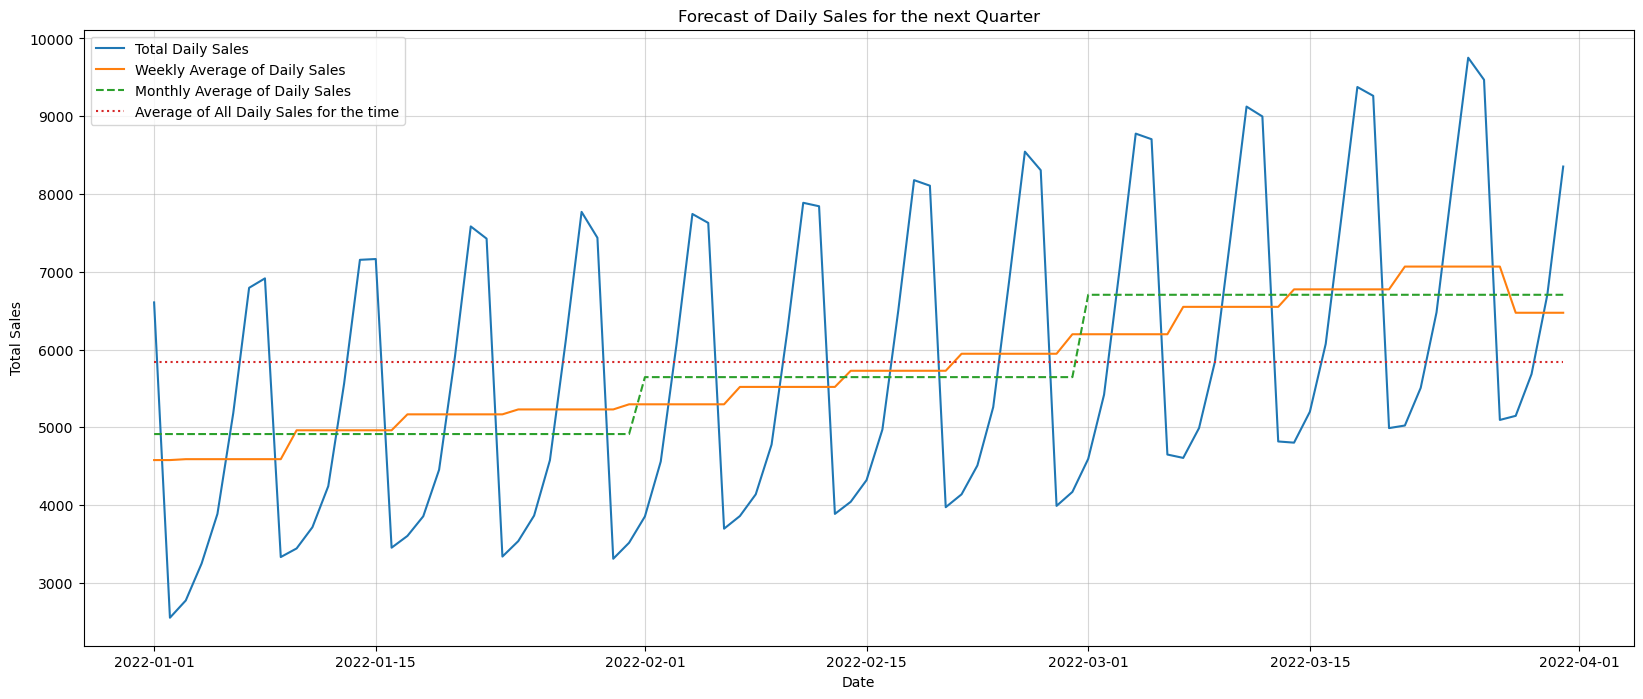

In [226]:
fig, ax = plt.subplots(figsize=(20, 8))
plt.title("Forecast of Daily Sales for the next Quarter")

ax = sns.lineplot(data=forecast_table, x="date", y="price", legend="auto", label="Total Daily Sales")
sns.lineplot(data=forecast_table, x="date", y="weekly_avg_sales", label="Weekly Average of Daily Sales", linestyle="solid")
sns.lineplot(data=forecast_table, x="date", y="monthly_avg_sales", label="Monthly Average of Daily Sales", linestyle="dashed")
sns.lineplot(data=forecast_table, x="date", y=daywise_sales["price"].mean(), label="Average of All Daily Sales for the time", linestyle="dotted")
ax.set(xlabel="Date", ylabel="Total Sales")
plt.grid(alpha=0.5)